##  Spectral lines from ionizing and recombining hydrogen plasma


2024.2.2   k.i.   
2024.2.7   k.i., u.k.   
2024.2.14  k.i., u.k.    include Ne, Nh, Te, Ntot in SE  
2024.3.18  k.i.,    add r1,rc calc.

2024.4.2   t.o.,  calculate dependence on Ne and Te

2024.4.4   t.o.,  calculate the case with #n=34

2024.4.24, 25 t.o., calculate various things (Rate flux to a level n cf. Fujimoto 1979b Fig.3)

In [1]:
import os
os.chdir(r"C:\Users\kutak\ドキュメント\0Materials\Otsu_post-flare-loops\spectra\spectra")

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np

#%matplotlib inline
#%matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%load_ext autoreload
%autoreload 2

from spectra_src.ImportAll import *
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)

C:\Users\kutak\AppData\Local\Temp\ipykernel_17892\875321342.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [3]:
from spectra_src.Struct import Atom, Atmosphere, Radiation
from spectra_src.Atomic import Collision, SEsolver, ContinuumOpacity, BasicP
from spectra_src.Util.HelpUtil import help_
from spectra_src.Visual import Plotting  #, Grotrian
from spectra_src.Atomic import LTELib
from spectra_src.Function.SEquil import SELib
from spectra_src.Atomic import Hydrogen
from spectra_src.Util.AtomUtils.AtomInfo import level_info, extract_lprof, each_prof, line_list
from spectra_src import Constants as Cst
from spectra_src.Function.SlabModel import CloudModel


(1.3806484999999998e-16, 83140000.0)

### Create H-atom

In [87]:
# import os
# from spectra_src.Util.AtomicDataUtils import MakeTheoreticalHydrogenLevels as mh
# mh.make_hydrogen_levels_(34,os.path.join( CFG._ROOT_DIR, "data/atom/H/H34.Level" ))

saved as: C:\Users\kutak\ドキュメント\0Materials\Otsu_post-flare-loops\spectra\spectra\data/atom/H/H34.Level


0

In [4]:
# Atomic model
import os

#conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H6.conf" )  ; H_nam ='H'
conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H_theory.conf" )  ; H_nam ='H'
#conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H34.conf" )  ; H_nam ='H'
atom, wMesh, path_dict = Atom.init_Atom_(conf_path , is_hydrogen=True)

help_(atom)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Atom
|- Z                       int                                  v: 1
|- Mass                    float                                v: 1.008
|- Abun                    float                                v: 1.0
|- nLevel                  int                                  v: 21
|- nLine                   int                                  v: 190
|- nCont                   int                                  v: 20
|- nTran                   int                                  v: 210
|- nRL                     int                                  v: 0
|- Level                   struct array                         s: (21,)
  |-  erg                  float64                              s: (21,)
  |-  g                

### $A_{ul} \sim \frac{32 \pi^{3} a_{0}^{2} e^{2} v^{3}}{3 c^{3} \hbar} \sim \frac{R_{y} \alpha^{3}}{\hbar}  \left(\frac{1}{n_{l}^{2}}- \frac{1}{n_{u}^{2}}\right)^{3},  \qquad \alpha = \frac{e^2}{\hbar c}　:  微細構造定数$

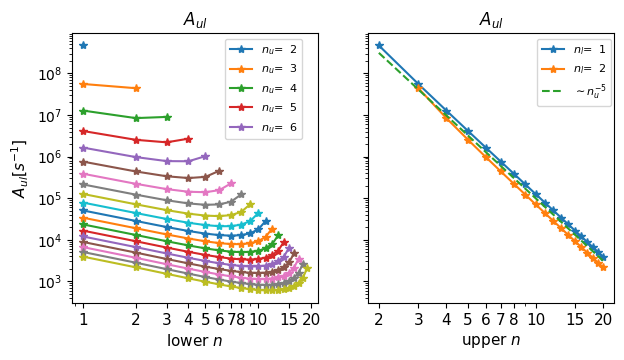

In [5]:
#------- display Aji  -------
Aji = np.array(atom.Line['AJI'])
idxI = np.array(atom.Line['idxI']) # lower level
idxJ = np.array(atom.Line['idxJ']) # upper level
n_lev = np.size(atom.Level)-1
n_line = len(Aji)
nus = np.arange(2,n_lev+1,dtype='int') #  upper n

fig, axs = plt.subplots(1,2, figsize=(7,3.5), dpi=100, sharey=True)

ax=axs[0]  #---  Aji vs. n_l
for n_u in nus:
    ii = np.where((idxI+1 < n_u) & (idxJ+1 == n_u))
    if n_u < 7:
        ax.plot(idxI[ii]+1,Aji[ii],"-*", label="$n_u$={0:3d}".format(n_u))
    else:
        ax.plot(idxI[ii]+1,Aji[ii],"-*")
ax.set_title('$A_{ul}$', fontsize=12)
plt.tick_params(labelsize=11)
ax.set_xscale("log")
ax.set_yscale("log")
ticpos = [1,2,3,4,5,6,7,8,10,15,20]
ticlab = ticpos
ax.set_xticks(ticpos)
ax.set_xticklabels(ticlab, fontsize=11)
ax.set_xlabel("lower $n$", fontsize=11)
ax.set_ylabel("$A_{ul} [s^{-1}]$ ", fontsize=11)
ax.legend(bbox_to_anchor=(0.6,1),fontsize=8,ncol=1)

ax=axs[1]  #---  Aji vs. n_u
for n_l in [1,2]:
    ii = np.where((idxJ+1 > n_l) & (idxI+1 == n_l))
    ax.plot(idxJ[ii]+1,Aji[ii],"-*", label="$n_l$={0:3d}".format(n_l))

ax.plot(nus,1./nus**5 *1e10, '--',label='$\sim n_u^{-5}$')
ax.set_title('$A_{ul}$', fontsize=12)
plt.tick_params(labelsize=11)
ax.set_xscale("log")
ax.set_yscale("log")
ticpos = [2,3,4,5,6,7,8,10,15,20]
ticlab = ticpos
ax.set_xticks(ticpos)
ax.set_xticklabels(ticlab, fontsize=11)
ax.set_xlabel("upper $n$", fontsize=11),
ax.legend(bbox_to_anchor=(1.01,1),fontsize=8,ncol=1)


In [8]:
nl=2
ii = np.where((idxJ+1 > n_l) & (idxI+1 == n_l))

Aji[ii[0][2]]/Aji[ii[0][1]], idxJ[ii[0][2]]

(0.3005839679453176, 4)

### $𝐴_{𝑛_𝑢 𝑛_𝑙}=\frac{𝛼𝑅_𝑦}{𝑚𝑐^2}  \frac{2^6}{3\sqrt3} 
\frac{1}{𝜏_{𝑛_𝑢}n_l(𝑛_u^2 − n_l^2)}  𝑔_{𝑏𝑏}$
#### $𝑅_𝑦=\frac{𝑚𝑒^4}{2ℏ^2}, 𝑎_0=\frac{ℏ^2}{𝑚𝑒^2}, 𝛼≡\frac{𝑒^2}{ℏ𝑐}, 𝜏_𝑛=𝑛^3  \frac{ℎ}{2𝑅_𝑦}$
Fujimoto 2004 より


### Solar spectrum array

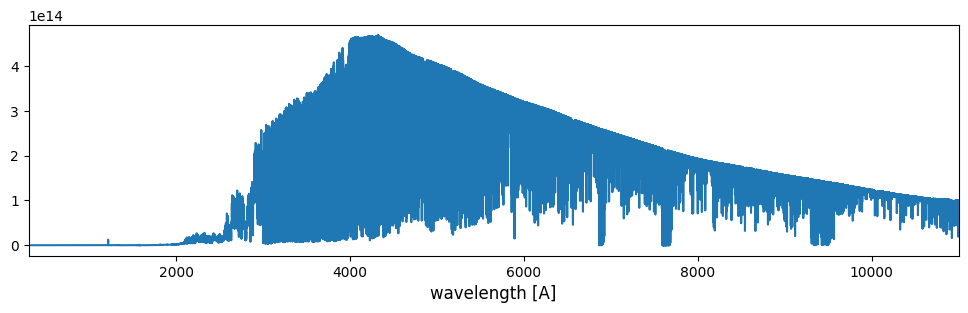

In [6]:
#  prepare solar radiation spectrum
import copy

atmos = Atmosphere.Atmosphere0D(Nh=1.E12, Ne=1.E11, Te=7.E3, Vd=0., Vt=5.E5)
solar_spec  = Radiation.init_Radiation_(atmos, wMesh)
wls = solar_spec.backRad[0,:]*1E8         
wls_air = BasicP.vacuum_to_air_(wls,'AA')   # wavelength in air of background solar spectrum [A]
Isolar = solar_spec.backRad[1,:].copy()   # background solar spectrum intensity    "    [erg/cm^3/s/str]

#  for photo-excitation, mean intensity gets half of the backgroud solar spectrum
solar_spec.backRad[1,:] *= 0.5            # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec.PI_intensity[:,:] *= 0.5       # solar spectrum mean intensity    "    [erg/cm^3/s/str]

fig, ax = plt.subplots(1,1, figsize=(12,3), dpi=100)
ax.plot(wls_air, Isolar)
ax.set_xlim(300, 11000)
#ax.set_xlim(10820, 10840) ; ax.set_ylim(0,1.2e14)
#ax.set_yscale("log") ; ax.set_ylim(1e7,1e15)
ax.set_xlabel("wavelength [A]", fontsize=12)
plt.show()

In [45]:
help_(solar_spec)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Radiation
|- backRad                 ndarray                              s: (2, 3754678)
|- PI_intensity            ndarray                              s: (20, 41)


### Calculate SE for a given [$T_e,n_e$]

In [7]:
Te = 10000.
Ne = 2*1e10
Vd = 0.
Vt = 5e5          #   cm/s
depth = 1E1* 1.E5 #   km *1e5 -> cm  very thin
Jfactor = 1.   # factor for solar radiation

ssp = copy.deepcopy(solar_spec)
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor

slab = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
#help_(slab)
help_(SE)
help_(Rate)
help_(slab)


------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
SE_Container
|- n_SE                    ndarray                              s: (21,)
|- n_LTE                   ndarray                              s: (21,)
|- nj_by_ni                ndarray                              s: (210,)
|- wave_mesh_shifted_1d    ndarray                              s: (7790,)
|- absorb_prof_1d          ndarray                              s: (7790,)
|- Line_mesh_idxs          ndarray                              s: (190, 2)
|- Jbar                    ndarray                              s: (190,)
|- Ntotal                  float64                              v: 29992171224.359097
|- Nh                      float64                              v: 29992171224.359097
|- Ne                      float 

## Atomic process
#### $\frac{dn_i}{dt}= 
\sum\limits_{j>i}A_{ji}n_j + \sum\limits_{j \ne i} B_{ji} J_\lambda n_j + P_{ci} n_c 
+ \sum\limits_{j \ne i} C_{ji}n_e n_j + C_{ci} n_e n_c \\
\quad -\left[ \sum\limits_{j<i}{A_{ij}} 
+ \sum\limits_{j \ne i} B_{ij} J_\lambda + P_{ic} J_\lambda 
+ \sum\limits_{j\ne i}{C_{ij}} n_e +  C_{ic}  n_e \right]n_i \\
= R_{\nu i} n_\nu + C_{\nu i} n_\nu \qquad [\rm{cm^{-3}s^{-1}(flux)}, \quad \nu = 1,2,,,N,c]$
#### $
\begin{bmatrix}
T_{[N,0]} & & & & T_{[N,N]}\\
\vdots & & & & :\\
\vdots & & & & :\\
T_{[1,0]} & T_{[1,1]} & & & :\\
T_{[0,0]} & T_{[0,1]}& & & T_{[0,N]}\\
\end{bmatrix}
=
\begin{bmatrix}
c←1 & \cdots & \rm{電離} & \cdots & 0\\
: & \rm{励起}& & 0 & \vdots \\
: &  &   ／ & & 再結合 \\ 
2←1 & 0 & & \rm{脱励起} & 2←c&\\
0 & 1←2 & & \cdots & 1←c\\
\end{bmatrix}
$ 


In [8]:
# transition heat map
def heatmap(ax, mat,vmin=None, vmax=None, title='', colbar=0, last=''):
    
    nmax = len(mat)-1
    norm = LogNorm(vmin, vmax, clip=True)
    im = ax.imshow( mat, origin="lower", cmap='cool', norm=norm, aspect='equal' )
    if last == 'c':
        ticklab = [i+1 for i in range(nmax)]+['c']
    else:
        ticklab = [i+1 for i in range(nmax+1)]
    ax.set_xticks([i for i in range(nmax+1)])
    ax.set_xticklabels(ticklab, fontsize=10)
    ax.set_yticks([i for i in range(nmax+1)])
    ax.set_yticklabels(ticklab, fontsize=10)
    ax.set_title(title,fontsize=13)

    # colorbar
    if colbar != 0:
        cax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
        fig.colorbar( im, cax=cax, orientation='vertical',label=colbar)
    
    return None


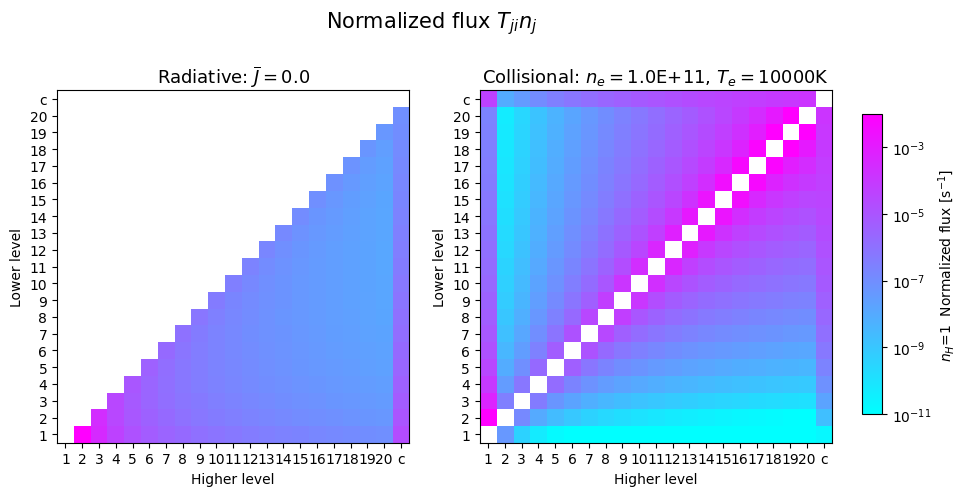

In [9]:
#--- calc. SE & transition flux map ----------------------------------------
Te = 10000.
Ne = 1*1e11
Jfactor = 0.   # intensity of solar radiation

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor

slab = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.

vmin = 1e-11 ;  vmax = 1e-2
fig, axs = plt.subplots(1,2, figsize=(10,5), dpi=100)#, sharey=True)
Rmat = Rate.Rmat*SE.n_SE   # [11,11]*[11]
heatmap(axs[0], Rmat, title='Radiative: '+r"$\overline{J}=$"+f"{Jfactor:3.1F}",
        vmin=vmin, vmax=vmax, last='c')
Cmat = Rate.Cmat*SE.n_SE
heatmap(axs[1], Cmat, title='Collisional: '+r"$n_e=$"+f"{SE.Ne:5.1E}, "+r"$T_e=$"+f"{SE.Te:5.0f}K", 
        colbar='$n_H$=1  Normalized flux [s$^{-1}$]',vmin=vmin, vmax=vmax, last='c')
plt.suptitle("Normalized flux $T_{ji}n_j$", fontsize=15, y=1.01)


axs[0].set_xlabel('Higher level')
axs[0].set_ylabel('Lower level')

axs[1].set_xlabel('Higher level')
axs[1].set_ylabel('Lower level')


plt.show()


In [22]:
#Rmat[l, u] ; u:higher, l:lower
#Rmat[0,1]#u=1 to l=0 i.e., excitation
#Rmat[1,0] #l=0 to u=1 i.e.,de-excitation

Rmat[0,1], Rmat[1,0]

(0.024514656227445145, 0.0)

In [10]:
SE.Ne

100000000000.0

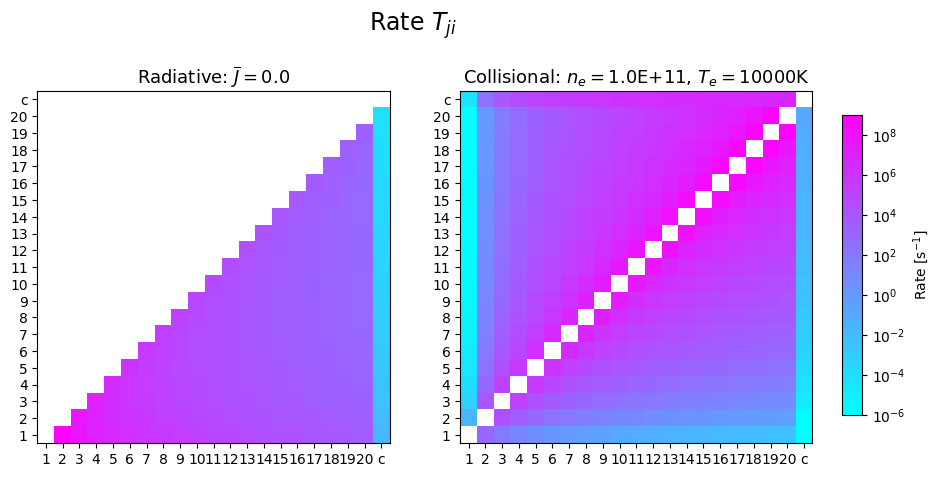

In [10]:
#--- transition rate map ----------------------------------------
vmin = 1e-6 ;  vmax = 1e9

fig, axs = plt.subplots(1,2, figsize=(10,5), dpi=100)#, sharey=True)
title='Radiative: '+r"$\overline{J}=$"+f"{Jfactor:3.1F}"
heatmap(axs[0], Rate.Rmat, title=title,vmin=vmin,vmax=vmax, last='c')
title='Collisional: '+r"$n_e=$"+f"{SE.Ne:5.1E}, "+r"$T_e=$"+f"{SE.Te:5.0f}K"
heatmap(axs[1], Rate.Cmat, title=title,vmin=vmin,vmax=vmax, colbar='Rate [s$^{-1}$]', last='c')
plt.suptitle("Rate $T_{ji}$", fontsize=17, y=1.01)


plt.show()


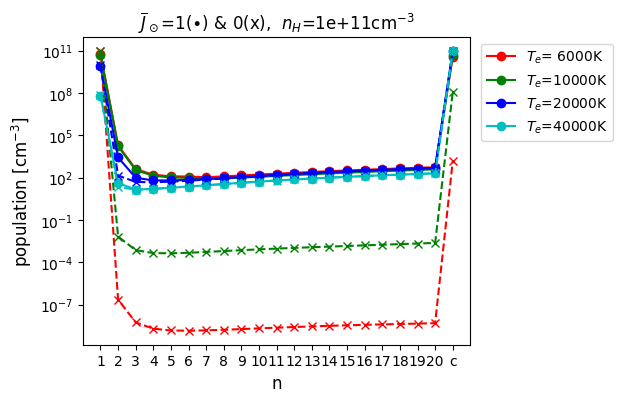

In [11]:
#----- level polulation in Statistical Eq. -----
Nh = 1.E11
Ne = 0.
Jfactor = 1.   # intensity of solar radiation
Tes = [6000, 10000, 20000, 40000]

n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor
tau = np.zeros(n_lev+1)
colors = ["r", "g", "b", "c", "m", "y", "k", "w"]
fig, ax = plt.subplots(1,1, figsize=(5,4), dpi=100)

j=0
for Te in Tes:
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Nh_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
    ax.plot(n,SE.n_SE*SE.Nh,'-o',label="$T_e$={0:5.0f}K".format(SE.Te), color=colors[j])
    j += 1

Jfactor = 0.
ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor
j=0
for Te in Tes:
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Nh_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
    ax.plot(n,SE.n_SE*SE.Nh,'--x'.format(SE.Te), color=colors[j])
    j += 1

ax.set_yscale("log")
ax.set_xticks(n)
ax.set_xticklabels([i for i in n[:-1]]+['c'], fontsize=10)
ax.set_xlabel('n', fontsize=12)
ax.set_ylabel('population [cm$^{-3}$]', fontsize=12)
title = r"$\overline{J}_\odot$=1($\bullet$) & 0(x)"+",  $n_H$={0:5.0e}cm$^{{-3}}$".format(SE.Nh)
plt.title(title,fontsize=12)
ax.legend(bbox_to_anchor=(1.01,1),fontsize=10,ncol=1)

plt.show()

#### Dominant population         $\qquad n_1 + n_p >> \sum\limits_{2\le i\le n_{max}}n_i$

Transitions from $n=1$ and c control the population in excitation levels between them.

### relaxation time
$\frac{dn_i}{dt}=A_i - B_i n_i \quad \rightarrow \quad A_i = B_i n_i^0 \quad$
in statistical eq.
 
$n_i = n_i^0+\Delta n_i \quad 
\rightarrow \frac{dn_i}{dt}=\frac{d\Delta n_i}{dt} = A_i - B_i n_i = -B\Delta n_i
\quad \rightarrow \quad \Delta n_i \propto \exp(-B_i t)$

relaxation time, $\tau_i = 1/B_i = 1/\sum(R[:,i]+C[:,i])$




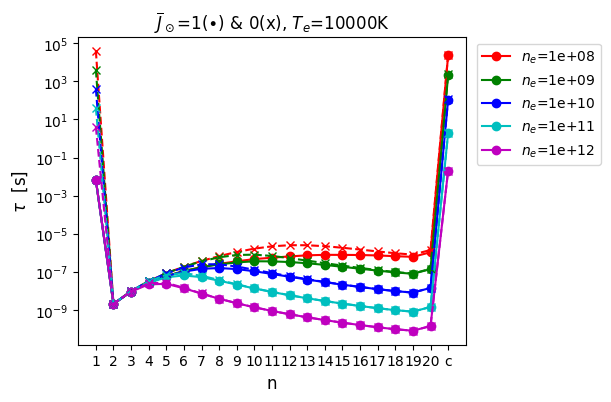

In [12]:
#--- relaxation time vs. n & Ne ----------------------------------------
Te = 10000.
Jfactor = 1.   # intensity of solar radiation
Nes = [1E8, 1E9, 1E10, 1E11, 1E12]

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor
ssp.PI_intensity[:,:] *= Jfactor
tau = np.zeros(n_lev+1)
colors = ["r", "g", "b", "c", "m", "y", "k", "w"]
fig, ax = plt.subplots(1,1, figsize=(5,4), dpi=100)

j=0
for Ne in Nes:
    slab = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
    for i in range(n_lev+1):
        tau[i] = 1./(Rate.Rmat[:,i].sum()+Rate.Cmat[:,i].sum())
    ax.plot(n,tau,'-o',label="$n_e$={0:3.0e}".format(Ne), color=colors[j])
    j += 1

Jfactor = 0.
ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor
ssp.PI_intensity[:,:] *= Jfactor
j=0
for Ne in Nes:
    slab = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
    for i in range(n_lev+1):
        tau[i] = 1./(Rate.Rmat[:,i].sum()+Rate.Cmat[:,i].sum())
    ax.plot(n,tau,'--x',color=colors[j])
    j += 1

ax.set_yscale("log")
ax.set_xticks(n)
ax.set_xticklabels([i for i in n[:-1]]+['c'], fontsize=10)
ax.set_xlabel('n', fontsize=12)
ax.set_ylabel(r"$\tau$  [s]", fontsize=12)
title = r"$\overline{J}_\odot$=1($\bullet$) & 0(x)"+", $T_e$={0:5.0f}K".format(Te)
plt.title(title,fontsize=12)
ax.legend(bbox_to_anchor=(1.01,1),fontsize=10,ncol=1)

plt.show()

### $\tau_1, \tau_c >> \tau_{2\sim N},$ 
=> level population for $n = 2 \sim N$ can be calculated under fixed $n_1$ and $n_p$

at $n_e=10^{10-11}cm^{-3}, \tau_c$ is in order of 10$\sim$100sec regardless of $J_\odot$

### Statistical equiliblium for level $1\sim N$ and $c$ (ion)

#### $
\frac{d}{dt}
\begin{bmatrix}
n_1\\
n_2\\
\vdots \\
n_N\\
n_c \\
\end{bmatrix}
=
\begin{bmatrix}
0\\
0\\
\vdots \\
0\\
0 \\
\end{bmatrix}
=
\begin{bmatrix}
T_{11} & T_{12}& \dots & T_{2c} & T_{1c}\\
T_{21} & T_{22} & & T_{2N} & T_{2c} \\
\vdots & & \ddots & & \vdots \\
T_{N1} & T_{N2} & & T_{NN} & T_{Nc}\\
T_{c1} & T_{c2} & \dots & T_{cN} & T_{cc}\\
\end{bmatrix}
\cdot
\begin{bmatrix}
n_1\\
n_2\\
\vdots \\
n_N\\
n_c \\
\end{bmatrix}
\qquad \rm{with} \sum n_i = 1
$
$
T_{i \ne j}= \left( A_{ji} + B_{ji} J_\lambda + C_{ji}n_e \right) \\
T_{ii} = - \sum\limits_{j \ne i}\left( A_{ij} + B_{ij} J_\lambda + C_{ij} n_e \right) 
$

### Solving SE with fixed $n_1 \& n_c$ 

#### $
\frac{d}{dt}
\begin{bmatrix}
n_2\\
\vdots \\
n_N\\
\end{bmatrix}
=
\begin{bmatrix}
0\\
\vdots \\
0\\
\end{bmatrix}
=
n_1\begin{bmatrix}
T_{21}\\
\vdots \\
T_{N1}\\
\end{bmatrix}
+
n_c
\begin{bmatrix}
T_{2c}\\
\vdots \\
T_{Nc}\\
\end{bmatrix}
+
\begin{bmatrix}
T_{22} & & T_{2N}\\
 & \ddots &  \\
T_{N2} & & T_{NN}\\
\end{bmatrix}
\cdot
\begin{bmatrix}
n_2\\
\vdots \\
n_N\\
\end{bmatrix}
$ 
すなわち、

$
- n_1\begin{bmatrix}
T_{21}\\
\vdots \\
T_{N1}\\
\end{bmatrix}
-
n_c
\begin{bmatrix}
T_{2c}\\
\vdots \\
T_{Nc}\\
\end{bmatrix}
\equiv
\begin{bmatrix}
V_{2}\\
\vdots \\
V_{N}\\
\end{bmatrix}
=
\begin{bmatrix}
T_{22} & & T_{2N}\\
 & \ddots &  \\
T_{N2} & & T_{NN}\\
\end{bmatrix}
\cdot
\begin{bmatrix}
n_2\\
\vdots \\
n_N\\
\end{bmatrix}
\qquad $ 
を逆行列で解く。



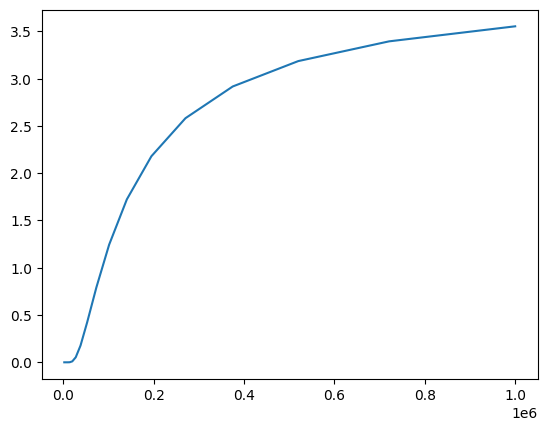

# Density Dependence without solar radiation

# Def. of Slab (J=0.0)

In [131]:
#Fixed parameters
Nh= 1.E11 #arbitary if we use normalized pop.
#Te = 10000.
#Ne = 1.E10
Vd = 0.
Vt = 5e5 #cm/s 
Jfactor = 1.0#1.   # intensity of solar radiation
#Nes = [1E8, 1E9, 1E10, 1E11, 1E12]


ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  

#slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 

# The case of SE 

In [132]:
N_ne= 18
N_te= 20
N_level = 21
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

Ne_list = 10**(np.linspace(8, 25, N_ne)) # density list
Te_list = 10**(np.linspace(np.log10(2e3), 6, N_te)) # temperature list
SE_pops_te_ne = np.zeros([N_te, N_ne, N_level]) # SE pop. list
Rmat_te_ne = np.zeros([N_te, N_ne, N_level,N_level]) # SE pop. list
Cmat_te_ne = np.zeros([N_te, N_ne, N_level, N_level]) # SE pop. list

for i in range(N_te):
    for j in range(N_ne):
        slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne_list[j], Te=Te_list[i], Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
        SE0, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None) 
    
        SE_pops_te_ne[i,j,:]=SE0.n_SE.copy()
        Rmat_te_ne[i,j,:,:]=Rate.Rmat*SE0.n_SE
        Cmat_te_ne[i,j,:,:]=Rate.Cmat*SE0.n_SE
        print(i, j)

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
4 10
4 11
4 12
4 13
4 14
4 15
4 16
4 17
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11
5 12
5 13
5 14
5 15
5 16
5 17
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
6 9
6 10
6 11
6 12
6 13
6 14
6 15
6 16
6 17
7 0
7 1
7 2
7 3
7 4
7 5
7 6
7 7
7 8
7 9
7 10
7 11
7 12
7 13
7 14
7 15
7 16
7 17
8 0
8 1
8 2
8 3
8 4
8 5
8 6
8 7
8 8
8 9
8 10
8 11
8 12
8 13
8 14
8 15
8 16
8 17
9 0
9 1
9 2
9 3
9 4
9 5
9 6
9 7
9 8
9 9
9 10
9 11
9 12
9 13
9 14
9 15
9 16
9 17
10 0
10 1
10 2
10 3
10 4
10 5
10 6
10 7
10 8
10 9
10 10
10 11
10 12
10 13
10 14
10 15
10 16
10 17
11 0
11 1
11 2
11 3
11 4
11 5
11 6
11 7
11 8
11 9
11 10
11 11
11 12
11 13
11 14
11 15
11 16
11 17
12 0

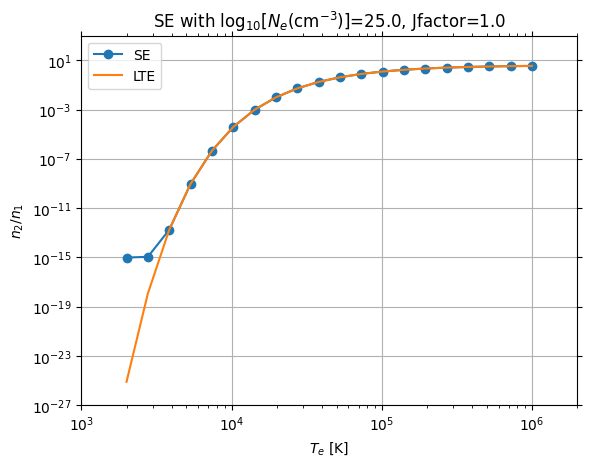

In [108]:

# def plot_SE_LTE(i, path=''):
#     plt.cla()
#     plt.close
#     plt.plot(Te_list, SE_pops_te_ne[:,i,1]/SE_pops_te_ne[:,i,0], '-o', label='SE')
    
#     plt.plot(Te_list, n2_n1, '-', label='LTE')
    
#     plt.legend()
    
#     plt.xscale('log')
#     plt.yscale('log')
    
#     plt.xlim(1e3, 2e6)
#     plt.ylim(1e-27, 1e3)
    
#     plt.xlabel(r'$T_e$ [K]')
#     plt.ylabel(r'$n_2/n_1$')
    
#     plt.title('SE with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    
#     plt.grid()
    
    
    
#     plt.savefig(path+'/result_{:0=3}.png'.format(i))

# path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/SE_comp_LTE/Jfactor_1"

# for i in range(N_ne):
#     plot_SE_LTE(i, path=path)

# Pop. to n=1

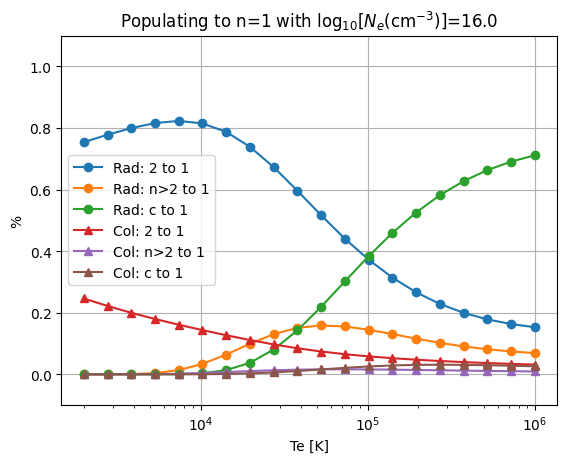

In [132]:
# def plot_rate(i):
#     plt.cla()
#     plt.close()
    
#     total=np.sum(Rmat_te_ne[:,i,0,:], axis=1) + np.sum(Cmat_te_ne[:,i,0,:], axis=1)
#     plt.plot(Te_list, Rmat_te_ne[:,i,0,1]/total, '-o',label='Rad: 2 to 1')
#     plt.plot(Te_list, np.sum(Rmat_te_ne[:,i,0,2:-1], axis=1)/total, '-o',label='Rad: n>2 to 1')
#     plt.plot(Te_list, Rmat_te_ne[:,i,0,-1]/total, '-o',label='Rad: c to 1')

#     plt.plot(Te_list, Cmat_te_ne[:,i,0,1]/total, '-^',label='Col: 2 to 1')
#     plt.plot(Te_list, np.sum(Cmat_te_ne[:,i,0,2:-1], axis=1)/total, '-^',label='Col: n>2 to 1')
#     plt.plot(Te_list, Cmat_te_ne[:,i,0,-1]/total,'-^', label='Col: c to 1')
    
    


#     plt.legend()
#     plt.xlabel('Te [K]')
#     plt.ylabel('%')

#     plt.xscale('log')
#     plt.ylim(-0.1, 1.1)

#     plt.title('Populating to n=1 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i])))
#     plt.grid()

# i=8
# plot_rate(i)
    

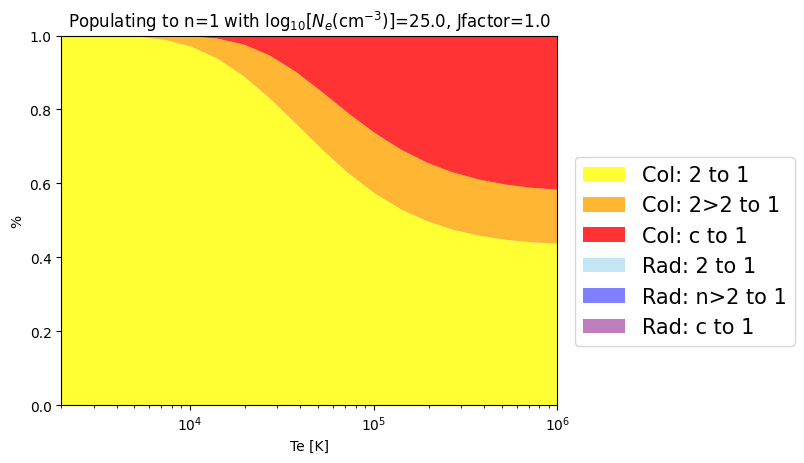

In [173]:
# def plot_rate(i, path=''):
#     plt.cla()
#     plt.close()
    
#     total=np.sum(Rmat_te_ne[:,i,0,:], axis=1) + np.sum(Cmat_te_ne[:,i,0,:], axis=1)
#     R21=Rmat_te_ne[:,i,0,1]/total
#     Rh1=np.sum(Rmat_te_ne[:,i,0,2:-1], axis=1)/total
#     Rc1=Rmat_te_ne[:,i,0,-1]/total

#     C21=Cmat_te_ne[:,i,0,1]/total
#     Ch1=np.sum(Cmat_te_ne[:,i,0,2:-1], axis=1)/total
#     Cc1=Cmat_te_ne[:,i,0,-1]/total

#     y0=0.0
#     y1=C21
#     y2=y1+Ch1
#     y3=y2+Cc1
#     z1=y3+R21
#     z2=z1+Rh1
#     z3=z2+Rc1
#     c='black'
#     ls='-'
#     # lw=0.5
#     # plt.plot(Te_list, y1, c=c, ls=ls, lw=lw)

#     alpha=0.8
#     plt.fill_between(Te_list, y0, y1, facecolor='yellow', alpha=alpha, label='Col: 2 to 1')
#     plt.fill_between(Te_list, y1, y2, facecolor='orange', alpha=alpha, label='Col: 2>2 to 1')
#     plt.fill_between(Te_list, y2, y3, facecolor='red', alpha=alpha, label='Col: c to 1')

#     alpha=0.5
#     plt.fill_between(Te_list, y3, z1, facecolor='skyblue', alpha=alpha, label='Rad: 2 to 1')
#     plt.fill_between(Te_list, z1, z2, facecolor='blue', alpha=alpha, label='Rad: n>2 to 1')
#     plt.fill_between(Te_list, z2, z3, facecolor='purple', alpha=alpha, label='Rad: c to 1')
    

   
#     plt.xlabel('Te [K]')
#     plt.ylabel('%')

#     plt.xscale('log')
#     plt.ylim(-0.0, 1.0)
#     plt.xlim(Te_list[0], Te_list[-1])

#     plt.title('Populating to n=1 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
#     plt.legend(bbox_to_anchor=(1.5,0.7),fontsize=15,ncol=1)
#     plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

#     #plt.grid()

# path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/SE_comp_LTE/Rate_to_n1_J0"

# for i in range(N_ne):
#     plot_rate(i, path=path)
    

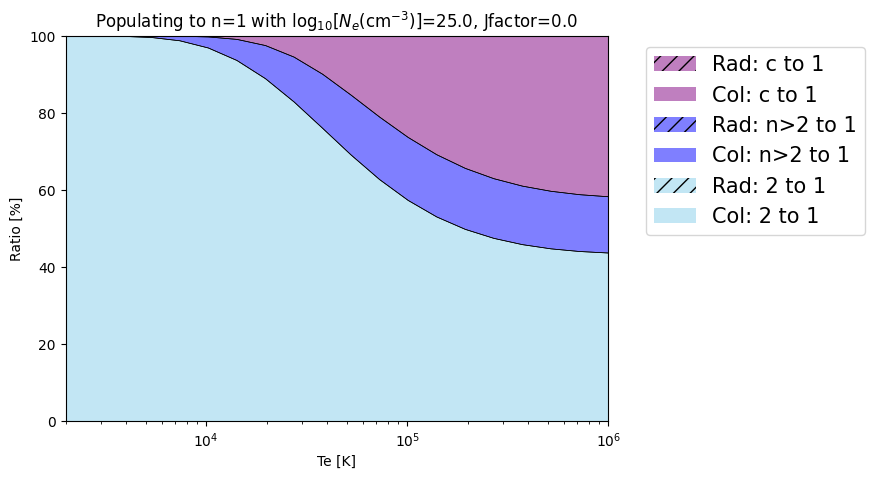

In [112]:
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/SE_comp_LTE/n1/Rate_to_n1_J0_ver2"

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    
    total=(np.sum(Rmat_te_ne[:,i,0,:], axis=1) + np.sum(Cmat_te_ne[:,i,0,:], axis=1))*1e-2
    
    R21=Rmat_te_ne[:,i,0,1]/total
    Rh1=np.sum(Rmat_te_ne[:,i,0,2:-1], axis=1)/total
    Rc1=Rmat_te_ne[:,i,0,-1]/total

    C21=Cmat_te_ne[:,i,0,1]/total
    Ch1=np.sum(Cmat_te_ne[:,i,0,2:-1], axis=1)/total
    Cc1=Cmat_te_ne[:,i,0,-1]/total

    y0=0.0
    y1=C21.copy()
    y2=y1+R21
    y3=y2+Ch1
    z1=y3+Rh1
    z2=z1+Cc1
    z3=z2+Rc1
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z3, c=c, ls=ls, lw=lw)
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='skyblue', alpha=alpha, label='Col: 2 to 1')
    ax.fill_between(Te_list, y1, y2, facecolor='skyblue', alpha=alpha, label='Rad: 2 to 1', hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='blue', alpha=alpha, label='Col: n>2 to 1')

    alpha=0.5
    ax.fill_between(Te_list, y3, z1, facecolor='blue', alpha=alpha, label='Rad: n>2 to 1', hatch='//')
    ax.fill_between(Te_list, z1, z2, facecolor='purple', alpha=alpha, label='Col: c to 1')
    ax.fill_between(Te_list, z2, z3, facecolor='purple', alpha=alpha, label='Rad: c to 1', hatch='//')
    

   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating to n=1 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(10)

# Depo. from n=1

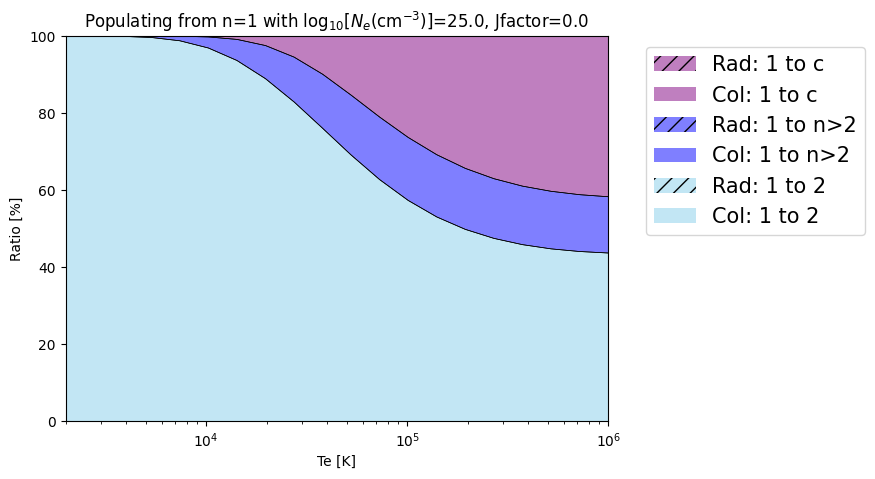

In [113]:
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/SE_comp_LTE/n1/Rate_from_n1_J0"

def plot_rate(n, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    
    total=(np.sum(Rmat_te_ne[:,n,:,0], axis=1) + np.sum(Cmat_te_ne[:,n,:,0], axis=1))*1e-2
    R12=Rmat_te_ne[:,n,1,0]/total
    R1h=np.sum(Rmat_te_ne[:,n,2:-1,0], axis=1)/total
    R1c=Rmat_te_ne[:,n,-1,0]/total

    C12=Cmat_te_ne[:,n,1,0]/total
    C1h=np.sum(Cmat_te_ne[:,n,2:-1,0], axis=1)/total
    C1c=Cmat_te_ne[:,n,-1,0]/total

    y0=0.0
    y1=C12.copy()
    y2=y1+R12
    y3=y2+C1h
    z1=y3+R1h
    z2=z1+C1c
    z3=z2+R1c
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z3, c=c, ls=ls, lw=lw)
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='skyblue', alpha=alpha, label='Col: 1 to 2')
    ax.fill_between(Te_list, y1, y2, facecolor='skyblue', alpha=alpha, label='Rad: 1 to 2', hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='blue', alpha=alpha, label='Col: 1 to n>2')

    alpha=0.5
    ax.fill_between(Te_list, y3, z1, facecolor='blue', alpha=alpha, label='Rad: 1 to n>2', hatch='//')
    ax.fill_between(Te_list, z1, z2, facecolor='purple', alpha=alpha, label='Col: 1 to c')
    ax.fill_between(Te_list, z2, z3, facecolor='purple', alpha=alpha, label='Rad: 1 to c', hatch='//')
    

   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating from n=1 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[n]))+', Jfactor={}'.format(Jfactor))
    
    
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])
    
    plt.savefig(path+'/result_{:0=3}.png'.format(n), bbox_inches='tight')
    #plt.show()

    #plt.grid()

for n in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(n, path=path)
    
   

#plot_rate(5, path=path)

# Pop. to n=2

99.99999999999999
99.99999999999999
99.99999999999999
100.00000000000001
100.0
99.99999999999999
100.0
100.0
100.0
100.00000000000001
99.99999999999999
100.00000000000001
100.0
99.99999999999997
99.99999999999999
100.00000000000001
100.00000000000001
99.99999999999999


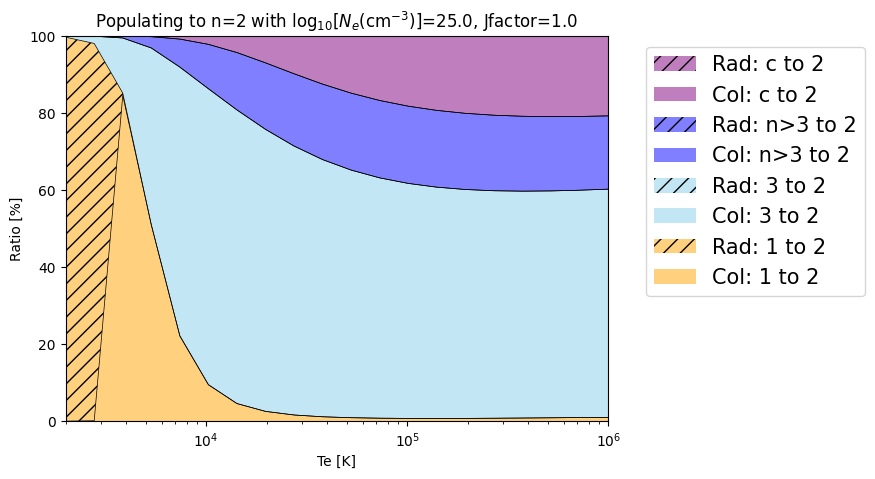

In [133]:
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/SE_comp_LTE/n2/Rate_to_n2_J1"
n=2-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    
    total=(np.sum(Rmat_te_ne[:,i,n,:], axis=1) + np.sum(Cmat_te_ne[:,i,n,:], axis=1))*1e-2
    
    R12=Rmat_te_ne[:,i,n,n-1]/total
    R32=Rmat_te_ne[:,i,n,n+1]/total
    Rh2=np.sum(Rmat_te_ne[:,i,n,n+2:-1], axis=1)/total
    Rc2=Rmat_te_ne[:,i,n,-1]/total

    C12=Cmat_te_ne[:,i,n,n-1]/total
    C32=Cmat_te_ne[:,i,n,n+1]/total
    Ch2=np.sum(Cmat_te_ne[:,i,n,n+2:-1], axis=1)/total
    Cc2=Cmat_te_ne[:,i,n,-1]/total
    
    y0=0.0
    y1=C12.copy()
    y2=y1+R12
    y3=y2+C32
    y4=y3+R32
    y5=y4+Ch2
    y6=y5+Rh2
    y7=y6+Cc2
    y8=y7+Rc2
    print(y8[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='orange', alpha=alpha, label='Col: 1 to 2')
    ax.fill_between(Te_list, y1, y2, facecolor='orange', alpha=alpha, label='Rad: 1 to 2', hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='skyblue', alpha=alpha, label='Col: 3 to 2')
    ax.fill_between(Te_list, y3, y4, facecolor='skyblue', alpha=alpha, label='Rad: 3 to 2', hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='blue', alpha=alpha, label='Col: n>3 to 2')
    ax.fill_between(Te_list, y5, y6, facecolor='blue', alpha=alpha, label='Rad: n>3 to 2', hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='purple', alpha=alpha, label='Col: c to 2')
    ax.fill_between(Te_list, y7, y8, facecolor='purple', alpha=alpha, label='Rad: c to 2', hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating to n=2 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

# Depop. from n=2

99.99999999999999
99.99999999999999
100.00000000000001
99.99999999999999
100.0
99.99999999999997
100.00000000000003
100.00000000000001
100.0
100.0
99.99999999999997
99.99999999999997
99.99999999999999
100.00000000000001
100.0
100.0
100.00000000000003
100.0


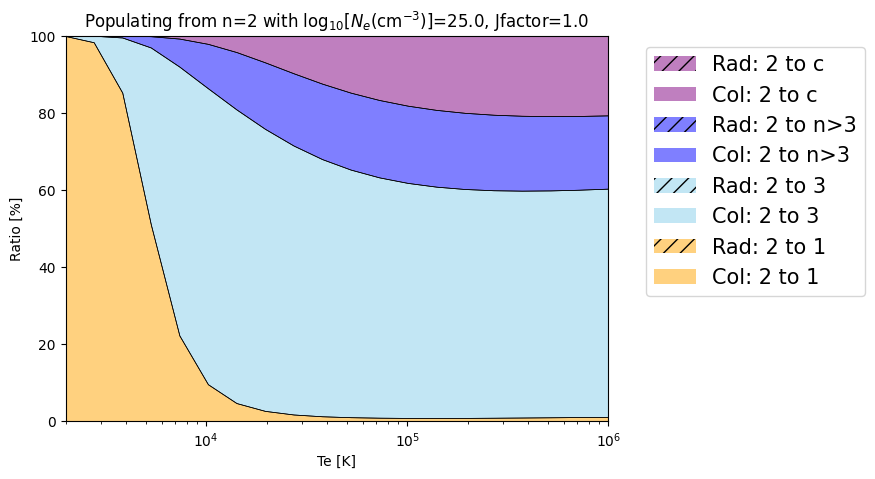

In [134]:
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/SE_comp_LTE/n2/Rate_from_n2_J1"
n=2-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    
    total=(np.sum(Rmat_te_ne[:,i,:,n], axis=1) + np.sum(Cmat_te_ne[:,i,:,n], axis=1))*1e-2
    
    R21=Rmat_te_ne[:,i,n-1,n]/total
    R23=Rmat_te_ne[:,i,n+1,n]/total
    R2h=np.sum(Rmat_te_ne[:,i,n+2:-1,n], axis=1)/total
    R2c=Rmat_te_ne[:,i,-1,n]/total

    C21=Cmat_te_ne[:,i,n-1,n]/total
    C23=Cmat_te_ne[:,i,n+1,n]/total
    C2h=np.sum(Cmat_te_ne[:,i,n+2:-1,n], axis=1)/total
    C2c=Cmat_te_ne[:,i,-1,n]/total
    
    y0=0.0
    y1=C21.copy()
    y2=y1+R21
    y3=y2+C23
    y4=y3+R23
    y5=y4+C2h
    y6=y5+R2h
    y7=y6+C2c
    y8=y7+R2c
    print(y8[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='orange', alpha=alpha, label='Col: 2 to 1')
    ax.fill_between(Te_list, y1, y2, facecolor='orange', alpha=alpha, label='Rad: 2 to 1', hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='skyblue', alpha=alpha, label='Col: 2 to 3')
    ax.fill_between(Te_list, y3, y4, facecolor='skyblue', alpha=alpha, label='Rad: 2 to 3', hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='blue', alpha=alpha, label='Col: 2 to n>3')
    ax.fill_between(Te_list, y5, y6, facecolor='blue', alpha=alpha, label='Rad: 2 to n>3', hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='purple', alpha=alpha, label='Col: 2 to c')
    ax.fill_between(Te_list, y7, y8, facecolor='purple', alpha=alpha, label='Rad: 2 to c', hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating from n=2 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

# Pop. to n>2

100.00000000000001
100.00000000000001
99.99999999999999
100.00000000000003
99.99999999999999
100.0
100.00000000000003
100.0
100.0
100.0
99.99999999999999
100.0
100.00000000000001
99.99999999999996
100.00000000000001
99.99999999999997
99.99999999999999
99.99999999999999


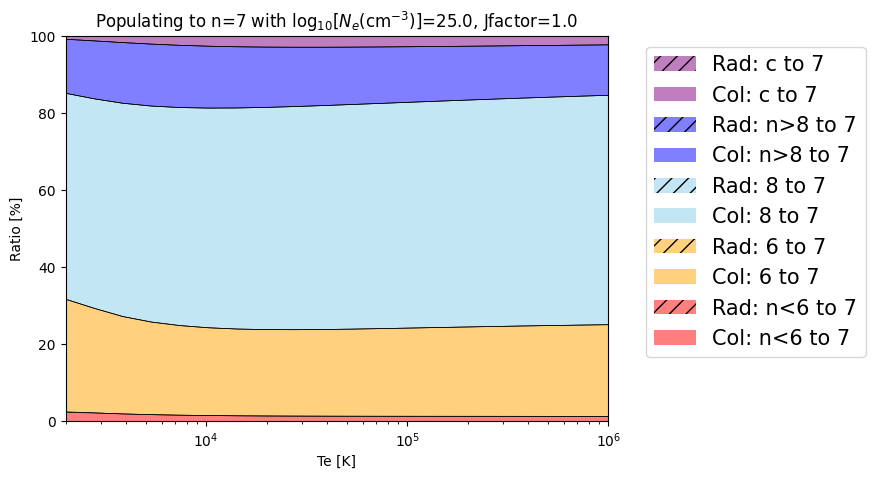

In [143]:
nn_level=7
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/SE_comp_LTE/"+"n{0}/Rate_to_n{0}_J1".format(nn_level)
n=nn_level-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    
    total=(np.sum(Rmat_te_ne[:,i,n,:], axis=1) + np.sum(Cmat_te_ne[:,i,n,:], axis=1))*1e-2

    Rln=np.sum(Rmat_te_ne[:,i,n,0:n-1], axis=1)/total
    Rnm1n=Rmat_te_ne[:,i,n,n-1]/total
    Rnp1n=Rmat_te_ne[:,i,n,n+1]/total
    Rhn=np.sum(Rmat_te_ne[:,i,n,n+2:-1], axis=1)/total
    Rcn=Rmat_te_ne[:,i,n,-1]/total

    Cln=np.sum(Cmat_te_ne[:,i,n,0:n-1], axis=1)/total
    Cnm1n=Cmat_te_ne[:,i,n,n-1]/total
    Cnp1n=Cmat_te_ne[:,i,n,n+1]/total
    Chn=np.sum(Cmat_te_ne[:,i,n,n+2:-1], axis=1)/total
    Ccn=Cmat_te_ne[:,i,n,-1]/total

    y0=0.0
    y1=Cln.copy()
    y2=y1+Rln
    y3=y2+Cnm1n
    y4=y3+Rnm1n
    y5=y4+Cnp1n
    y6=y5+Rnp1n
    y7=y6+Chn
    y8=y7+Rhn
    y9=y8+Ccn
    y10=y9+Rcn
    
    print(y10[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y9, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y10, c=c, ls=ls, lw=lw)
    
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='red', alpha=alpha, label='Col: n<{0} to {1}'.format(n,n+1))
    ax.fill_between(Te_list, y1, y2, facecolor='red', alpha=alpha, label='Rad: n<{0} to {1}'.format(n,n+1), hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='orange', alpha=alpha, label='Col: {0} to {1}'.format(n, n+1))
    ax.fill_between(Te_list, y3, y4, facecolor='orange', alpha=alpha, label='Rad: {0} to {1}'.format(n, n+1), hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='skyblue', alpha=alpha, label='Col: {0} to {1}'.format(n+2, n+1))
    ax.fill_between(Te_list, y5, y6, facecolor='skyblue', alpha=alpha, label='Rad: {0} to {1}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='blue', alpha=alpha, label='Col: n>{0} to {1}'.format(n+2, n+1))
    ax.fill_between(Te_list, y7, y8, facecolor='blue', alpha=alpha, label='Rad: n>{0} to {1}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y8, y9, facecolor='purple', alpha=alpha, label='Col: c to {}'.format(n+1))
    ax.fill_between(Te_list, y9, y10, facecolor='purple', alpha=alpha, label='Rad: c to {}'.format(n+1), hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating to '+'n={} '.format(n+1) +'with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

# Depop. from n>2

99.99999999999997
99.99999999999999
99.99999999999997
99.99999999999999
100.0
100.00000000000003
100.0
99.99999999999997
99.99999999999999
99.99999999999999
99.99999999999997
100.00000000000001
100.0
100.00000000000001
99.99999999999999
100.00000000000001
99.99999999999999
100.0


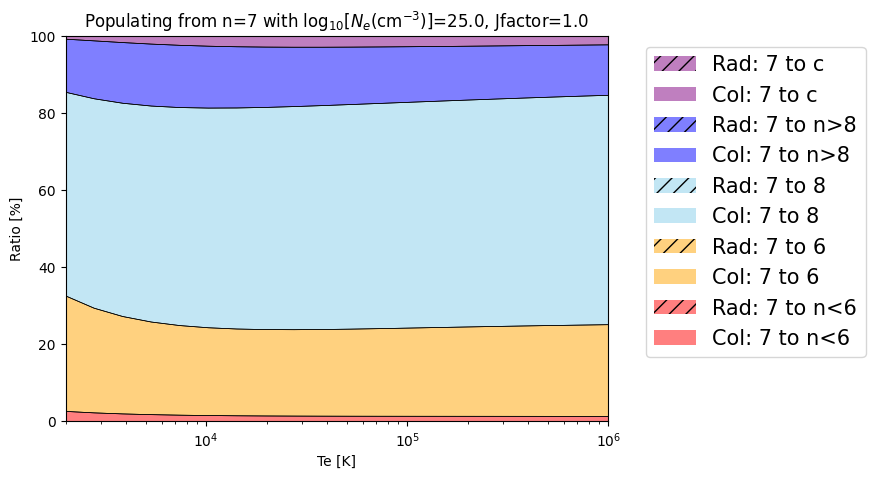

In [144]:
nn_level=7
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/SE_comp_LTE/"+"n{0}/Rate_from_n{0}_J1".format(nn_level)
n=nn_level-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    
    total=(np.sum(Rmat_te_ne[:,i,:,n], axis=1) + np.sum(Cmat_te_ne[:,i,:,n], axis=1))*1e-2

    Rln=np.sum(Rmat_te_ne[:,i,0:n-1,n], axis=1)/total
    Rnm1n=Rmat_te_ne[:,i,n-1,n]/total
    Rnp1n=Rmat_te_ne[:,i,n+1,n]/total
    Rhn=np.sum(Rmat_te_ne[:,i,n+2:-1,n], axis=1)/total
    Rcn=Rmat_te_ne[:,i,-1,n]/total

    Cln=np.sum(Cmat_te_ne[:,i,0:n-1,n], axis=1)/total
    Cnm1n=Cmat_te_ne[:,i,n-1,n]/total
    Cnp1n=Cmat_te_ne[:,i,n+1,n]/total
    Chn=np.sum(Cmat_te_ne[:,i,n+2:-1,n], axis=1)/total
    Ccn=Cmat_te_ne[:,i,-1,n]/total

    y0=0.0
    y1=Cln.copy()
    y2=y1+Rln
    y3=y2+Cnm1n
    y4=y3+Rnm1n
    y5=y4+Cnp1n
    y6=y5+Rnp1n
    y7=y6+Chn
    y8=y7+Rhn
    y9=y8+Ccn
    y10=y9+Rcn
    
    print(y10[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y9, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y10, c=c, ls=ls, lw=lw)
    
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='red', alpha=alpha, label='Col: {1} to n<{0}'.format(n,n+1))
    ax.fill_between(Te_list, y1, y2, facecolor='red', alpha=alpha, label='Rad: {1} to n<{0}'.format(n,n+1), hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='orange', alpha=alpha, label='Col: {1} to {0}'.format(n, n+1))
    ax.fill_between(Te_list, y3, y4, facecolor='orange', alpha=alpha, label='Rad: {1} to {0}'.format(n, n+1), hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='skyblue', alpha=alpha, label='Col: {1} to {0}'.format(n+2, n+1))
    ax.fill_between(Te_list, y5, y6, facecolor='skyblue', alpha=alpha, label='Rad: {1} to {0}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='blue', alpha=alpha, label='Col: {1} to n>{0}'.format(n+2, n+1))
    ax.fill_between(Te_list, y7, y8, facecolor='blue', alpha=alpha, label='Rad: {1} to n>{0}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y8, y9, facecolor='purple', alpha=alpha, label='Col: {} to c'.format(n+1))
    ax.fill_between(Te_list, y9, y10, facecolor='purple', alpha=alpha, label='Rad: {} to c'.format(n+1), hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating from '+'n={} '.format(n+1) +'with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

# Ionizing case

In [9]:
def calc_NIE(atom, slab, wMesh, solar_spec, n1, n_proton):
    ## use rate_only=True to acquire the transition matrix (R matrix and C matrix) without solving linear equation
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, solar_spec, None, rate_only=True)  #  level populations etc.
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rate.Rmat, Rate.Cmat)
    # print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    # print(f"Amat has shape: {A.shape}")
    b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    ## solve Ax=b
    nArr = np.linalg.solve(A, b) ## population density for levels n=2,3,...,N
    #print(f"nArr shape: {nArr.shape}")
    pop = np.zeros(len(nArr)+2)
    pop[0] = n1 ; pop[1:-1] = nArr ; pop[-1] = n_proton
    Nh = pop.sum()
    SE.n_SE = pop/Nh
    SE.Nh = Nh
    SE.Te = slab.Te
    SE.Ne = slab.Ne

    return(SE,Rate)

In [160]:
#Fixed parameters
Nh= 1.E11 #arbitary if we use normalized pop.
Te = 1e4#10000.
#Ne = 1.E10#1.E10
Vd = 0.
Vt = 5e5 #cm/s 
Jfactor = 1.0#1.   # intensity of solar radiation
#Nes = [1E8, 1E9, 1E10, 1E11, 1E12]
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  

#slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
N_ne= 18
N_te= 20
N_level = 21
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

Ne_list = 10**(np.linspace(8, 25, N_ne)) # density list
Te_list = 10**(np.linspace(np.log10(2e3), 6, N_te)) # temperature list
Io_pops_te_ne = np.zeros([N_te, N_ne, N_level]) # SE pop. list
n1 = 1.E10  ; n_proton = 0.E0  # cm-3,  ionizing plasma
RmatIo_te_ne = np.zeros([N_te, N_ne, N_level,N_level]) # SE pop. list
CmatIo_te_ne = np.zeros([N_te, N_ne, N_level, N_level]) # SE pop. list

for i in range(N_te):
    for j in range(N_ne):
        slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne_list[j], Te=Te_list[i], Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
        SE0, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton) 
    
        Io_pops_te_ne[i,j,:]=SE0.n_SE.copy()
        RmatIo_te_ne[i,j,:,:]=Rate.Rmat*SE0.n_SE
        CmatIo_te_ne[i,j,:,:]=Rate.Cmat*SE0.n_SE
        print(i, j)



# N_ne= 9
# N_level = 21
# n_lev = np.size(atom.Level)-1
# n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

# Ne_list = 10**(np.linspace(8, 12, N_ne)) # temperature list
# Io_pops_dens = np.zeros([N_ne, N_level]) # SE pop. list

# n1 = 1.E10  ; n_proton = 0.E0  # cm-3,  ionizing plasma
# #SE1, Rate1 = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)

# for i in range(N_ne):
#     slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne_list[i], Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
#     SE0, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton) 

#     Io_pops_dens[i, :]=SE0.n_SE.copy()

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
4 10
4 11
4 12
4 13
4 14
4 15
4 16
4 17
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11
5 12
5 13
5 14
5 15
5 16
5 17
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
6 9
6 10
6 11
6 12
6 13
6 14
6 15
6 16
6 17
7 0
7 1
7 2
7 3
7 4
7 5
7 6
7 7
7 8
7 9
7 10
7 11
7 12
7 13
7 14
7 15
7 16
7 17
8 0
8 1
8 2
8 3
8 4
8 5
8 6
8 7
8 8
8 9
8 10
8 11
8 12
8 13
8 14
8 15
8 16
8 17
9 0
9 1
9 2
9 3
9 4
9 5
9 6
9 7
9 8
9 9
9 10
9 11
9 12
9 13
9 14
9 15
9 16
9 17
10 0
10 1
10 2
10 3
10 4
10 5
10 6
10 7
10 8
10 9
10 10
10 11
10 12
10 13
10 14
10 15
10 16
10 17
11 0
11 1
11 2
11 3
11 4
11 5
11 6
11 7
11 8
11 9
11 10
11 11
11 12
11 13
11 14
11 15
11 16
11 17
12 0

# Pop. to n=1

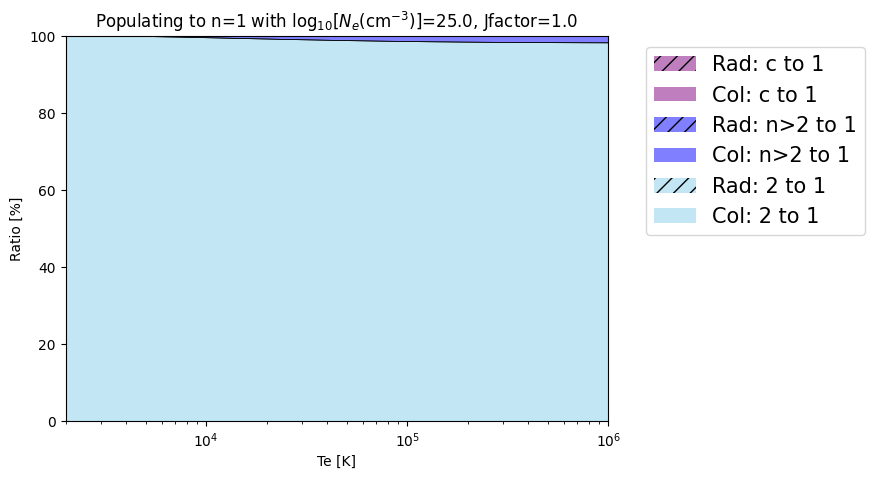

In [161]:
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Io/n1/Rate_to_n1_J1"

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    
    total=(np.sum(RmatIo_te_ne[:,i,0,:], axis=1) + np.sum(CmatIo_te_ne[:,i,0,:], axis=1))*1e-2
    
    R21=RmatIo_te_ne[:,i,0,1]/total
    Rh1=np.sum(RmatIo_te_ne[:,i,0,2:-1], axis=1)/total
    Rc1=RmatIo_te_ne[:,i,0,-1]/total

    C21=CmatIo_te_ne[:,i,0,1]/total
    Ch1=np.sum(CmatIo_te_ne[:,i,0,2:-1], axis=1)/total
    Cc1=CmatIo_te_ne[:,i,0,-1]/total

    y0=0.0
    y1=C21.copy()
    y2=y1+R21
    y3=y2+Ch1
    z1=y3+Rh1
    z2=z1+Cc1
    z3=z2+Rc1
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z3, c=c, ls=ls, lw=lw)
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='skyblue', alpha=alpha, label='Col: 2 to 1')
    ax.fill_between(Te_list, y1, y2, facecolor='skyblue', alpha=alpha, label='Rad: 2 to 1', hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='blue', alpha=alpha, label='Col: n>2 to 1')

    alpha=0.5
    ax.fill_between(Te_list, y3, z1, facecolor='blue', alpha=alpha, label='Rad: n>2 to 1', hatch='//')
    ax.fill_between(Te_list, z1, z2, facecolor='purple', alpha=alpha, label='Col: c to 1')
    ax.fill_between(Te_list, z2, z3, facecolor='purple', alpha=alpha, label='Rad: c to 1', hatch='//')
    

   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating to n=1 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(10)

# Depop. from n=1

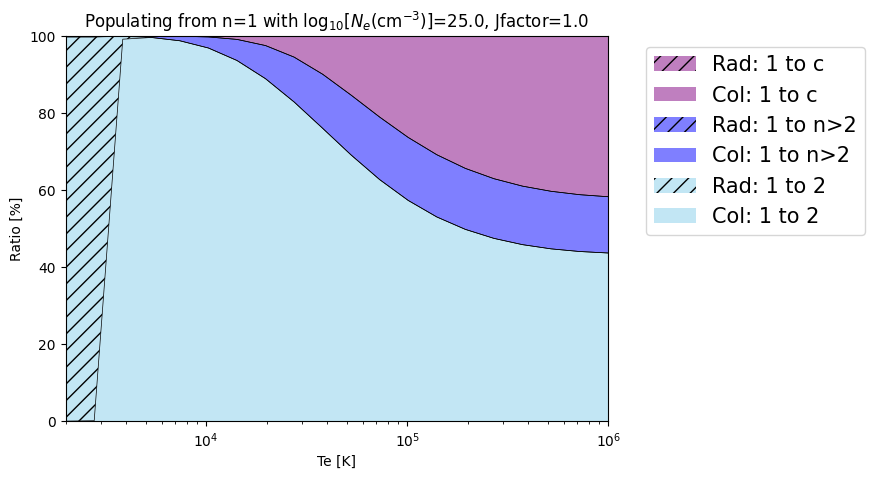

In [162]:
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Io/n1/Rate_from_n1_J1"

def plot_rate(n, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    
    total=(np.sum(RmatIo_te_ne[:,n,:,0], axis=1) + np.sum(CmatIo_te_ne[:,n,:,0], axis=1))*1e-2
    R12=RmatIo_te_ne[:,n,1,0]/total
    R1h=np.sum(RmatIo_te_ne[:,n,2:-1,0], axis=1)/total
    R1c=RmatIo_te_ne[:,n,-1,0]/total

    C12=CmatIo_te_ne[:,n,1,0]/total
    C1h=np.sum(CmatIo_te_ne[:,n,2:-1,0], axis=1)/total
    C1c=CmatIo_te_ne[:,n,-1,0]/total

    y0=0.0
    y1=C12.copy()
    y2=y1+R12
    y3=y2+C1h
    z1=y3+R1h
    z2=z1+C1c
    z3=z2+R1c
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z3, c=c, ls=ls, lw=lw)
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='skyblue', alpha=alpha, label='Col: 1 to 2')
    ax.fill_between(Te_list, y1, y2, facecolor='skyblue', alpha=alpha, label='Rad: 1 to 2', hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='blue', alpha=alpha, label='Col: 1 to n>2')

    alpha=0.5
    ax.fill_between(Te_list, y3, z1, facecolor='blue', alpha=alpha, label='Rad: 1 to n>2', hatch='//')
    ax.fill_between(Te_list, z1, z2, facecolor='purple', alpha=alpha, label='Col: 1 to c')
    ax.fill_between(Te_list, z2, z3, facecolor='purple', alpha=alpha, label='Rad: 1 to c', hatch='//')
    

   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating from n=1 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[n]))+', Jfactor={}'.format(Jfactor))
    
    
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])
    
    plt.savefig(path+'/result_{:0=3}.png'.format(n), bbox_inches='tight')
    #plt.show()

    #plt.grid()

for n in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(n, path=path)
    
   

#plot_rate(5, path=path)

# Pop. to n=2

99.99999999999997
100.0
99.99999999999999
100.00000000000001
100.00000000000001
99.99999999999999
100.0
99.99999999999999
100.00000000000001
100.00000000000001
100.00000000000001
100.00000000000001
100.00000000000001
99.99999999999999
100.00000000000003
100.00000000000001
100.00000000000001
99.99999999999997


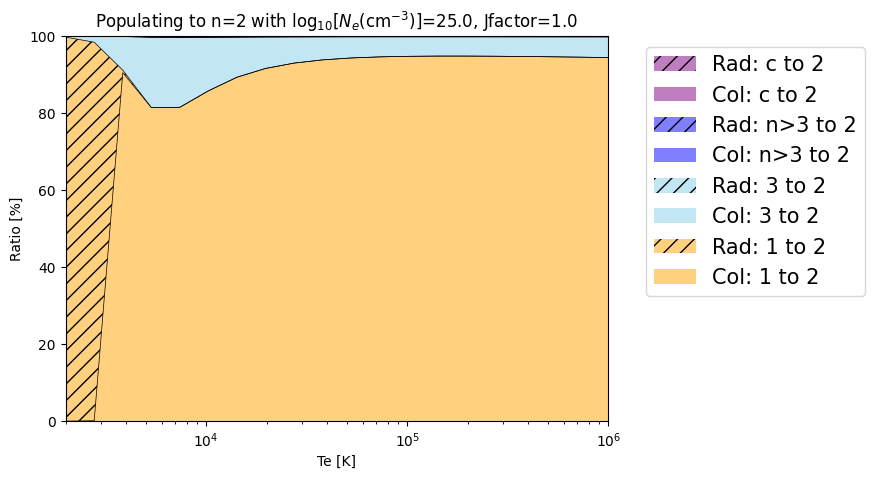

In [163]:
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Io/n2/Rate_to_n2_J1"
n=2-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    
    total=(np.sum(RmatIo_te_ne[:,i,n,:], axis=1) + np.sum(CmatIo_te_ne[:,i,n,:], axis=1))*1e-2
    
    R12=RmatIo_te_ne[:,i,n,n-1]/total
    R32=RmatIo_te_ne[:,i,n,n+1]/total
    Rh2=np.sum(RmatIo_te_ne[:,i,n,n+2:-1], axis=1)/total
    Rc2=RmatIo_te_ne[:,i,n,-1]/total

    C12=CmatIo_te_ne[:,i,n,n-1]/total
    C32=CmatIo_te_ne[:,i,n,n+1]/total
    Ch2=np.sum(CmatIo_te_ne[:,i,n,n+2:-1], axis=1)/total
    Cc2=CmatIo_te_ne[:,i,n,-1]/total
    
    y0=0.0
    y1=C12.copy()
    y2=y1+R12
    y3=y2+C32
    y4=y3+R32
    y5=y4+Ch2
    y6=y5+Rh2
    y7=y6+Cc2
    y8=y7+Rc2
    print(y8[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='orange', alpha=alpha, label='Col: 1 to 2')
    ax.fill_between(Te_list, y1, y2, facecolor='orange', alpha=alpha, label='Rad: 1 to 2', hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='skyblue', alpha=alpha, label='Col: 3 to 2')
    ax.fill_between(Te_list, y3, y4, facecolor='skyblue', alpha=alpha, label='Rad: 3 to 2', hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='blue', alpha=alpha, label='Col: n>3 to 2')
    ax.fill_between(Te_list, y5, y6, facecolor='blue', alpha=alpha, label='Rad: n>3 to 2', hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='purple', alpha=alpha, label='Col: c to 2')
    ax.fill_between(Te_list, y7, y8, facecolor='purple', alpha=alpha, label='Rad: c to 2', hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating to n=2 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

# Depop. from n=2

100.00000000000001
100.00000000000001
100.00000000000001
100.0
100.0
100.00000000000001
100.0
100.00000000000001
100.00000000000003
100.0
99.99999999999999
100.00000000000001
99.99999999999999
100.00000000000001
100.00000000000001
100.0
99.99999999999999
100.00000000000001


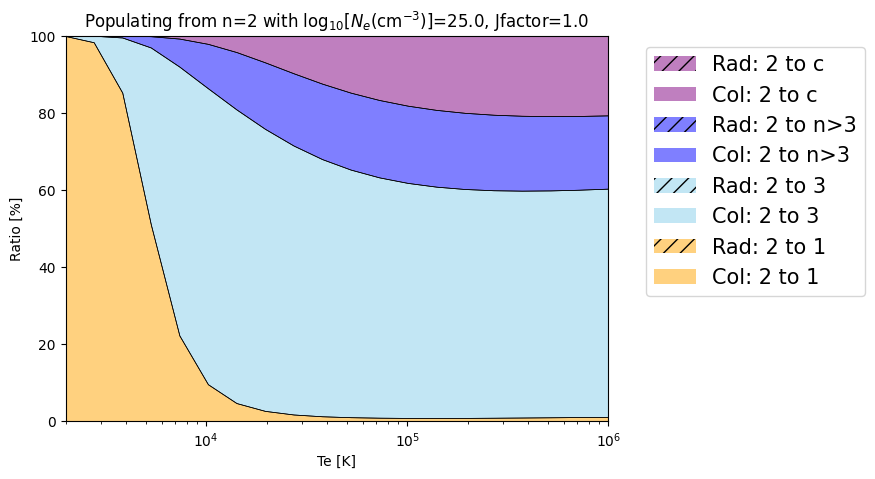

In [164]:
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Io/n2/Rate_from_n2_J1"
n=2-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    
    total=(np.sum(RmatIo_te_ne[:,i,:,n], axis=1) + np.sum(CmatIo_te_ne[:,i,:,n], axis=1))*1e-2
    
    R21=RmatIo_te_ne[:,i,n-1,n]/total
    R23=RmatIo_te_ne[:,i,n+1,n]/total
    R2h=np.sum(RmatIo_te_ne[:,i,n+2:-1,n], axis=1)/total
    R2c=RmatIo_te_ne[:,i,-1,n]/total

    C21=CmatIo_te_ne[:,i,n-1,n]/total
    C23=CmatIo_te_ne[:,i,n+1,n]/total
    C2h=np.sum(CmatIo_te_ne[:,i,n+2:-1,n], axis=1)/total
    C2c=CmatIo_te_ne[:,i,-1,n]/total
    
    y0=0.0
    y1=C21.copy()
    y2=y1+R21
    y3=y2+C23
    y4=y3+R23
    y5=y4+C2h
    y6=y5+R2h
    y7=y6+C2c
    y8=y7+R2c
    print(y8[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='orange', alpha=alpha, label='Col: 2 to 1')
    ax.fill_between(Te_list, y1, y2, facecolor='orange', alpha=alpha, label='Rad: 2 to 1', hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='skyblue', alpha=alpha, label='Col: 2 to 3')
    ax.fill_between(Te_list, y3, y4, facecolor='skyblue', alpha=alpha, label='Rad: 2 to 3', hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='blue', alpha=alpha, label='Col: 2 to n>3')
    ax.fill_between(Te_list, y5, y6, facecolor='blue', alpha=alpha, label='Rad: 2 to n>3', hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='purple', alpha=alpha, label='Col: 2 to c')
    ax.fill_between(Te_list, y7, y8, facecolor='purple', alpha=alpha, label='Rad: 2 to c', hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating from n=2 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

# Pop. to n>2

99.99999999999999
100.0
100.0
100.0
99.99999999999997
100.0
99.99999999999997
99.99999999999999
100.00000000000001
99.99999999999999
100.00000000000001
100.0
100.0
100.0
100.0
99.99999999999999
99.99999999999997
100.00000000000001


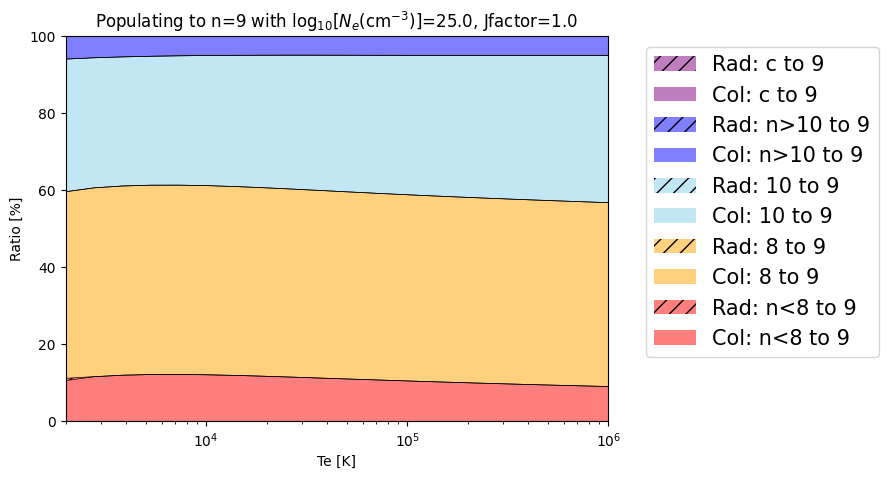

In [175]:
nn_level=9
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Io/"+"n{0}/Rate_to_n{0}_J1".format(nn_level)
n=nn_level-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    Rmat_dam=RmatIo_te_ne.copy()
    Cmat_dam=CmatIo_te_ne.copy()
    
    total=(np.sum(Rmat_dam[:,i,n,:], axis=1) + np.sum(Cmat_dam[:,i,n,:], axis=1))*1e-2

    Rln=np.sum(Rmat_dam[:,i,n,0:n-1], axis=1)/total
    Rnm1n=Rmat_dam[:,i,n,n-1]/total
    Rnp1n=Rmat_dam[:,i,n,n+1]/total
    Rhn=np.sum(Rmat_dam[:,i,n,n+2:-1], axis=1)/total
    Rcn=Rmat_dam[:,i,n,-1]/total

    Cln=np.sum(Cmat_dam[:,i,n,0:n-1], axis=1)/total
    Cnm1n=Cmat_dam[:,i,n,n-1]/total
    Cnp1n=Cmat_dam[:,i,n,n+1]/total
    Chn=np.sum(Cmat_dam[:,i,n,n+2:-1], axis=1)/total
    Ccn=Cmat_dam[:,i,n,-1]/total

    y0=0.0
    y1=Cln.copy()
    y2=y1+Rln
    y3=y2+Cnm1n
    y4=y3+Rnm1n
    y5=y4+Cnp1n
    y6=y5+Rnp1n
    y7=y6+Chn
    y8=y7+Rhn
    y9=y8+Ccn
    y10=y9+Rcn
    
    print(y10[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y9, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y10, c=c, ls=ls, lw=lw)
    
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='red', alpha=alpha, label='Col: n<{0} to {1}'.format(n,n+1))
    ax.fill_between(Te_list, y1, y2, facecolor='red', alpha=alpha, label='Rad: n<{0} to {1}'.format(n,n+1), hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='orange', alpha=alpha, label='Col: {0} to {1}'.format(n, n+1))
    ax.fill_between(Te_list, y3, y4, facecolor='orange', alpha=alpha, label='Rad: {0} to {1}'.format(n, n+1), hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='skyblue', alpha=alpha, label='Col: {0} to {1}'.format(n+2, n+1))
    ax.fill_between(Te_list, y5, y6, facecolor='skyblue', alpha=alpha, label='Rad: {0} to {1}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='blue', alpha=alpha, label='Col: n>{0} to {1}'.format(n+2, n+1))
    ax.fill_between(Te_list, y7, y8, facecolor='blue', alpha=alpha, label='Rad: n>{0} to {1}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y8, y9, facecolor='purple', alpha=alpha, label='Col: c to {}'.format(n+1))
    ax.fill_between(Te_list, y9, y10, facecolor='purple', alpha=alpha, label='Rad: c to {}'.format(n+1), hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating to '+'n={} '.format(n+1) +'with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

# Depop. from n>2

99.99999999999997
99.99999999999999
100.0
100.0
99.99999999999999
99.99999999999997
100.00000000000001
100.0
100.00000000000001
100.00000000000003
99.99999999999999
99.99999999999997
100.0
99.99999999999999
100.00000000000001
100.00000000000001
100.0
100.00000000000003


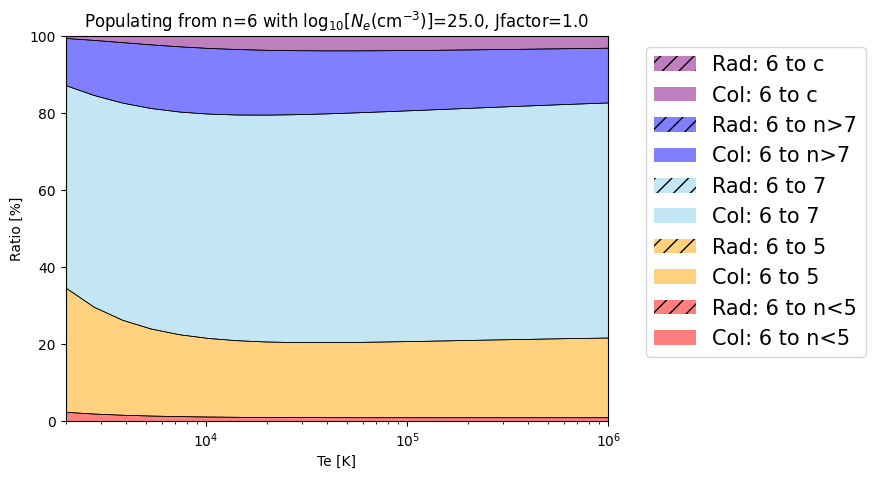

In [172]:
nn_level=6
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Io/"+"n{0}/Rate_from_n{0}_J1".format(nn_level)
n=nn_level-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    Rmat_dam=RmatIo_te_ne.copy()
    Cmat_dam=CmatIo_te_ne.copy()
    
    
    total=(np.sum(Rmat_dam[:,i,:,n], axis=1) + np.sum(Cmat_dam[:,i,:,n], axis=1))*1e-2

    Rln=np.sum(Rmat_dam[:,i,0:n-1,n], axis=1)/total
    Rnm1n=Rmat_dam[:,i,n-1,n]/total
    Rnp1n=Rmat_dam[:,i,n+1,n]/total
    Rhn=np.sum(Rmat_dam[:,i,n+2:-1,n], axis=1)/total
    Rcn=Rmat_dam[:,i,-1,n]/total

    Cln=np.sum(Cmat_dam[:,i,0:n-1,n], axis=1)/total
    Cnm1n=Cmat_dam[:,i,n-1,n]/total
    Cnp1n=Cmat_dam[:,i,n+1,n]/total
    Chn=np.sum(Cmat_dam[:,i,n+2:-1,n], axis=1)/total
    Ccn=Cmat_dam[:,i,-1,n]/total

    y0=0.0
    y1=Cln.copy()
    y2=y1+Rln
    y3=y2+Cnm1n
    y4=y3+Rnm1n
    y5=y4+Cnp1n
    y6=y5+Rnp1n
    y7=y6+Chn
    y8=y7+Rhn
    y9=y8+Ccn
    y10=y9+Rcn
    
    print(y10[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y9, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y10, c=c, ls=ls, lw=lw)
    
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='red', alpha=alpha, label='Col: {1} to n<{0}'.format(n,n+1))
    ax.fill_between(Te_list, y1, y2, facecolor='red', alpha=alpha, label='Rad: {1} to n<{0}'.format(n,n+1), hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='orange', alpha=alpha, label='Col: {1} to {0}'.format(n, n+1))
    ax.fill_between(Te_list, y3, y4, facecolor='orange', alpha=alpha, label='Rad: {1} to {0}'.format(n, n+1), hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='skyblue', alpha=alpha, label='Col: {1} to {0}'.format(n+2, n+1))
    ax.fill_between(Te_list, y5, y6, facecolor='skyblue', alpha=alpha, label='Rad: {1} to {0}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='blue', alpha=alpha, label='Col: {1} to n>{0}'.format(n+2, n+1))
    ax.fill_between(Te_list, y7, y8, facecolor='blue', alpha=alpha, label='Rad: {1} to n>{0}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y8, y9, facecolor='purple', alpha=alpha, label='Col: {} to c'.format(n+1))
    ax.fill_between(Te_list, y9, y10, facecolor='purple', alpha=alpha, label='Rad: {} to c'.format(n+1), hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating from '+'n={} '.format(n+1) +'with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

# Recombining

In [20]:
#Fixed parameters
Nh= 1.E11 #arbitary if we use normalized pop.
Te = 1e4#10000.
#Ne = 1.E10#1.E10
Vd = 0.
Vt = 5e5 #cm/s 
Jfactor = 0.0#1.   # intensity of solar radiation
#Nes = [1E8, 1E9, 1E10, 1E11, 1E12]
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  

#slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
N_ne= 18
N_te= 20
N_level = 21
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

Ne_list = 10**(np.linspace(8, 25, N_ne)) # density list
Te_list = 10**(np.linspace(np.log10(2e3), 6, N_te)) # temperature list
Re_pops_te_ne = np.zeros([N_te, N_ne, N_level]) # SE pop. list
n1 = 0.E0  ; n_proton = 1.E10  # cm-3,  recombining plasma
RmatRe_te_ne = np.zeros([N_te, N_ne, N_level,N_level]) # SE pop. list
CmatRe_te_ne = np.zeros([N_te, N_ne, N_level, N_level]) # SE pop. list


for i in range(N_te):
    for j in range(N_ne):
        slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne_list[j], Te=Te_list[i], Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
        SE0, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton) 
    
        Re_pops_te_ne[i,j,:]=SE0.n_SE.copy()
        RmatRe_te_ne[i,j,:,:]=Rate.Rmat*SE0.n_SE
        CmatRe_te_ne[i,j,:,:]=Rate.Cmat*SE0.n_SE
        
        print(i, j)



0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
4 10
4 11
4 12
4 13
4 14
4 15
4 16
4 17
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11
5 12
5 13
5 14
5 15
5 16
5 17
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
6 9
6 10
6 11
6 12
6 13
6 14
6 15
6 16
6 17
7 0
7 1
7 2
7 3
7 4
7 5
7 6
7 7
7 8
7 9
7 10
7 11
7 12
7 13
7 14
7 15
7 16
7 17
8 0
8 1
8 2
8 3
8 4
8 5
8 6
8 7
8 8
8 9
8 10
8 11
8 12
8 13
8 14
8 15
8 16
8 17
9 0
9 1
9 2
9 3
9 4
9 5
9 6
9 7
9 8
9 9
9 10
9 11
9 12
9 13
9 14
9 15
9 16
9 17
10 0
10 1
10 2
10 3
10 4
10 5
10 6
10 7
10 8
10 9
10 10
10 11
10 12
10 13
10 14
10 15
10 16
10 17
11 0
11 1
11 2
11 3
11 4
11 5
11 6
11 7
11 8
11 9
11 10
11 11
11 12
11 13
11 14
11 15
11 16
11 17
12 0

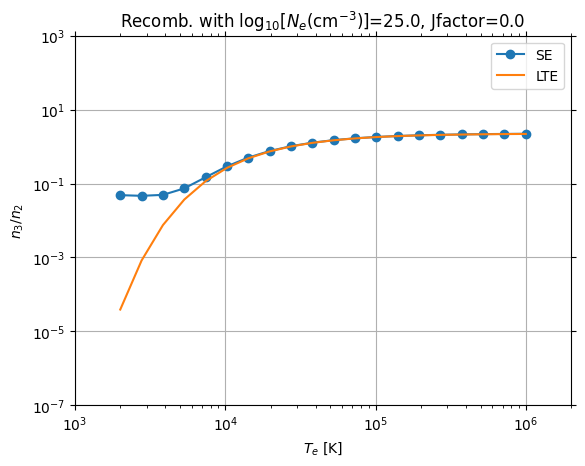

In [19]:
# WL_23=656.28*1e-9*1e2 #cm
# E_23=Cst.h_*Cst.c_/WL_23
# g3=18
# g2=8

# N_te= 20
# Te_list = 10**(np.linspace(np.log10(2e3), 6, N_te))

# n3_n2=g3/g2*np.exp(-E_23/(Cst.k_*Te_list))

# def plot_Re_LTE(i, path=''):
#     plt.cla()
#     plt.close
#     plt.plot(Te_list, Re_pops_te_ne[:,i,2]/Re_pops_te_ne[:,i,1], '-o', label='SE')
    
#     plt.plot(Te_list, n3_n2, '-', label='LTE')
    
#     plt.legend()
    
#     plt.xscale('log')
#     plt.yscale('log')
    
#     plt.xlim(1e3, 2e6)
#     plt.ylim(1e-7, 1e3)
    
#     plt.xlabel(r'$T_e$ [K]')
#     plt.ylabel(r'$n_3/n_2$')
    
#     plt.title('Recomb. with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    
#     plt.grid()
    
    
    
#     plt.savefig(path+'/result_{:0=3}.png'.format(i))

# path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Re/Re_comp_LTE/Jfactor_0"

# for i in range(N_ne):
#     plot_Re_LTE(i, path=path)

# Pop. to n=1

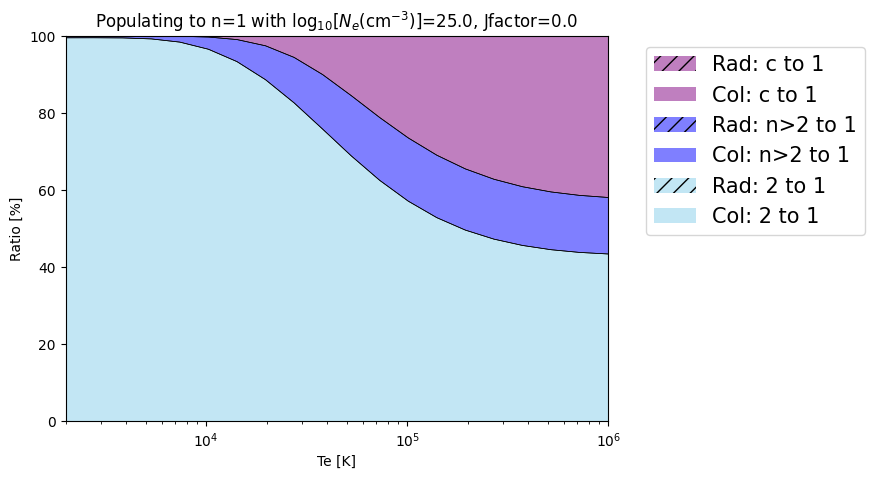

In [23]:
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Re/n1/Rate_to_n1_J0"

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    Rmat_dam=RmatRe_te_ne.copy()
    Cmat_dam=CmatRe_te_ne.copy()
    
    
    total=(np.sum(Rmat_dam[:,i,0,:], axis=1) + np.sum(Cmat_dam[:,i,0,:], axis=1))*1e-2
    
    R21=Rmat_dam[:,i,0,1]/total
    Rh1=np.sum(Rmat_dam[:,i,0,2:-1], axis=1)/total
    Rc1=Rmat_dam[:,i,0,-1]/total

    C21=Cmat_dam[:,i,0,1]/total
    Ch1=np.sum(Cmat_dam[:,i,0,2:-1], axis=1)/total
    Cc1=Cmat_dam[:,i,0,-1]/total

    y0=0.0
    y1=C21.copy()
    y2=y1+R21
    y3=y2+Ch1
    z1=y3+Rh1
    z2=z1+Cc1
    z3=z2+Rc1
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, z3, c=c, ls=ls, lw=lw)
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='skyblue', alpha=alpha, label='Col: 2 to 1')
    ax.fill_between(Te_list, y1, y2, facecolor='skyblue', alpha=alpha, label='Rad: 2 to 1', hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='blue', alpha=alpha, label='Col: n>2 to 1')

    alpha=0.5
    ax.fill_between(Te_list, y3, z1, facecolor='blue', alpha=alpha, label='Rad: n>2 to 1', hatch='//')
    ax.fill_between(Te_list, z1, z2, facecolor='purple', alpha=alpha, label='Col: c to 1')
    ax.fill_between(Te_list, z2, z3, facecolor='purple', alpha=alpha, label='Rad: c to 1', hatch='//')
    

   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating to n=1 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(10)

# Depop. from n=1

C:\Users\kutak\AppData\Local\Temp\ipykernel_17892\120017446.py:13: RuntimeWarning: invalid value encountered in true_divide
  R12=Rmat_dam[:,n,1,0]/total
C:\Users\kutak\AppData\Local\Temp\ipykernel_17892\120017446.py:14: RuntimeWarning: invalid value encountered in true_divide
  R1h=np.sum(Rmat_dam[:,n,2:-1,0], axis=1)/total
C:\Users\kutak\AppData\Local\Temp\ipykernel_17892\120017446.py:15: RuntimeWarning: invalid value encountered in true_divide
  R1c=Rmat_dam[:,n,-1,0]/total
C:\Users\kutak\AppData\Local\Temp\ipykernel_17892\120017446.py:17: RuntimeWarning: invalid value encountered in true_divide
  C12=Cmat_dam[:,n,1,0]/total
C:\Users\kutak\AppData\Local\Temp\ipykernel_17892\120017446.py:18: RuntimeWarning: invalid value encountered in true_divide
  C1h=np.sum(Cmat_dam[:,n,2:-1,0], axis=1)/total
C:\Users\kutak\AppData\Local\Temp\ipykernel_17892\120017446.py:19: RuntimeWarning: invalid value encountered in true_divide
  C1c=Cmat_dam[:,n,-1,0]/total


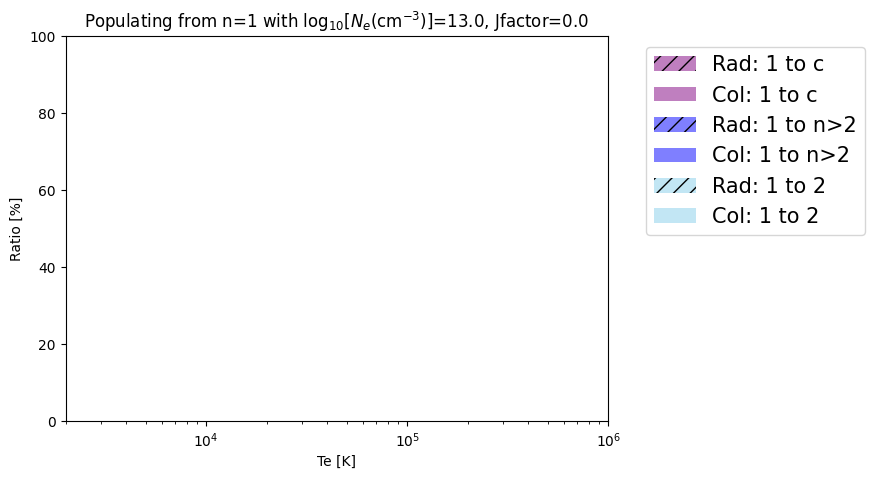

In [24]:
#n1=0.0 -> the following calculation does not work well (just zero)

# path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Re/n1/Rate_from_n1_J0"

# def plot_rate(n, path=''):
#     plt.cla()
#     plt.close()

#     fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
#     Rmat_dam=RmatRe_te_ne.copy()
#     Cmat_dam=CmatRe_te_ne.copy()
    
    
#     total=(np.sum(Rmat_dam[:,n,:,0], axis=1) + np.sum(Cmat_dam[:,n,:,0], axis=1))*1e-2
#     R12=Rmat_dam[:,n,1,0]/total
#     R1h=np.sum(Rmat_dam[:,n,2:-1,0], axis=1)/total
#     R1c=Rmat_dam[:,n,-1,0]/total

#     C12=Cmat_dam[:,n,1,0]/total
#     C1h=np.sum(Cmat_dam[:,n,2:-1,0], axis=1)/total
#     C1c=Cmat_dam[:,n,-1,0]/total

#     y0=0.0
#     y1=C12.copy()
#     y2=y1+R12
#     y3=y2+C1h
#     z1=y3+R1h
#     z2=z1+C1c
#     z3=z2+R1c
    
#     c='black'
#     ls='-'
#     lw=0.5
#     ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
#     ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
#     ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
#     ax.plot(Te_list, z1, c=c, ls=ls, lw=lw)
#     ax.plot(Te_list, z2, c=c, ls=ls, lw=lw)
#     ax.plot(Te_list, z3, c=c, ls=ls, lw=lw)
    
    

#     alpha=0.5
#     ax.fill_between(Te_list, y0, y1, facecolor='skyblue', alpha=alpha, label='Col: 1 to 2')
#     ax.fill_between(Te_list, y1, y2, facecolor='skyblue', alpha=alpha, label='Rad: 1 to 2', hatch='//')
#     ax.fill_between(Te_list, y2, y3, facecolor='blue', alpha=alpha, label='Col: 1 to n>2')

#     alpha=0.5
#     ax.fill_between(Te_list, y3, z1, facecolor='blue', alpha=alpha, label='Rad: 1 to n>2', hatch='//')
#     ax.fill_between(Te_list, z1, z2, facecolor='purple', alpha=alpha, label='Col: 1 to c')
#     ax.fill_between(Te_list, z2, z3, facecolor='purple', alpha=alpha, label='Rad: 1 to c', hatch='//')
    

   
#     ax.set_xlabel('Te [K]')
#     ax.set_ylabel('Ratio [%]')

#     ax.set_xscale('log')
#     ax.set_ylim(0.0, 100.0)
#     ax.set_xlim(Te_list[0], Te_list[-1])

#     ax.set_title('Populating from n=1 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[n]))+', Jfactor={}'.format(Jfactor))
    
    
#     handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
#     ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])
    
#     #plt.savefig(path+'/result_{:0=3}.png'.format(n), bbox_inches='tight')
#     #plt.show()

#     #plt.grid()

# # for n in range(N_ne):
# #     # plt.cla()
# #     # plt.close()
    
# #     plot_rate(n, path=path)
    
   

# plot_rate(5, path=path)

# Pop. to n=2

100.0
100.0
100.0
100.0
100.00000000000001
100.0
99.99999999999999
100.0
100.0
99.99999999999999
100.0
100.0
99.99999999999997
99.99999999999999
99.99999999999999
100.0
100.0
100.00000000000001


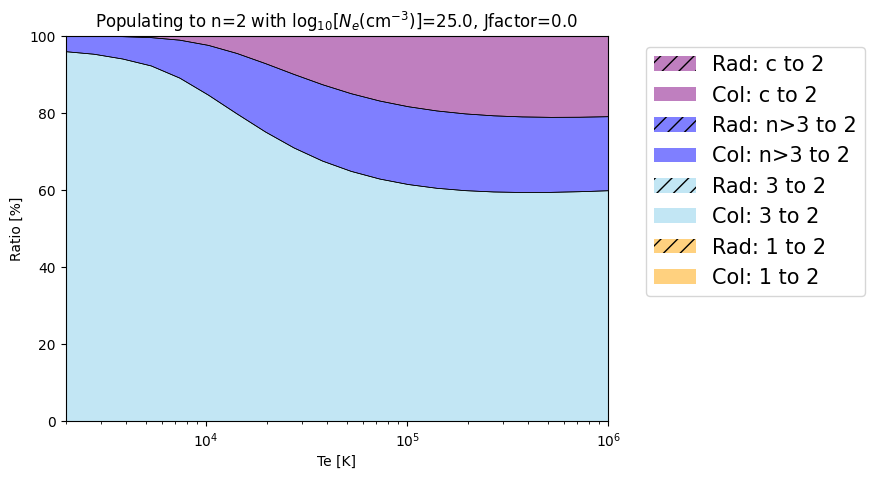

In [26]:
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Re/n2/Rate_to_n2_J0"
n=2-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    Rmat_dam=RmatRe_te_ne.copy()
    Cmat_dam=CmatRe_te_ne.copy()
    
    
    total=(np.sum(Rmat_dam[:,i,n,:], axis=1) + np.sum(Cmat_dam[:,i,n,:], axis=1))*1e-2
    
    R12=Rmat_dam[:,i,n,n-1]/total
    R32=Rmat_dam[:,i,n,n+1]/total
    Rh2=np.sum(Rmat_dam[:,i,n,n+2:-1], axis=1)/total
    Rc2=Rmat_dam[:,i,n,-1]/total

    C12=Cmat_dam[:,i,n,n-1]/total
    C32=Cmat_dam[:,i,n,n+1]/total
    Ch2=np.sum(Cmat_dam[:,i,n,n+2:-1], axis=1)/total
    Cc2=Cmat_dam[:,i,n,-1]/total
    
    y0=0.0
    y1=C12.copy()
    y2=y1+R12
    y3=y2+C32
    y4=y3+R32
    y5=y4+Ch2
    y6=y5+Rh2
    y7=y6+Cc2
    y8=y7+Rc2
    print(y8[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='orange', alpha=alpha, label='Col: 1 to 2')
    ax.fill_between(Te_list, y1, y2, facecolor='orange', alpha=alpha, label='Rad: 1 to 2', hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='skyblue', alpha=alpha, label='Col: 3 to 2')
    ax.fill_between(Te_list, y3, y4, facecolor='skyblue', alpha=alpha, label='Rad: 3 to 2', hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='blue', alpha=alpha, label='Col: n>3 to 2')
    ax.fill_between(Te_list, y5, y6, facecolor='blue', alpha=alpha, label='Rad: n>3 to 2', hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='purple', alpha=alpha, label='Col: c to 2')
    ax.fill_between(Te_list, y7, y8, facecolor='purple', alpha=alpha, label='Rad: c to 2', hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating to n=2 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

# Depop. from n=2

100.0
100.0
100.0
100.0
99.99999999999999
99.99999999999999
100.00000000000001
99.99999999999997
99.99999999999996
100.00000000000001
99.99999999999999
100.0
99.99999999999999
99.99999999999997
99.99999999999997
100.0
99.99999999999999
100.00000000000003


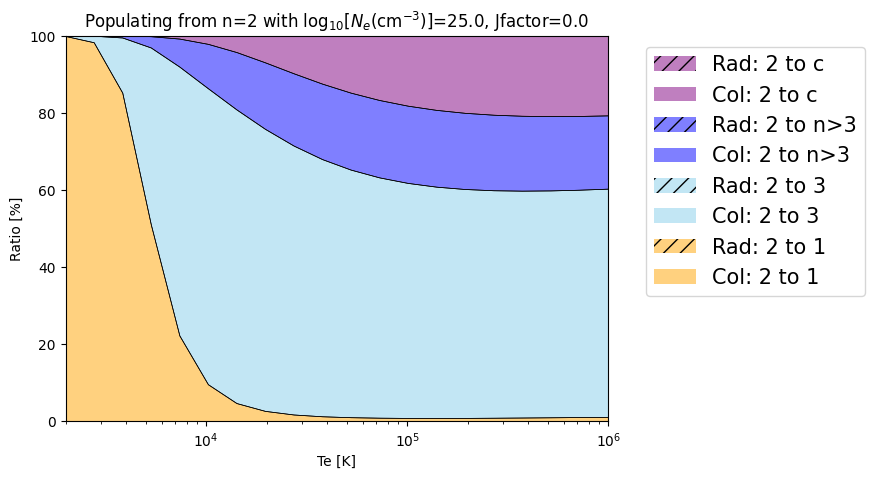

In [28]:
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Re/n2/Rate_from_n2_J0"
n=2-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    Rmat_dam=RmatRe_te_ne.copy()
    Cmat_dam=CmatRe_te_ne.copy()
    
    
    total=(np.sum(Rmat_dam[:,i,:,n], axis=1) + np.sum(Cmat_dam[:,i,:,n], axis=1))*1e-2
    
    R21=Rmat_dam[:,i,n-1,n]/total
    R23=Rmat_dam[:,i,n+1,n]/total
    R2h=np.sum(Rmat_dam[:,i,n+2:-1,n], axis=1)/total
    R2c=Rmat_dam[:,i,-1,n]/total

    C21=Cmat_dam[:,i,n-1,n]/total
    C23=Cmat_dam[:,i,n+1,n]/total
    C2h=np.sum(Cmat_dam[:,i,n+2:-1,n], axis=1)/total
    C2c=Cmat_dam[:,i,-1,n]/total
    
    y0=0.0
    y1=C21.copy()
    y2=y1+R21
    y3=y2+C23
    y4=y3+R23
    y5=y4+C2h
    y6=y5+R2h
    y7=y6+C2c
    y8=y7+R2c
    print(y8[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='orange', alpha=alpha, label='Col: 2 to 1')
    ax.fill_between(Te_list, y1, y2, facecolor='orange', alpha=alpha, label='Rad: 2 to 1', hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='skyblue', alpha=alpha, label='Col: 2 to 3')
    ax.fill_between(Te_list, y3, y4, facecolor='skyblue', alpha=alpha, label='Rad: 2 to 3', hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='blue', alpha=alpha, label='Col: 2 to n>3')
    ax.fill_between(Te_list, y5, y6, facecolor='blue', alpha=alpha, label='Rad: 2 to n>3', hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='purple', alpha=alpha, label='Col: 2 to c')
    ax.fill_between(Te_list, y7, y8, facecolor='purple', alpha=alpha, label='Rad: 2 to c', hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating from n=2 with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

# Pop. to n>2

100.0
99.99999999999997
99.99999999999999
100.00000000000001
99.99999999999999
100.00000000000003
100.00000000000001
99.99999999999999
99.99999999999999
100.0
99.99999999999999
100.00000000000003
100.0
100.0
100.00000000000003
100.0
100.00000000000001
100.00000000000001


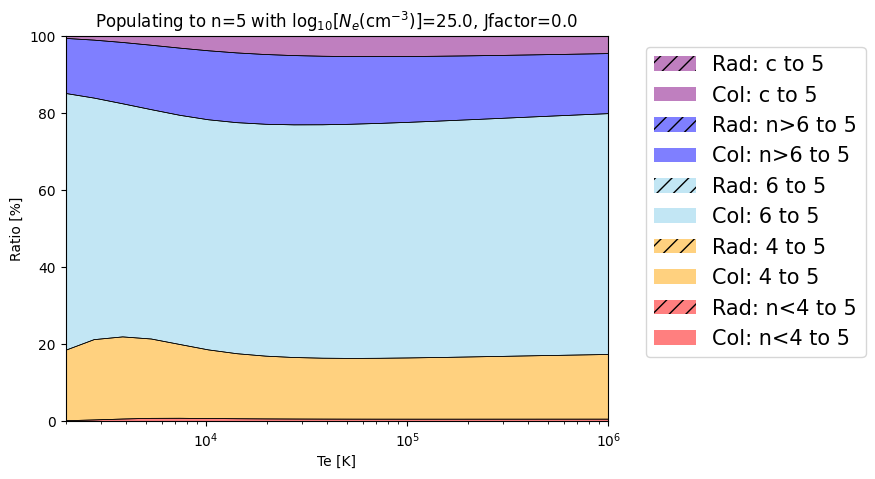

In [32]:
nn_level=5
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Re/"+"n{0}/Rate_to_n{0}_J0".format(nn_level)
n=nn_level-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    Rmat_dam=RmatRe_te_ne.copy()
    Cmat_dam=CmatRe_te_ne.copy()
    
    total=(np.sum(Rmat_dam[:,i,n,:], axis=1) + np.sum(Cmat_dam[:,i,n,:], axis=1))*1e-2

    Rln=np.sum(Rmat_dam[:,i,n,0:n-1], axis=1)/total
    Rnm1n=Rmat_dam[:,i,n,n-1]/total
    Rnp1n=Rmat_dam[:,i,n,n+1]/total
    Rhn=np.sum(Rmat_dam[:,i,n,n+2:-1], axis=1)/total
    Rcn=Rmat_dam[:,i,n,-1]/total

    Cln=np.sum(Cmat_dam[:,i,n,0:n-1], axis=1)/total
    Cnm1n=Cmat_dam[:,i,n,n-1]/total
    Cnp1n=Cmat_dam[:,i,n,n+1]/total
    Chn=np.sum(Cmat_dam[:,i,n,n+2:-1], axis=1)/total
    Ccn=Cmat_dam[:,i,n,-1]/total

    y0=0.0
    y1=Cln.copy()
    y2=y1+Rln
    y3=y2+Cnm1n
    y4=y3+Rnm1n
    y5=y4+Cnp1n
    y6=y5+Rnp1n
    y7=y6+Chn
    y8=y7+Rhn
    y9=y8+Ccn
    y10=y9+Rcn
    
    print(y10[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y9, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y10, c=c, ls=ls, lw=lw)
    
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='red', alpha=alpha, label='Col: n<{0} to {1}'.format(n,n+1))
    ax.fill_between(Te_list, y1, y2, facecolor='red', alpha=alpha, label='Rad: n<{0} to {1}'.format(n,n+1), hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='orange', alpha=alpha, label='Col: {0} to {1}'.format(n, n+1))
    ax.fill_between(Te_list, y3, y4, facecolor='orange', alpha=alpha, label='Rad: {0} to {1}'.format(n, n+1), hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='skyblue', alpha=alpha, label='Col: {0} to {1}'.format(n+2, n+1))
    ax.fill_between(Te_list, y5, y6, facecolor='skyblue', alpha=alpha, label='Rad: {0} to {1}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='blue', alpha=alpha, label='Col: n>{0} to {1}'.format(n+2, n+1))
    ax.fill_between(Te_list, y7, y8, facecolor='blue', alpha=alpha, label='Rad: n>{0} to {1}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y8, y9, facecolor='purple', alpha=alpha, label='Col: c to {}'.format(n+1))
    ax.fill_between(Te_list, y9, y10, facecolor='purple', alpha=alpha, label='Rad: c to {}'.format(n+1), hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating to '+'n={} '.format(n+1) +'with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

# Depop. from n>2

100.0
100.0
100.00000000000003
100.00000000000001
99.99999999999999
100.0
99.99999999999999
100.0
99.99999999999997
99.99999999999997
99.99999999999999
99.99999999999996
99.99999999999999
99.99999999999997
100.00000000000001
100.0
100.0
99.99999999999996


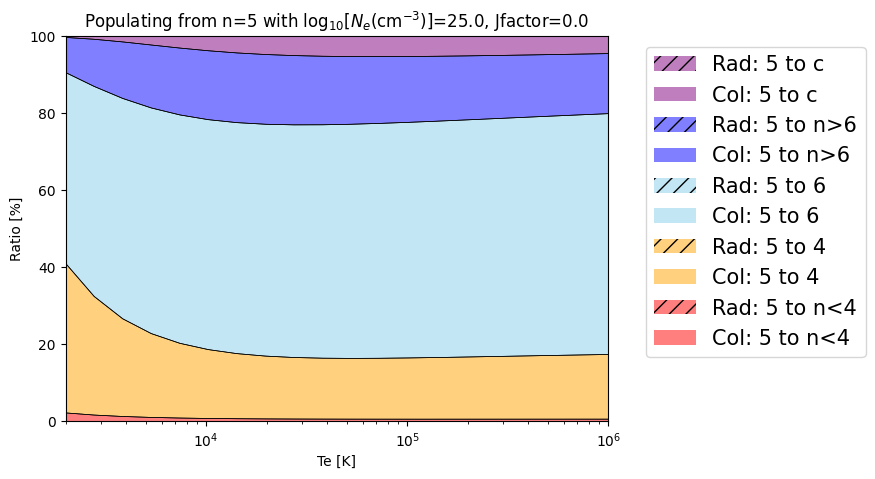

In [35]:
nn_level=5
path=r"C:/Users\kutak/ドキュメント/0Materials/Otsu_post-flare-loops/spectra/Figs/Re/"+"n{0}/Rate_from_n{0}_J0".format(nn_level)
n=nn_level-1

def plot_rate(i, path=''):
    plt.cla()
    plt.close()

    fig,ax=plt.subplots(1,1,figsize=(7,5), facecolor='white')
    Rmat_dam=RmatRe_te_ne.copy()
    Cmat_dam=CmatRe_te_ne.copy()
    
    
    total=(np.sum(Rmat_dam[:,i,:,n], axis=1) + np.sum(Cmat_dam[:,i,:,n], axis=1))*1e-2

    Rln=np.sum(Rmat_dam[:,i,0:n-1,n], axis=1)/total
    Rnm1n=Rmat_dam[:,i,n-1,n]/total
    Rnp1n=Rmat_dam[:,i,n+1,n]/total
    Rhn=np.sum(Rmat_dam[:,i,n+2:-1,n], axis=1)/total
    Rcn=Rmat_dam[:,i,-1,n]/total

    Cln=np.sum(Cmat_dam[:,i,0:n-1,n], axis=1)/total
    Cnm1n=Cmat_dam[:,i,n-1,n]/total
    Cnp1n=Cmat_dam[:,i,n+1,n]/total
    Chn=np.sum(Cmat_dam[:,i,n+2:-1,n], axis=1)/total
    Ccn=Cmat_dam[:,i,-1,n]/total

    y0=0.0
    y1=Cln.copy()
    y2=y1+Rln
    y3=y2+Cnm1n
    y4=y3+Rnm1n
    y5=y4+Cnp1n
    y6=y5+Rnp1n
    y7=y6+Chn
    y8=y7+Rhn
    y9=y8+Ccn
    y10=y9+Rcn
    
    print(y10[-1])
    
    c='black'
    ls='-'
    lw=0.5
    ax.plot(Te_list, y1, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y2, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y3, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y4, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y5, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y6, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y7, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y8, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y9, c=c, ls=ls, lw=lw)
    ax.plot(Te_list, y10, c=c, ls=ls, lw=lw)
    
    
    
    

    alpha=0.5
    ax.fill_between(Te_list, y0, y1, facecolor='red', alpha=alpha, label='Col: {1} to n<{0}'.format(n,n+1))
    ax.fill_between(Te_list, y1, y2, facecolor='red', alpha=alpha, label='Rad: {1} to n<{0}'.format(n,n+1), hatch='//')
    ax.fill_between(Te_list, y2, y3, facecolor='orange', alpha=alpha, label='Col: {1} to {0}'.format(n, n+1))
    ax.fill_between(Te_list, y3, y4, facecolor='orange', alpha=alpha, label='Rad: {1} to {0}'.format(n, n+1), hatch='//')
    ax.fill_between(Te_list, y4, y5, facecolor='skyblue', alpha=alpha, label='Col: {1} to {0}'.format(n+2, n+1))
    ax.fill_between(Te_list, y5, y6, facecolor='skyblue', alpha=alpha, label='Rad: {1} to {0}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y6, y7, facecolor='blue', alpha=alpha, label='Col: {1} to n>{0}'.format(n+2, n+1))
    ax.fill_between(Te_list, y7, y8, facecolor='blue', alpha=alpha, label='Rad: {1} to n>{0}'.format(n+2, n+1), hatch='//')
    ax.fill_between(Te_list, y8, y9, facecolor='purple', alpha=alpha, label='Col: {} to c'.format(n+1))
    ax.fill_between(Te_list, y9, y10, facecolor='purple', alpha=alpha, label='Rad: {} to c'.format(n+1), hatch='//')
    


   
    ax.set_xlabel('Te [K]')
    ax.set_ylabel('Ratio [%]')

    ax.set_xscale('log')
    ax.set_ylim(0.0, 100.0)
    ax.set_xlim(Te_list[0], Te_list[-1])

    ax.set_title('Populating from '+'n={} '.format(n+1) +'with log$_{10}[N_e$(cm$^{-3}$)]' +'={:.1f}'.format(np.log10(Ne_list[i]))+', Jfactor={}'.format(Jfactor))
    handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=15, ncol=1, handles=handles[::-1], labels=labels[::-1])


    plt.savefig(path+'/result_{:0=3}.png'.format(i), bbox_inches='tight')
    

    #plt.grid()


for i in range(N_ne):
    # plt.cla()
    # plt.close()
    
    plot_rate(i, path=path)
    
#plot_rate(8)

In [ ]:
WL_12=121.6*1e-9*1e2 #cm
E_12=Cst.h_*Cst.c_/WL_12
g2=8
g1=2

N_te= 20
Te_list = 10**(np.linspace(np.log10(2e3), 6, N_te))

n2_n1=g2/g1*np.exp(-E_12/(Cst.k_*Te_list))


plt.plot(Te_list, n2_n1)

In [33]:
Rmat_te_ne.shape

(20, 20, 21, 21)

In [38]:
np.log10(Ne_list[8])

10.947368421052632

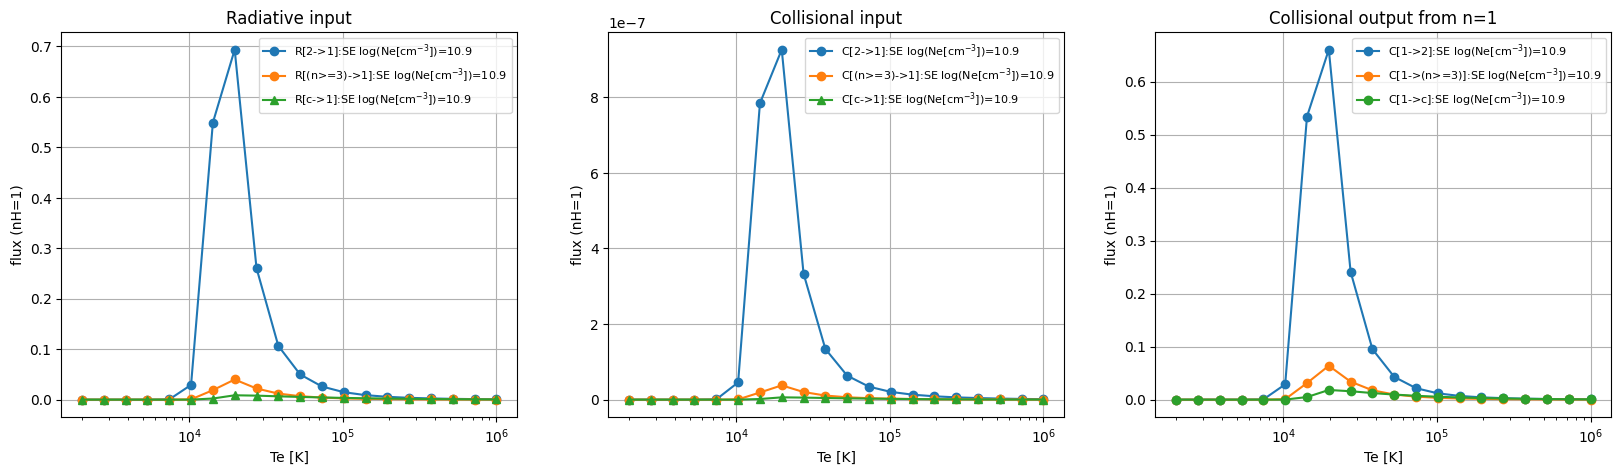

In [19]:

fig,axs=plt.subplots(1,3,figsize=(20, 5))
I=8

ax=axs[0]
j=0
i=1
Rin_2=Rmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, Rin_2, '-o', label='R[2->1]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))

j=0
i=2
Rin_3to20=np.sum(Rmat_te_ne[:,I,0,2:-1], axis=1)

ax.plot(Te_list, Rin_3to20, '-o', label='R[(n>=3)->1]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))


j=0
i=20
Rin_c=Rmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, Rin_c, '-^', label='R[c->1]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))
ax.set_title('Radiative input')

#--------------------------
ax=axs[1]
j=0
i=1
Cin_2=Cmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, Cin_2, '-o', label='C[2->1]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))

j=0
i=2
Cin_3to20=np.sum(Cmat_te_ne[:,I,0,2:-1], axis=1)

ax.plot(Te_list, Cin_3to20, '-o', label='C[(n>=3)->1]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))

j=0
i=20
Cin_c=Cmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, Cin_c, '-^', label='C[c->1]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))
ax.set_title('Collisional input')
#------------------------
ax=axs[2]
j=1
i=0
pl_2=Cmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, pl_2, '-o', label='C[1->2]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))

# j=2
# i=0
pl_3to20=np.sum(Cmat_te_ne[:,I,2:-1,0], axis=1)
ax.plot(Te_list, pl_3to20, '-o', label='C[1->(n>=3)]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))

j=20
i=0
pl_c=Cmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, pl_c, '-o', label='C[1->c]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))
ax.set_title('Collisional output from n=1')
for i in range(3):
    axs[i].set_xscale('log')
    #axs[i].set_yscale('log')
    axs[i].set_xlabel('Te [K]')
    axs[i].set_ylabel('flux (nH=1)')
    axs[i].grid()
    axs[i].legend(fontsize=8)
    #axs[i].set_ylim(-1e-4,1e-3)

#plt.legend()

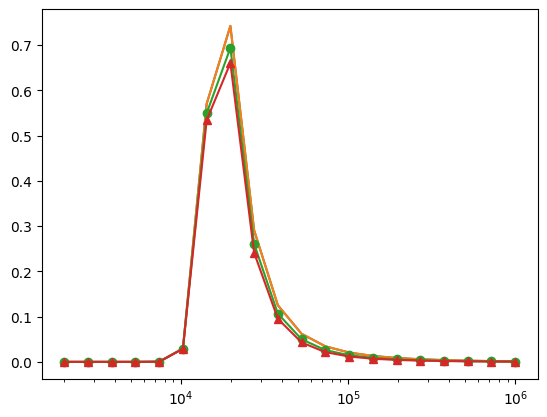

In [20]:
plt.plot(Te_list, pl_2+pl_3to20+pl_c)
plt.plot(Te_list, (Rin_2+Cin_2+Rin_3to20+Cin_3to20+Rin_c+Cin_c))

plt.plot(Te_list, Rin_2, '-o')
plt.plot(Te_list, pl_2, '-^')


plt.xscale('log')

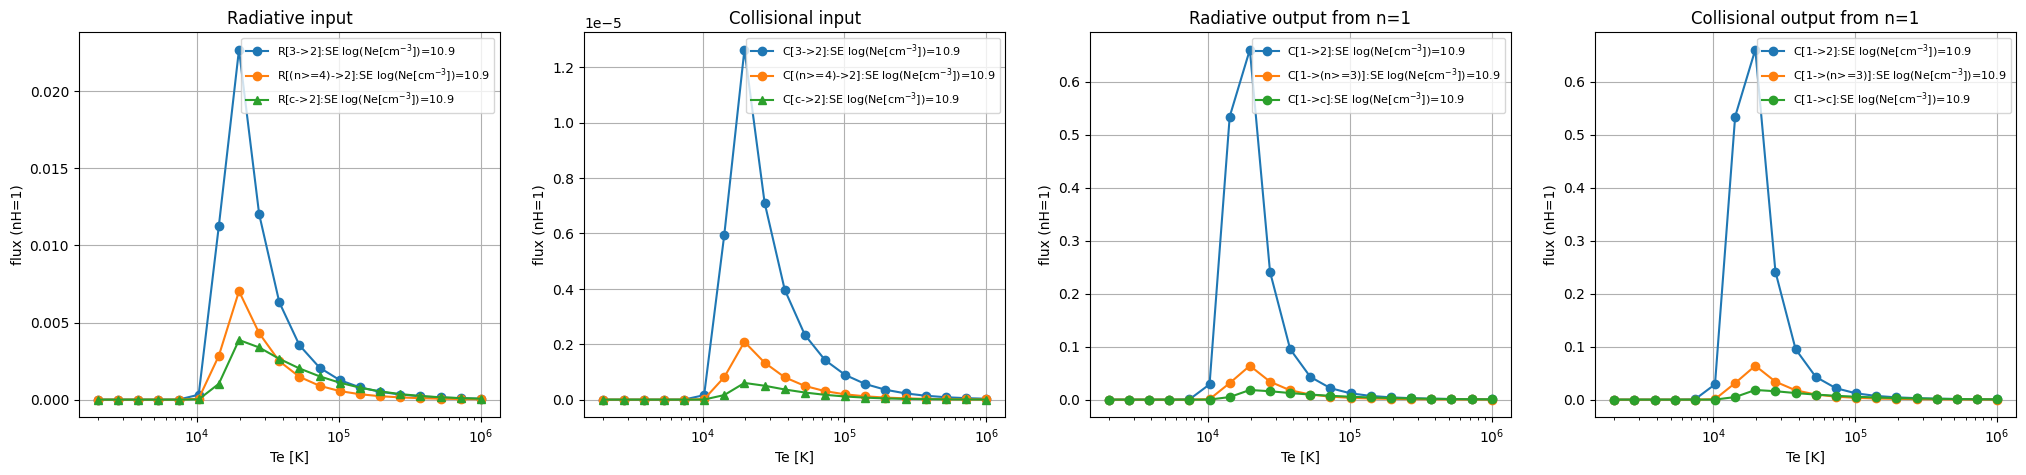

In [24]:

fig,axs=plt.subplots(1,4,figsize=(25, 5))
I=8

ax=axs[0]
j=1
i=2
Rin_2=Rmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, Rin_2, '-o', label='R[3->2]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))


Rin_3to20=np.sum(Rmat_te_ne[:,I,1,3:-1], axis=1)

ax.plot(Te_list, Rin_3to20, '-o', label='R[(n>=4)->2]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))


j=1
i=20
Rin_c=Rmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, Rin_c, '-^', label='R[c->2]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))
ax.set_title('Radiative input')

#--------------------------
ax=axs[1]
j=1
i=2
Cin_2=Cmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, Cin_2, '-o', label='C[3->2]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))

j=0
i=2
Cin_3to20=np.sum(Cmat_te_ne[:,I,1,3:-1], axis=1)

ax.plot(Te_list, Cin_3to20, '-o', label='C[(n>=4)->2]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))

j=1
i=20
Cin_c=Cmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, Cin_c, '-^', label='C[c->2]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))
ax.set_title('Collisional input')
#------------------------
ax=axs[2]
j=1
i=0
pl_2=Cmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, pl_2, '-o', label='C[1->2]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))

# j=2
# i=0
pl_3to20=np.sum(Cmat_te_ne[:,I,2:-1,0], axis=1)
ax.plot(Te_list, pl_3to20, '-o', label='C[1->(n>=3)]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))

j=20
i=0
pl_c=Cmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, pl_c, '-o', label='C[1->c]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))
ax.set_title('Radiative output from n=2')

#------------------------
ax=axs[3]
j=1
i=0
pl_2=Cmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, pl_2, '-o', label='C[1->2]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))

# j=2
# i=0
pl_3to20=np.sum(Cmat_te_ne[:,I,2:-1,0], axis=1)
ax.plot(Te_list, pl_3to20, '-o', label='C[1->(n>=3)]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))

j=20
i=0
pl_c=Cmat_te_ne[:,I,j,i].copy()
ax.plot(Te_list, pl_c, '-o', label='C[1->c]:'+r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])))
ax.set_title('Collisional output from n=2')


for i in range(4):
    axs[i].set_xscale('log')
    #axs[i].set_yscale('log')
    axs[i].set_xlabel('Te [K]')
    axs[i].set_ylabel('flux (nH=1)')
    axs[i].grid()
    axs[i].legend(fontsize=8)
    #axs[i].set_ylim(-1e-4,1e-3)

#plt.legend()

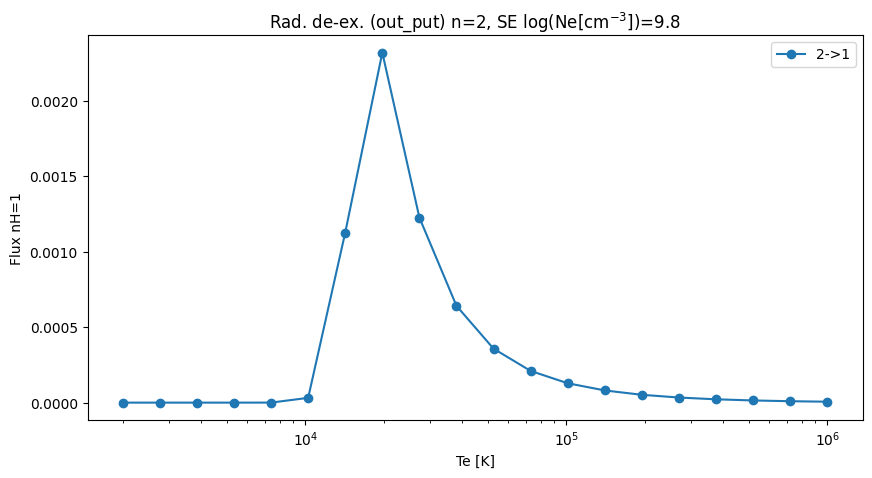

In [59]:
fig,ax=plt.subplots(1,1,figsize=(10,5))
tn=2
I=5

in_out='(out_put)'
ex_deex='de-ex.'
rad_col='Rad.'
title=rad_col+' '+ex_deex+' '+in_out+' '+'n={}, '.format(tn) + r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I]))

pl0=Rmat_te_ne[:,I,0,tn].copy() #2->1
label0='2->1'
#pl1=


ax.set_title(title)
ax.plot(Te_list, pl0, '-o', label=label0)
ax.set_xscale('log')
ax.set_xlabel('Te [K]')
ax.set_ylabel('Flux nH=1')
ax.legend()

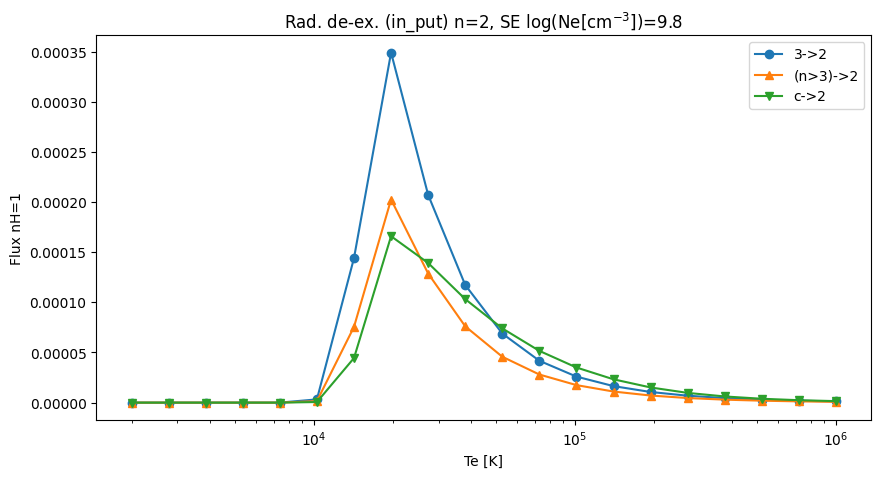

In [58]:
fig,ax=plt.subplots(1,1,figsize=(10,5))
tn=2
I=5

in_out='(in_put)'
ex_deex='de-ex.'
rad_col='Rad.'
title=rad_col+' '+ex_deex+' '+in_out+' '+'n={}, '.format(tn) + r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I]))

pl0=Rmat_te_ne[:,I,tn,tn+1].copy() #2->1
label0='3->2'

pl1=np.sum(Rmat_te_ne[:,I,tn,tn+2:-1].copy(), axis=1)
label1='(n>3)->2'

pl2=Rmat_te_ne[:,I,tn,-1].copy()
label2='c->2'


ax.set_title(title)
ax.plot(Te_list, pl0,'-o', label=label0)
ax.plot(Te_list, pl1,'-^', label=label1)
ax.plot(Te_list, pl2,'-v', label=label2)


ax.set_xscale('log')
ax.set_xlabel('Te [K]')
ax.set_ylabel('Flux nH=1')
ax.legend()

Text(0, 0.5, '$N_e$ [cm$^{-3}$]')

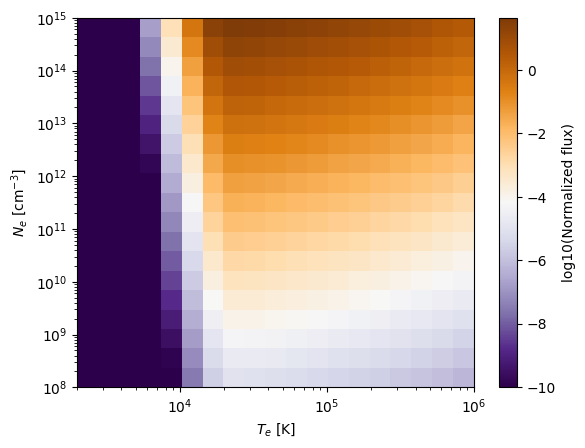

In [76]:
TeTe, NeNe=np.meshgrid(Te_list, Ne_list)
#pl=SE_pops_te_ne[:,:,0]/SE_pops_te_ne[:,:,-1]

st=-1
fi=0
#pl= Rmat_te_ne[:,:,0,1].copy()
pl= Rmat_te_ne[:,:, fi,st].copy()


im=plt.pcolormesh(TeTe, NeNe, np.log10(pl.T) ,cmap='PuOr_r', vmin=-10)
plt.colorbar(im, label='log10(Normalized flux)')
#plt.contour(TeTe, NeNe, np.log10(pl.T))

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$T_e$ [K]')
plt.ylabel(r'$N_e$ [cm$^{-3}$]')

Text(0, 0.5, '$N_e$ [cm$^{-3}$]')

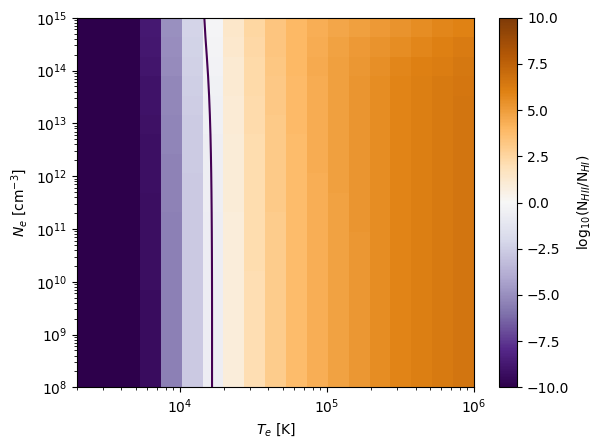

In [128]:
from matplotlib.colors import LogNorm


TeTe, NeNe=np.meshgrid(Te_list, Ne_list)
#pl=SE_pops_te_ne[:,:,0]/SE_pops_te_ne[:,:,-1]
pl= SE_pops_te_ne[:,:,-1] / np.sum(SE_pops_te_ne[:,:,0:-1], axis=2) 

im=plt.pcolormesh(TeTe, NeNe, np.log10(pl.T) ,cmap='PuOr_r', vmax=10, vmin=-10)
plt.colorbar(im, label=r'log$_{10}$(N$_{HII}$/N$_{HI}$)')
plt.contour(TeTe, NeNe, np.log10(pl.T), [0] )

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$T_e$ [K]')
plt.ylabel(r'$N_e$ [cm$^{-3}$]')

Text(0, 0.5, '$N_e$ [cm$^{-3}$]')

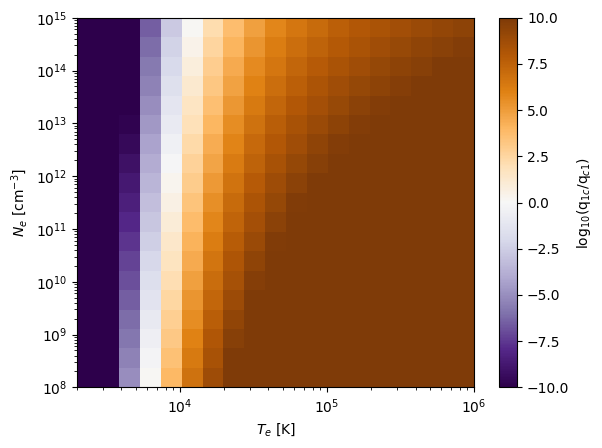

In [130]:
TeTe, NeNe=np.meshgrid(Te_list, Ne_list)
#pl=SE_pops_te_ne[:,:,0]/SE_pops_te_ne[:,:,-1]
pl= (Cmat_te_ne[:,:,-1,0]/SE_pops_te_ne[:,:,0])/(Cmat_te_ne[:,:,0,-1]/SE_pops_te_ne[:,:,-1])
im=plt.pcolormesh(TeTe, NeNe, np.log10(pl.T) ,cmap='PuOr_r', vmax=10, vmin=-10)
plt.colorbar(im, label=r'log$_{10}$(q$_{1c}$/q$_{c1}$)')
#plt.contour(TeTe, NeNe, np.log10(pl.T), [0] )

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$T_e$ [K]')
plt.ylabel(r'$N_e$ [cm$^{-3}$]')



Text(0.5, 1.0, 'SE')

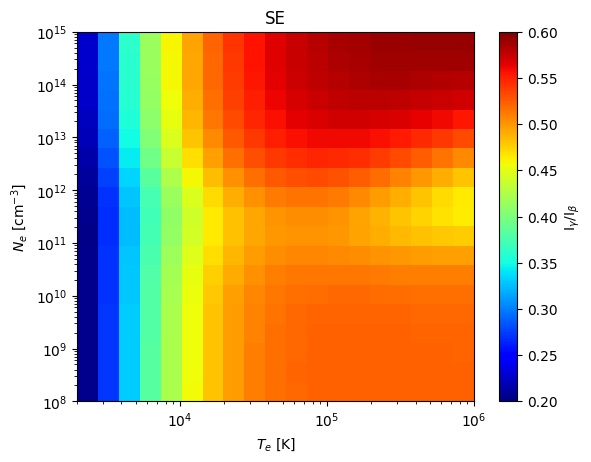

In [117]:
TeTe, NeNe=np.meshgrid(Te_list, Ne_list)

nl = 2  # lower level n,  nl=2 for Balmer series
idxI = atom.Line['idxI']
jj = np.where(idxI == nl)
Aji = atom.Line['AJI'][jj]
idxJ = atom.Line['idxJ'][jj]
eps = Cst.h_*Cst.c_/atom.Line['w0'][jj]

n_h=4#H-beta
Nj0 = SE_pops_te_ne[:,:,n_h]
I_Hy=Aji[n_h-3]*Nj0*eps[n_h-3]

n_h=5#H-gamma
Nj0 = SE_pops_te_ne[:,:,n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]

pl= I_Hx/I_Hy

im=plt.pcolormesh(TeTe, NeNe, pl.T ,cmap='jet', vmin=0.2, vmax=0.6)
plt.colorbar(im, label=r'I$_{\gamma}$/I$_{\beta}$')
#plt.contour(TeTe, NeNe, np.log10(pl.T), [0] )

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$T_e$ [K]')
plt.ylabel(r'$N_e$ [cm$^{-3}$]')

plt.title('SE')

Text(0.5, 1.0, 'SE')

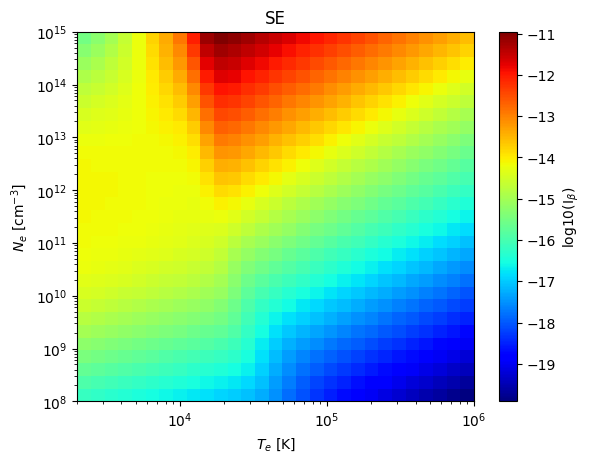

In [99]:
TeTe, NeNe=np.meshgrid(Te_list, Ne_list)

nl = 2  # lower level n,  nl=2 for Balmer series
idxI = atom.Line['idxI']
jj = np.where(idxI == nl)
Aji = atom.Line['AJI'][jj]
idxJ = atom.Line['idxJ'][jj]
eps = Cst.h_*Cst.c_/atom.Line['w0'][jj]

n_h=4#H-beta
Nj0 = SE_pops_te_ne[:,:,n_h]
I_Hy=Aji[n_h-3]*Nj0*eps[n_h-3]

n_h=5#H-gamma
Nj0 = SE_pops_te_ne[:,:,n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]

pl= np.log10(I_Hy)

im=plt.pcolormesh(TeTe, NeNe, pl.T ,cmap='jet')
plt.colorbar(im, label=r'log10(I$_{\beta}$)')
#plt.contour(TeTe, NeNe, np.log10(pl.T), [0] )

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$T_e$ [K]')
plt.ylabel(r'$N_e$ [cm$^{-3}$]')

plt.title('SE')

# Ionizing

In [88]:
def calc_NIE(atom, slab, wMesh, solar_spec, n1, n_proton):
    ## use rate_only=True to acquire the transition matrix (R matrix and C matrix) without solving linear equation
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, solar_spec, None, rate_only=True)  #  level populations etc.
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rate.Rmat, Rate.Cmat)
    # print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    # print(f"Amat has shape: {A.shape}")
    b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    ## solve Ax=b
    nArr = np.linalg.solve(A, b) ## population density for levels n=2,3,...,N
    #print(f"nArr shape: {nArr.shape}")
    pop = np.zeros(len(nArr)+2)
    pop[0] = n1 ; pop[1:-1] = nArr ; pop[-1] = n_proton
    Nh = pop.sum()
    SE.n_SE = pop/Nh
    SE.Nh = Nh
    SE.Te = slab.Te
    SE.Ne = slab.Ne

    return(SE,Rate)

In [89]:
#Fixed parameters
Nh= 1.E11 #arbitary if we use normalized pop.
Te = 1e4#10000.
#Ne = 1.E10#1.E10
Vd = 0.
Vt = 5e5 #cm/s 
Jfactor = 0.0#1.   # intensity of solar radiation
#Nes = [1E8, 1E9, 1E10, 1E11, 1E12]
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  

#slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
N_ne= 20
N_te= 20
N_level = 21
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

Ne_list = 10**(np.linspace(8, 15, N_ne)) # density list
Te_list = 10**(np.linspace(np.log10(2e3), 6, N_te)) # temperature list
Io_pops_te_ne = np.zeros([N_te, N_ne, N_level]) # SE pop. list
n1 = 1.E10  ; n_proton = 0.E0  # cm-3,  ionizing plasma
RmatIo_te_ne = np.zeros([N_te, N_ne, N_level,N_level]) # SE pop. list
CmatIo_te_ne = np.zeros([N_te, N_ne, N_level, N_level]) # SE pop. list

for i in range(N_te):
    for j in range(N_ne):
        slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne_list[j], Te=Te_list[i], Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
        SE0, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton) 
    
        Io_pops_te_ne[i,j,:]=SE0.n_SE.copy()
        RmatIo_te_ne[i,j,:,:]=Rate.Rmat*SE0.n_SE
        CmatIo_te_ne[i,j,:,:]=Rate.Cmat*SE0.n_SE
        print(i, j)



# N_ne= 9
# N_level = 21
# n_lev = np.size(atom.Level)-1
# n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

# Ne_list = 10**(np.linspace(8, 12, N_ne)) # temperature list
# Io_pops_dens = np.zeros([N_ne, N_level]) # SE pop. list

# n1 = 1.E10  ; n_proton = 0.E0  # cm-3,  ionizing plasma
# #SE1, Rate1 = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)

# for i in range(N_ne):
#     slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne_list[i], Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
#     SE0, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton) 

#     Io_pops_dens[i, :]=SE0.n_SE.copy()

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
1 18
1 19
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
2 18
2 19
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
3 18
3 19
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
4 10
4 11
4 12
4 13
4 14
4 15
4 16
4 17
4 18
4 19
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11
5 12
5 13
5 14
5 15
5 16
5 17
5 18
5 19
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
6 9
6 10
6 11
6 12
6 13
6 14
6 15
6 16
6 17
6 18
6 19
7 0
7 1
7 2
7 3
7 4
7 5
7 6
7 7
7 8
7 9
7 10
7 11
7 12
7 13
7 14
7 15
7 16
7 17
7 18
7 19
8 0
8 1
8 2
8 3
8 4
8 5
8 6
8 7
8 8
8 9
8 10
8 11
8 12
8 13
8 14
8 15
8 16
8 17
8 18
8 19
9 0
9 1
9 2
9 3
9 4
9 5
9 6
9 7
9 8
9 9
9 10
9 11
9 12
9 13
9 14
9 15
9 16
9 17
9 18
9 19
10 0
10 1
10 2
10 3
10 4
10 5
10 6
10 7
10 8
10 9
10 10
10 11
10 12
10 13
10 14
10 15
10 16
10 17
10

Text(0, 0.5, '$N_e$ [cm$^{-3}$]')

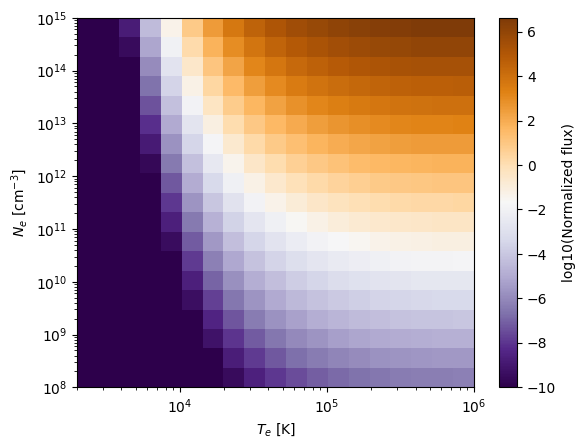

In [102]:
TeTe, NeNe=np.meshgrid(Te_list, Ne_list)
#pl=SE_pops_te_ne[:,:,0]/SE_pops_te_ne[:,:,-1]

st=1
fi=2
#pl= Rmat_te_ne[:,:,0,1].copy()
pl= CmatIo_te_ne[:,:, fi,st].copy()



im=plt.pcolormesh(TeTe, NeNe, np.log10(pl.T) ,cmap='PuOr_r', vmin=-10)
plt.colorbar(im, label='log10(Normalized flux)')
#plt.contour(TeTe, NeNe, np.log10(pl.T))

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$T_e$ [K]')
plt.ylabel(r'$N_e$ [cm$^{-3}$]')

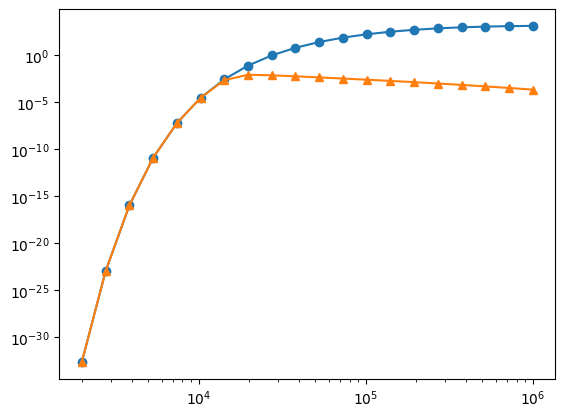

In [115]:
I=7
fi=-1
st=0
plt.plot(Te_list, CmatIo_te_ne[:,I, fi,st],'-o')
plt.plot(Te_list, Cmat_te_ne[:,I, fi,st], '-^')


plt.xscale('log')
plt.yscale('log')

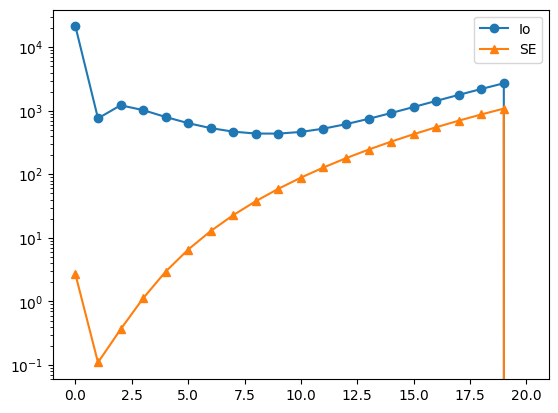

In [134]:
fi=-1
neI=15
teI=10#19
plt.plot(CmatIo_te_ne[teI, neI, fi,:],'-o', label='Io')
plt.plot(Cmat_te_ne[teI, neI, fi,:], '-^', label='SE')

plt.yscale('log')

plt.legend()

In [172]:
nn.shape

(20,)

(4.011285259962934, 12.052631578947368)

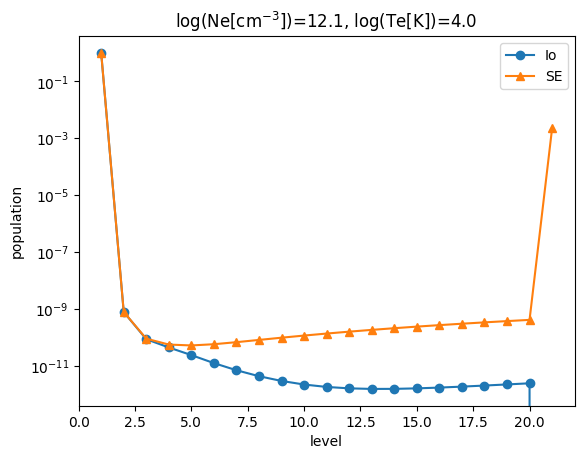

In [216]:
teI=5
neI=11

nn=np.arange(1,22,1).astype('int')

plt.plot(nn,Io_pops_te_ne[teI,neI], '-o', label='Io')
plt.plot(nn,SE_pops_te_ne[teI,neI], '-^', label='SE')

#plt.xscale('log')
plt.yscale('log')

plt.legend()

#plt.xlim(2,6)
#plt.ylim(1e-13, 1e-11)

plt.title(r'log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[neI]))+r', log(Te[K])='+'{:.1f}'.format(np.log10(Te_list[teI])))
plt.xlabel('level')
plt.ylabel('population')
np.log10(Te_list[teI]),np.log10(Ne_list[neI])



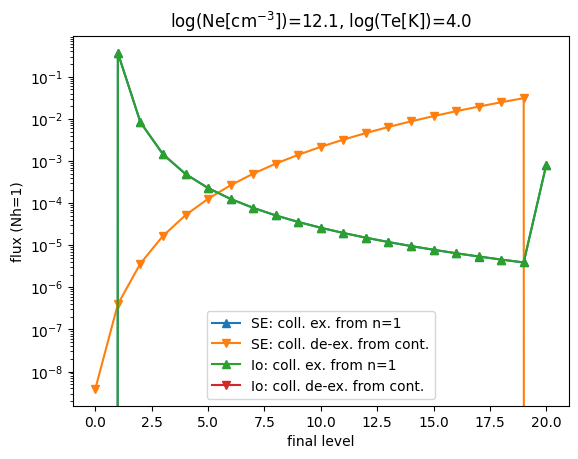

In [217]:
teI=5
neI=11#11

plt.plot(Cmat_te_ne[teI, neI, :, 0], '-^', label='SE: coll. ex. from n=1')
plt.plot(Cmat_te_ne[teI, neI, :, -1], '-v', label='SE: coll. de-ex. from cont.')

plt.plot(CmatIo_te_ne[teI, neI, :, 0], '-^', label='Io: coll. ex. from n=1')
plt.plot(CmatIo_te_ne[teI, neI, :, -1], '-v', label='Io: coll. de-ex. from cont.')


plt.yscale('log')
plt.title(r'log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[neI]))+r', log(Te[K])='+'{:.1f}'.format(np.log10(Te_list[teI])))
plt.xlabel('final level')
plt.ylabel('flux (Nh=1)')
plt.legend()

In [133]:

np.log10(Ne_list[15])

13.526315789473685

Text(0.5, 1.0, 'Ionizing $n_1$=1.0e+10cm$^{-3}$,$n_p$=0.0e+00cm$^{-3}$')

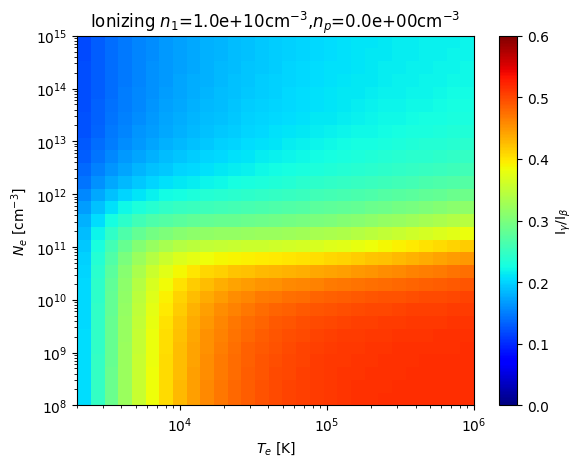

In [19]:
TeTe, NeNe=np.meshgrid(Te_list, Ne_list)

nl = 2  # lower level n,  nl=2 for Balmer series
idxI = atom.Line['idxI']
jj = np.where(idxI == nl)
Aji = atom.Line['AJI'][jj]
idxJ = atom.Line['idxJ'][jj]
eps = Cst.h_*Cst.c_/atom.Line['w0'][jj]

n_h=4#H-beta
Nj0 = Io_pops_te_ne[:,:,n_h]
I_Hy=Aji[n_h-3]*Nj0*eps[n_h-3]

n_h=5#H-gamma
Nj0 = Io_pops_te_ne[:,:,n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]

pl= I_Hx/I_Hy

vmin, vmax=0,0.6 #0.2, 0.6
im=plt.pcolormesh(TeTe, NeNe, pl.T ,cmap='jet', vmin=vmin, vmax=vmax)
plt.colorbar(im, label=r'I$_{\gamma}$/I$_{\beta}$')
#plt.contour(TeTe, NeNe, np.log10(pl.T), [0] )

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$T_e$ [K]')
plt.ylabel(r'$N_e$ [cm$^{-3}$]')

plt.title('Ionizing '+"$n_1$={0:3.1e}".format(n1)+ "cm$^{-3}$,"+ "$n_p$={0:3.1e}".format(n_proton)+ "cm$^{-3}$")

Text(0.5, 1.0, 'Ionizing $n_1$=0.0e+00cm$^{-3}$,$n_p$=1.0e+10cm$^{-3}$')

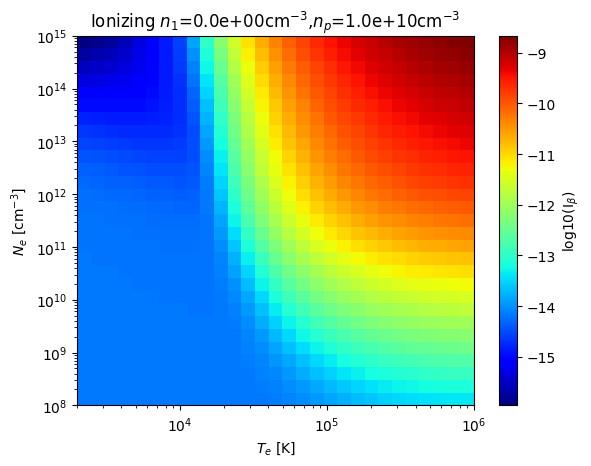

In [100]:
TeTe, NeNe=np.meshgrid(Te_list, Ne_list)

nl = 2  # lower level n,  nl=2 for Balmer series
idxI = atom.Line['idxI']
jj = np.where(idxI == nl)
Aji = atom.Line['AJI'][jj]
idxJ = atom.Line['idxJ'][jj]
eps = Cst.h_*Cst.c_/atom.Line['w0'][jj]

n_h=4#H-beta
Nj0 = Io_pops_te_ne[:,:,n_h]
I_Hy=Aji[n_h-3]*Nj0*eps[n_h-3]

n_h=5#H-gamma
Nj0 = Io_pops_te_ne[:,:,n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]

pl= np.log10(I_Hy)

im=plt.pcolormesh(TeTe, NeNe, pl.T ,cmap='jet')
plt.colorbar(im, label=r'log10(I$_{\beta}$)')
#plt.contour(TeTe, NeNe, np.log10(pl.T), [0] )

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$T_e$ [K]')
plt.ylabel(r'$N_e$ [cm$^{-3}$]')

plt.title('Ionizing '+"$n_1$={0:3.1e}".format(n1)+ "cm$^{-3}$,"+ "$n_p$={0:3.1e}".format(n_proton)+ "cm$^{-3}$")

# Recombining

In [20]:
#Fixed parameters
Nh= 1.E11 #arbitary if we use normalized pop.
Te = 1e4#10000.
#Ne = 1.E10#1.E10
Vd = 0.
Vt = 5e5 #cm/s 
Jfactor = 0.0#1.   # intensity of solar radiation
#Nes = [1E8, 1E9, 1E10, 1E11, 1E12]
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  

#slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
N_ne= 30
N_te= 30
N_level = 21
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

Ne_list = 10**(np.linspace(8, 15, N_ne)) # density list
Te_list = 10**(np.linspace(np.log10(2e3), 6, N_te)) # temperature list
Re_pops_te_ne = np.zeros([N_te, N_ne, N_level]) # SE pop. list
n1 = 0.E0  ; n_proton = 1.E10  # cm-3,  recombining plasma

for i in range(N_te):
    for j in range(N_ne):
        slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne_list[j], Te=Te_list[i], Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
        SE0, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton) 
    
        Re_pops_te_ne[i,j,:]=SE0.n_SE.copy()
        print(i, j)



0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
0 28
0 29
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
1 18
1 19
1 20
1 21
1 22
1 23
1 24
1 25
1 26
1 27
1 28
1 29
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
2 18
2 19
2 20
2 21
2 22
2 23
2 24
2 25
2 26
2 27
2 28
2 29
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
3 18
3 19
3 20
3 21
3 22
3 23
3 24
3 25
3 26
3 27
3 28
3 29
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
4 10
4 11
4 12
4 13
4 14
4 15
4 16
4 17
4 18
4 19
4 20
4 21
4 22
4 23
4 24
4 25
4 26
4 27
4 28
4 29
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11
5 12
5 13
5 14
5 15
5 16
5 17
5 18
5 19
5 20
5 21
5 22
5 23
5 24
5 25
5 26
5 27
5 28
5 29
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
6 9
6 10
6 11
6 12
6 13
6 14
6 15
6 16
6 17
6 18
6 19
6 20
6 21
6 22
6 23
6 24
6 25
6 26
6 27
6 28
6 29
7 0
7 1
7 2
7 3
7 4


Text(0.5, 1.0, 'recombining $n_1$=0.0e+00cm$^{-3}$,$n_p$=1.0e+10cm$^{-3}$')

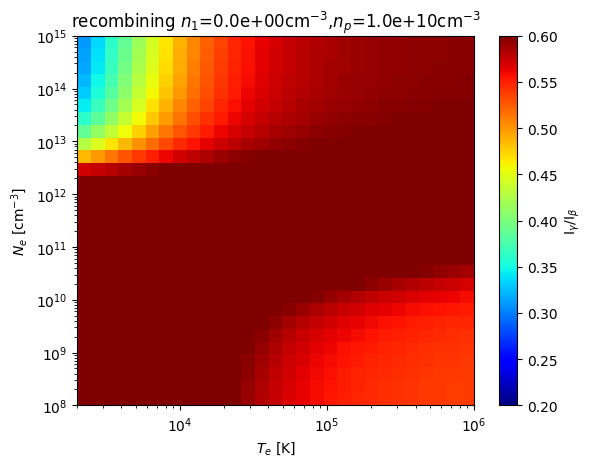

In [22]:
TeTe, NeNe=np.meshgrid(Te_list, Ne_list)
n1 = 0.E0  ; n_proton = 1.E10  # cm-3,  recombining plasma

nl = 2  # lower level n,  nl=2 for Balmer series
idxI = atom.Line['idxI']
jj = np.where(idxI == nl)
Aji = atom.Line['AJI'][jj]
idxJ = atom.Line['idxJ'][jj]
eps = Cst.h_*Cst.c_/atom.Line['w0'][jj]

n_h=4#H-beta
Nj0 = Re_pops_te_ne[:,:,n_h]
I_Hy=Aji[n_h-3]*Nj0*eps[n_h-3]

n_h=5#H-gamma
Nj0 = Re_pops_te_ne[:,:,n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]

pl= I_Hx/I_Hy

im=plt.pcolormesh(TeTe, NeNe, pl.T ,cmap='jet', vmin=0.2, vmax=0.6)
#im=plt.pcolormesh(TeTe, NeNe, pl.T ,cmap='jet')

plt.colorbar(im, label=r'I$_{\gamma}$/I$_{\beta}$')
#plt.contour(TeTe, NeNe, np.log10(pl.T), [0] )

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$T_e$ [K]')
plt.ylabel(r'$N_e$ [cm$^{-3}$]')

plt.title('recombining '+"$n_1$={0:3.1e}".format(n1)+ "cm$^{-3}$,"+ "$n_p$={0:3.1e}".format(n_proton)+ "cm$^{-3}$")

Text(0.5, 1.0, 'recombining $n_1$=0.0e+00cm$^{-3}$,$n_p$=1.0e+10cm$^{-3}$')

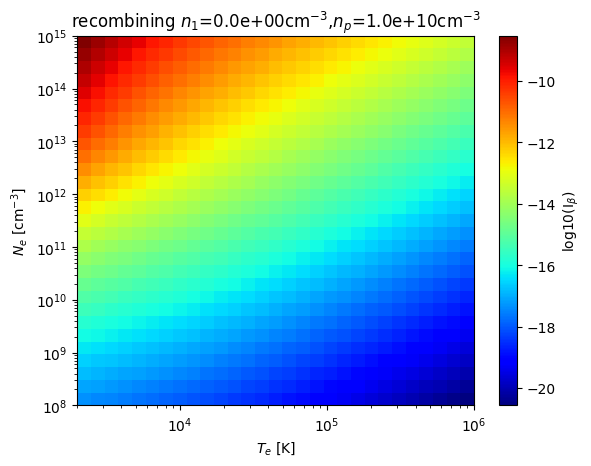

In [101]:
TeTe, NeNe=np.meshgrid(Te_list, Ne_list)
n1 = 0.E0  ; n_proton = 1.E10  # cm-3,  recombining plasma

nl = 2  # lower level n,  nl=2 for Balmer series
idxI = atom.Line['idxI']
jj = np.where(idxI == nl)
Aji = atom.Line['AJI'][jj]
idxJ = atom.Line['idxJ'][jj]
eps = Cst.h_*Cst.c_/atom.Line['w0'][jj]

n_h=4#H-beta
Nj0 = Re_pops_te_ne[:,:,n_h]
I_Hy=Aji[n_h-3]*Nj0*eps[n_h-3]

n_h=5#H-gamma
Nj0 = Re_pops_te_ne[:,:,n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]

pl= np.log10(I_Hy)

im=plt.pcolormesh(TeTe, NeNe, pl.T ,cmap='jet')
plt.colorbar(im, label=r'log10(I$_{\beta}$)')
#plt.contour(TeTe, NeNe, np.log10(pl.T), [0] )

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$T_e$ [K]')
plt.ylabel(r'$N_e$ [cm$^{-3}$]')

plt.title('recombining '+"$n_1$={0:3.1e}".format(n1)+ "cm$^{-3}$,"+ "$n_p$={0:3.1e}".format(n_proton)+ "cm$^{-3}$")

In [82]:
Te_list[5]

10263.258319796638

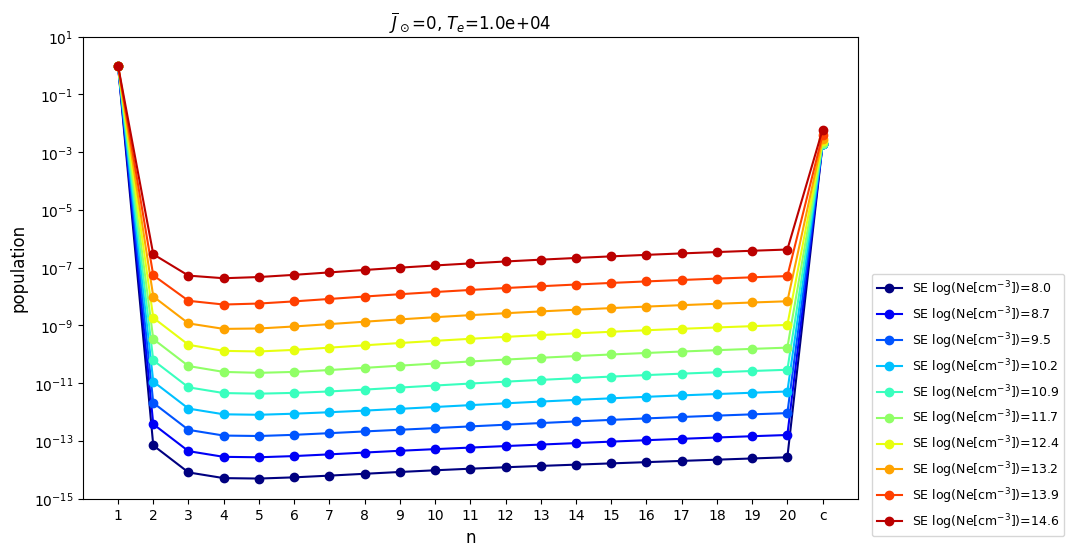

In [85]:
import matplotlib as mpl
fig, ax = plt.subplots(1,1, figsize=(10,6), dpi=100)

colormap= plt.get_cmap('jet')
    #norm=matplotlib.colors.Normalize(vmin=np.min(rho_t[n,:]),vmax=np.max(rho_t[n,:]))
norm=mpl.colors.Normalize(vmin=np.min(np.log10(Ne_list)),vmax=np.max(np.log10(Ne_list)))
c=colormap(norm(np.log10(Ne_list)))

for i in range(int(len(Ne_list)/2)):
    I=i*2
    ax.plot(n, SE_pops_te_ne[5,I,:],'-o', label=r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])), c=c[I])#, color=colors[j])
ax.set_xticks(n)
ax.set_xticklabels([i for i in n[:-1]]+['c'], fontsize=10)
ax.set_xlabel('n', fontsize=12)
ax.set_ylabel("population", fontsize=12)
ax.set_yscale("log")

ax.set_ylim(1e-15, 10)

title = r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e}"
ax.set_title(title)
ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)

#ax.legend()
plt.show()

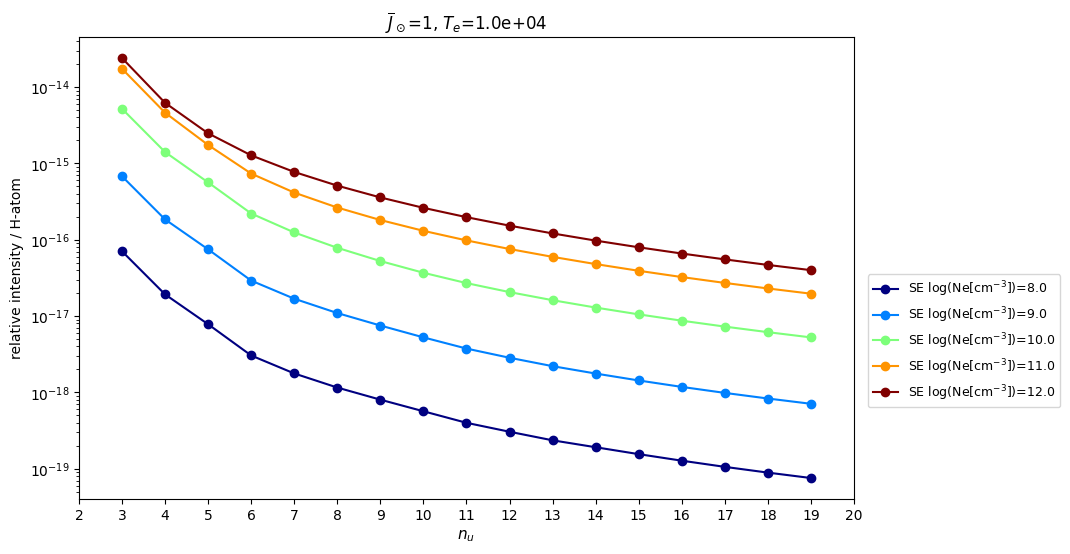

In [90]:
nl = 2  # lower level n,  nl=2 for Balmer series
idxI = atom.Line['idxI']
jj = np.where(idxI == nl)
Aji = atom.Line['AJI'][jj]
idxJ = atom.Line['idxJ'][jj]
eps = Cst.h_*Cst.c_/atom.Line['w0'][jj]
n_lev = np.size(atom.Level)-1
n = np.arange(nl,n_lev+1,dtype='int')  # n-array for levels
nmax = 20

fig, ax = plt.subplots(1,1, figsize=(10,6), dpi=100)



colormap= plt.get_cmap('jet')
    #norm=matplotlib.colors.Normalize(vmin=np.min(rho_t[n,:]),vmax=np.max(rho_t[n,:]))
norm=mpl.colors.Normalize(vmin=np.min(np.log10(Ne_list)),vmax=np.max(np.log10(Ne_list)))
c=colormap(norm(np.log10(Ne_list)))

for i in range(int(len(Ne_list)/2)+1):
    I=i*2
    #ax.plot(n, SE_pops_temp[I,:],'-o', label='SE log(Te[K])={:.1f}'.format(np.log10(Te_list[I])), c=c[I])#, color=colors[j])
    Nj0 = SE_pops_dens[I, idxJ]#SE0.n_SE[idxJ]
    ax.plot(idxJ,Aji*Nj0*eps,'-o', label=r'SE log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])), c=c[I])
    #ax.plot(idxJ,Nj0*eps,'-o', label='SE log(Te[K])={:.1f}'.format(np.log10(Te_list[I])), c=c[I])

ax.set_xlim(nl,nmax)
ax.set_xticks(np.arange(nl,nmax+1))
ax.set_xlabel('$n_u$', fontsize=11)
ax.set_yscale('log')
ax.set_ylabel('relative intensity / H-atom')
# title = r"$n_l$="+f"{nl:3.0f}: "
# title = title+r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$=" +f"{Te:5.0f}K, $n_e$="+ \
#     f"{Ne:3.1e}"
# plt.title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)
#ax.legend()

title = r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e}"
ax.set_title(title)

plt.show()


In [139]:
eps.

(17,)

0.2724026306487411
0.11056501122299127
0.04309277190005201
0.02506648366567808
0.01637716423917771
0.011366205951651309


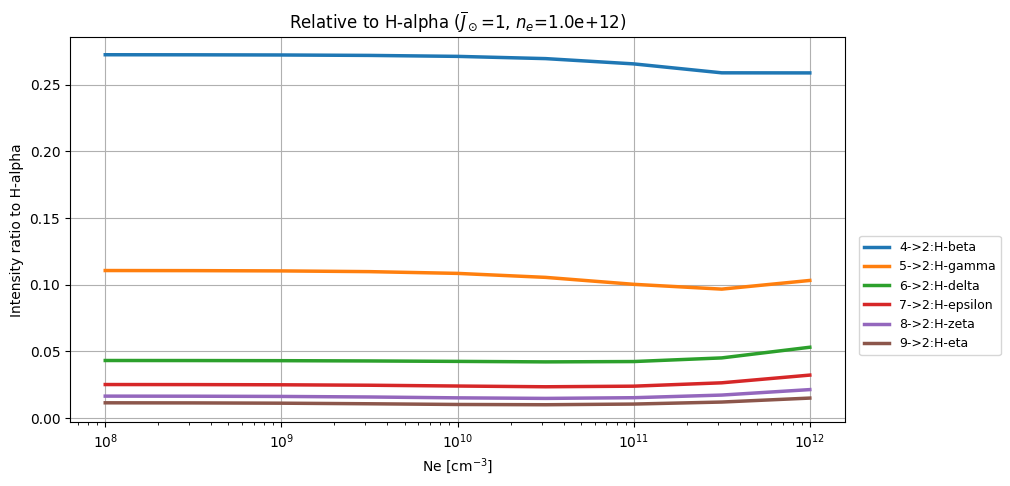

In [34]:
fig,ax=plt.subplots(1,1,figsize=(10, 5))

n_h=3
Nj0 = SE_pops_dens[:, n_h]
I_Ha=Aji[n_h-3]*Nj0*eps[n_h-3]
rel='H-alpha'

terms=['3->2:H-alpha', '4->2:H-beta', '5->2:H-gamma', '6->2:H-delta', '7->2:H-epsilon', '8->2:H-zeta',
       '9->2:H-eta', '10->2:H-theta', '11->2:H-iota']

for n_h in range(4,10):
    #n_h=4
    Nj0 = SE_pops_dens[:, n_h]
    I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]
    
    ax.plot(Ne_list, I_Hx/I_Ha, label='{}'.format(terms[n_h-3]), lw=2.5)
    print(I_Hx[0]/I_Ha[0])
    
ax.set_xlabel(r'Ne [cm$^{-3}$]')
ax.set_ylabel('Intensity ratio to ' + rel)
ax.set_xscale('log')


title = "Relative to "+ rel +r" ($\overline{J}_\odot$="+f"{Jfactor:1.0f}, $n_e$="+ \
    f"{Ne:3.1e})"
ax.set_title(title)

ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)

#Te range
#ax.set_xlim(0.9e4, 1.1e6)
#ax.set_xlim(0.9e4, 3e4)

ax.grid()


0.4058881919006249
0.15819513856171036
0.09201997648106752
0.06012116770008658
0.04172575692305943


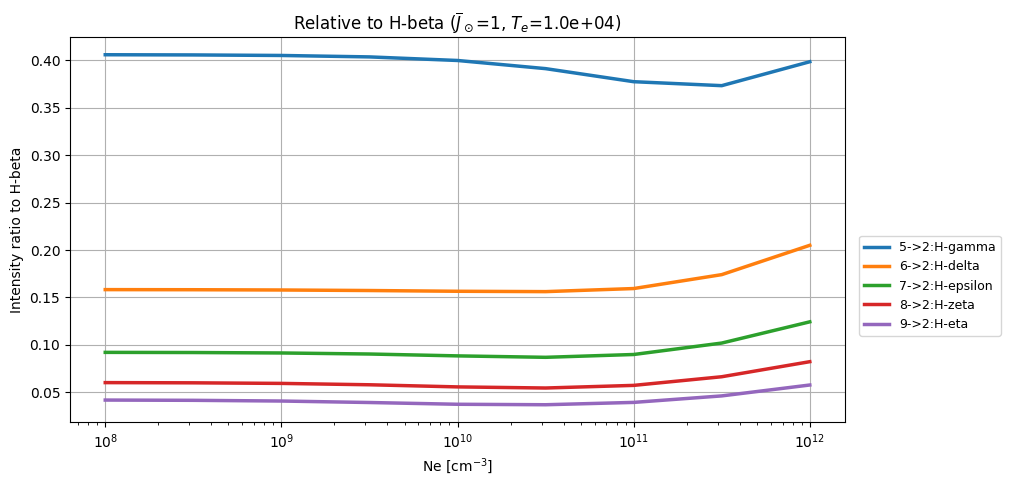

In [60]:
fig,ax=plt.subplots(1,1,figsize=(10, 5))

n_h=4
Nj0 = SE_pops_dens[:, n_h]
I_Hy=Aji[n_h-3]*Nj0*eps[n_h-3]
rel='H-beta'

terms=['3->2:H-alpha', '4->2:H-beta', '5->2:H-gamma', '6->2:H-delta', '7->2:H-epsilon', '8->2:H-zeta',
       '9->2:H-eta', '10->2:H-theta', '11->2:H-iota']

for n_h in range(5,10):
    #n_h=4
    Nj0 = SE_pops_dens[:, n_h]
    I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]
    
    ax.plot(Ne_list, I_Hx/I_Hy, label='{}'.format(terms[n_h-3]), lw=2.5)
    print(I_Hx[0]/I_Hy[0])
    
ax.set_xlabel(r'Ne [cm$^{-3}$]')
ax.set_ylabel('Intensity ratio to ' + rel)
ax.set_xscale('log')


title = "Relative to "+ rel +r" ($\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e})"
ax.set_title(title)

ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)

#Te range
#ax.set_xlim(0.9e4, 1.1e6)
#ax.set_xlim(0.9e4, 3e4)

ax.grid()


In [180]:
0.108/0.27

0.39999999999999997

Text(0.5, 1.0, '$\\overline{J}_\\odot$=1, $T_e$=10000K, $n_e$=1.0e+10, $n_1$=0.0e+00, $n_p$=1.0e+10')

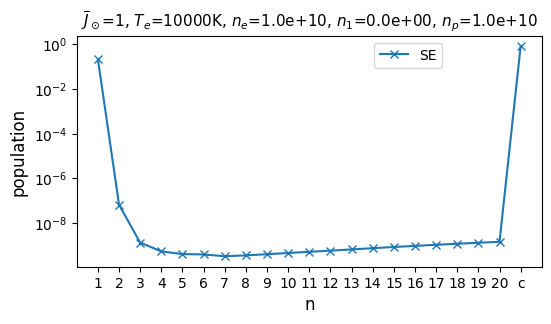

In [51]:
fig, ax = plt.subplots(1,1, figsize=(6,3), dpi=100)

SE0, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
ax.plot(n,SE0.n_SE,'-x', label='SE')#, color=colors[j])

ax.set_yscale("log")
ax.set_xticks(n)
ax.set_xticklabels([i for i in n[:-1]]+['c'], fontsize=10)
ax.set_xlabel('n', fontsize=12)
ax.set_ylabel("population", fontsize=12)
title = r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$=" +f"{Te:5.0f}K, $n_e$="+ \
    f"{Ne:3.1e}, $n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"

ax.legend(bbox_to_anchor=(0.8,1.0),fontsize=10,ncol=1)

plt.title(title,fontsize=11)

# The case of ionizing plasma

In [86]:
def calc_NIE(atom, slab, wMesh, solar_spec, n1, n_proton):
    ## use rate_only=True to acquire the transition matrix (R matrix and C matrix) without solving linear equation
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, solar_spec, None, rate_only=True)  #  level populations etc.
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rate.Rmat, Rate.Cmat)
    # print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    # print(f"Amat has shape: {A.shape}")
    b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    ## solve Ax=b
    nArr = np.linalg.solve(A, b) ## population density for levels n=2,3,...,N
    #print(f"nArr shape: {nArr.shape}")
    pop = np.zeros(len(nArr)+2)
    pop[0] = n1 ; pop[1:-1] = nArr ; pop[-1] = n_proton
    Nh = pop.sum()
    SE.n_SE = pop/Nh
    SE.Nh = Nh
    SE.Te = slab.Te
    SE.Ne = slab.Ne

    return(SE,Rate)

In [77]:
#Fixed parameters
Nh= 1.E11 #arbitary if we use normalized pop.
Te = 1e4#10000.
#Ne = 1.E10#1.E10
Vd = 0.
Vt = 5e5 #cm/s 
Jfactor = 1.   # intensity of solar radiation
#Nes = [1E8, 1E9, 1E10, 1E11, 1E12]
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  

#slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 

N_ne= 9
N_level = 21
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

Ne_list = 10**(np.linspace(8, 12, N_ne)) # temperature list
Io_pops_dens = np.zeros([N_ne, N_level]) # SE pop. list

n1 = 1.E10  ; n_proton = 0.E0  # cm-3,  ionizing plasma
#SE1, Rate1 = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)

for i in range(N_ne):
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne_list[i], Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE0, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton) 

    Io_pops_dens[i, :]=SE0.n_SE.copy()

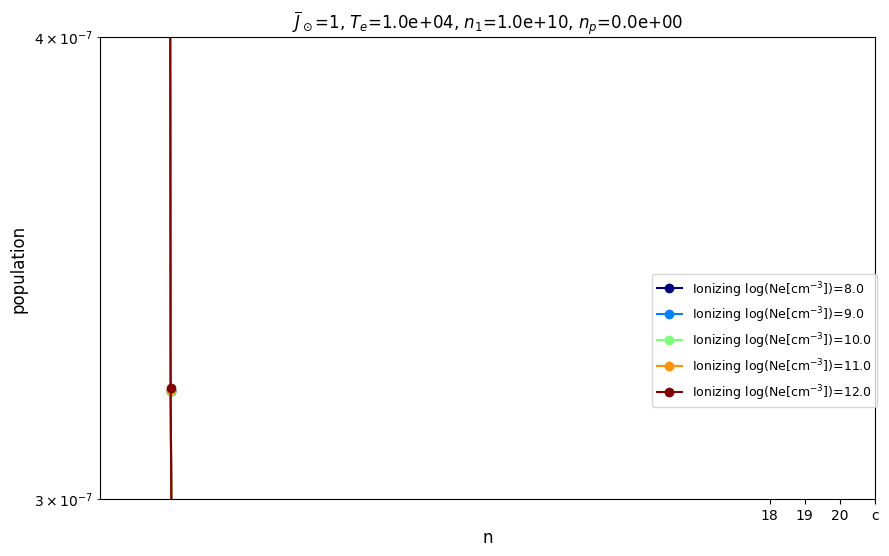

In [82]:
import matplotlib as mpl
fig, ax = plt.subplots(1,1, figsize=(10,6), dpi=100)

colormap= plt.get_cmap('jet')
    #norm=matplotlib.colors.Normalize(vmin=np.min(rho_t[n,:]),vmax=np.max(rho_t[n,:]))
norm=mpl.colors.Normalize(vmin=np.min(np.log10(Ne_list)),vmax=np.max(np.log10(Ne_list)))
c=colormap(norm(np.log10(Ne_list)))

n_lev = np.size(atom.Level)-1
n = np.arange(nl-1,n_lev+2,dtype='int')  # n-array for levels

for i in range(int(len(Ne_list)/2)+1):
    I=i*2
    ax.plot( Io_pops_dens[I,:],'-o', label=r'Ionizing log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])), c=c[I])#, color=colors[j])
    #ax.plot(n, SE_pops_temp[I,:],'-o', label='SE log(Te[K])={:.1f}'.format(np.log10(Te_list[I])), c=c[I])#, color=colors[j])

ax.set_xticks(n)
ax.set_xticklabels([i for i in n[:-1]]+['c'], fontsize=10)
ax.set_xlabel('n', fontsize=12)
ax.set_ylabel("population", fontsize=12)
ax.set_yscale("log")

ax.set_ylim(1e-15, 10)

title = r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e}, $n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"
ax.set_title(title)
ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)

ax.set_ylim(3e-7, 4e-7)
#ax.legend()
plt.show()

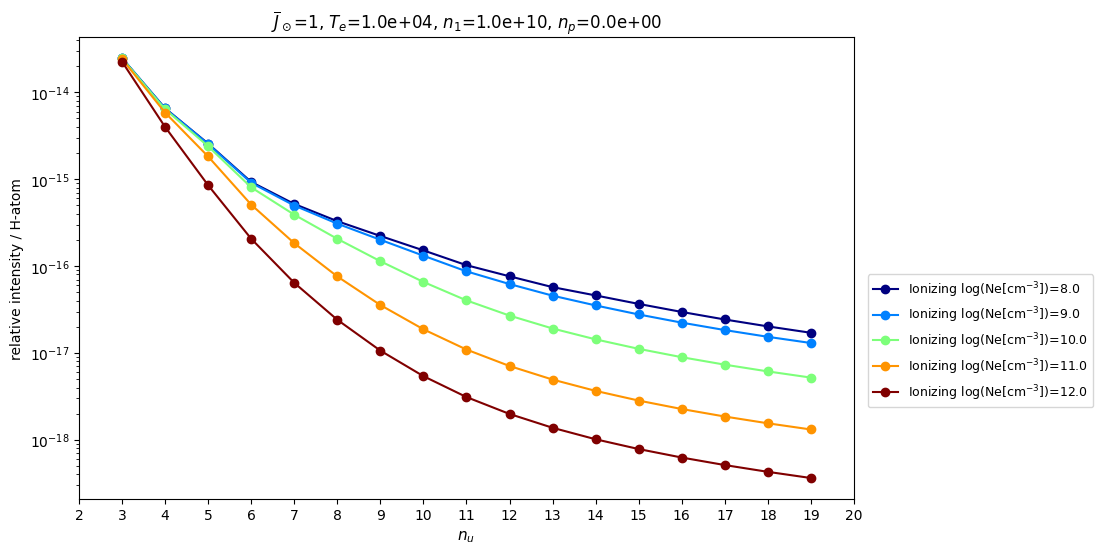

In [101]:
nl = 2  # lower level n,  nl=2 for Balmer series
idxI = atom.Line['idxI']
jj = np.where(idxI == nl)
Aji = atom.Line['AJI'][jj]
idxJ = atom.Line['idxJ'][jj]
eps = Cst.h_*Cst.c_/atom.Line['w0'][jj]
n_lev = np.size(atom.Level)-1
n = np.arange(nl,n_lev+1,dtype='int')  # n-array for levels
nmax = 20

fig, ax = plt.subplots(1,1, figsize=(10,6), dpi=100)



colormap= plt.get_cmap('jet')
    #norm=matplotlib.colors.Normalize(vmin=np.min(rho_t[n,:]),vmax=np.max(rho_t[n,:]))
norm=mpl.colors.Normalize(vmin=np.min(np.log10(Ne_list)),vmax=np.max(np.log10(Ne_list)))
c=colormap(norm(np.log10(Ne_list)))

for i in range(int(len(Ne_list)/2)+1):
    I=i*2
    #ax.plot(n, SE_pops_temp[I,:],'-o', label='SE log(Te[K])={:.1f}'.format(np.log10(Te_list[I])), c=c[I])#, color=colors[j])
    Nj0 = Io_pops_dens[I, idxJ]#SE0.n_SE[idxJ]
    ax.plot(idxJ,Aji*Nj0*eps,'-o', label=r'Ionizing log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])), c=c[I])
    #ax.plot(idxJ,Nj0*eps,'-o', label='SE log(Te[K])={:.1f}'.format(np.log10(Te_list[I])), c=c[I])

ax.set_xlim(nl,nmax)
ax.set_xticks(np.arange(nl,nmax+1))
ax.set_xlabel('$n_u$', fontsize=11)
ax.set_yscale('log')
ax.set_ylabel('relative intensity / H-atom')
# title = r"$n_l$="+f"{nl:3.0f}: "
# title = title+r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$=" +f"{Te:5.0f}K, $n_e$="+ \
#     f"{Ne:3.1e}"
# plt.title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)
#ax.legend()

title = r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e}, $n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"
ax.set_title(title)

plt.show()


0.26404873561895686
0.10350383503839246
0.03747973305740158
0.020912413368474984
0.013253001799989478
0.008958605817834794


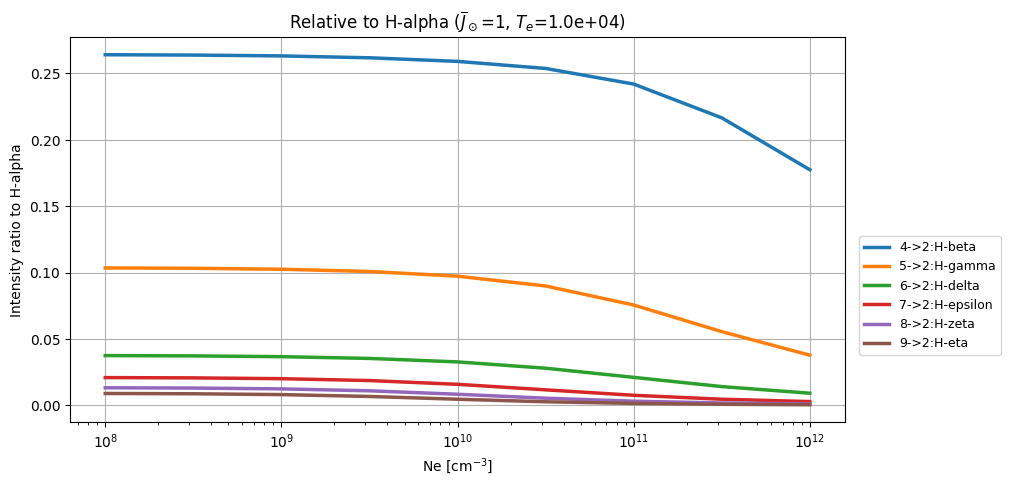

In [102]:
fig,ax=plt.subplots(1,1,figsize=(10, 5))

n_h=3
Nj0 = Io_pops_dens[:, n_h]
I_Ha=Aji[n_h-3]*Nj0*eps[n_h-3]
rel='H-alpha'

terms=['3->2:H-alpha', '4->2:H-beta', '5->2:H-gamma', '6->2:H-delta', '7->2:H-epsilon', '8->2:H-zeta',
       '9->2:H-eta', '10->2:H-theta', '11->2:H-iota']

for n_h in range(4,10):
    #n_h=4
    Nj0 = Io_pops_dens[:, n_h]
    I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]
    
    ax.plot(Ne_list, I_Hx/I_Ha, label='{}'.format(terms[n_h-3]), lw=2.5)
    print(I_Hx[0]/I_Ha[0])
    
ax.set_xlabel(r'Ne [cm$^{-3}$]')
ax.set_ylabel('Intensity ratio to ' + rel)
ax.set_xscale('log')


title = "Relative to "+ rel +r" ($\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e})"
ax.set_title(title)

ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)

#Te range
#ax.set_xlim(0.9e4, 1.1e6)
#ax.set_xlim(0.9e4, 3e4)

ax.grid()


0.39198761848175123
0.14194248258582
0.07919906648844267
0.050191498811471696
0.033927849708633974


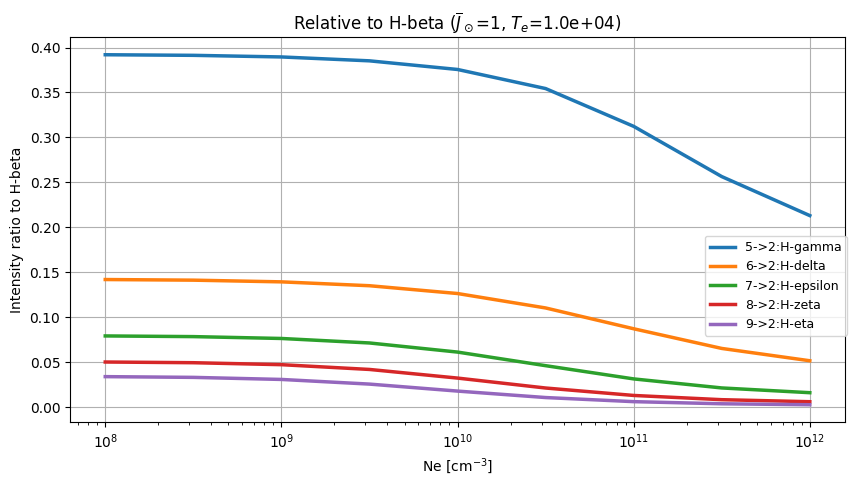

In [103]:
fig,ax=plt.subplots(1,1,figsize=(10, 5))

n_h=4
Nj0 = Io_pops_dens[:, n_h]
I_Hy=Aji[n_h-3]*Nj0*eps[n_h-3]
rel='H-beta'

terms=['3->2:H-alpha', '4->2:H-beta', '5->2:H-gamma', '6->2:H-delta', '7->2:H-epsilon', '8->2:H-zeta',
       '9->2:H-eta', '10->2:H-theta', '11->2:H-iota']

for n_h in range(5,10):
    #n_h=4
    Nj0 = Io_pops_dens[:, n_h]
    I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]
    
    ax.plot(Ne_list, I_Hx/I_Hy, label='{}'.format(terms[n_h-3]), lw=2.5)
    print(I_Hx[0]/I_Hy[0])
    
ax.set_xlabel(r'Ne [cm$^{-3}$]')
ax.set_ylabel('Intensity ratio to ' + rel)
ax.set_xscale('log')


title = "Relative to "+ rel +r" ($\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e})"
ax.set_title(title)

ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)

#Te range
#ax.set_xlim(0.9e4, 1.1e6)
#ax.set_xlim(0.9e4, 3e4)

ax.grid()


# The case of recombining plasma

In [65]:
#Fixed parameters
Nh= 1.E11 #arbitary if we use normalized pop.
Te = 10000.
#Ne = 1.E10#1.E10
Vd = 0.
Vt = 5e5 #cm/s 
Jfactor = 1.   # intensity of solar radiation
#Nes = [1E8, 1E9, 1E10, 1E11, 1E12]
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  

#slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 

N_ne= 9
N_level = 21
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

Ne_list = 10**(np.linspace(8, 12, N_ne)) # temperature list
Re_pops_dens = np.zeros([N_ne, N_level]) # SE pop. list

n1 = 0.E0  ; n_proton = 1.E10  # cm-3,  ionizing plasma
#SE1, Rate1 = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)

for i in range(N_ne):
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne_list[i], Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE0, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton) 

    Re_pops_dens[i, :]=SE0.n_SE.copy()

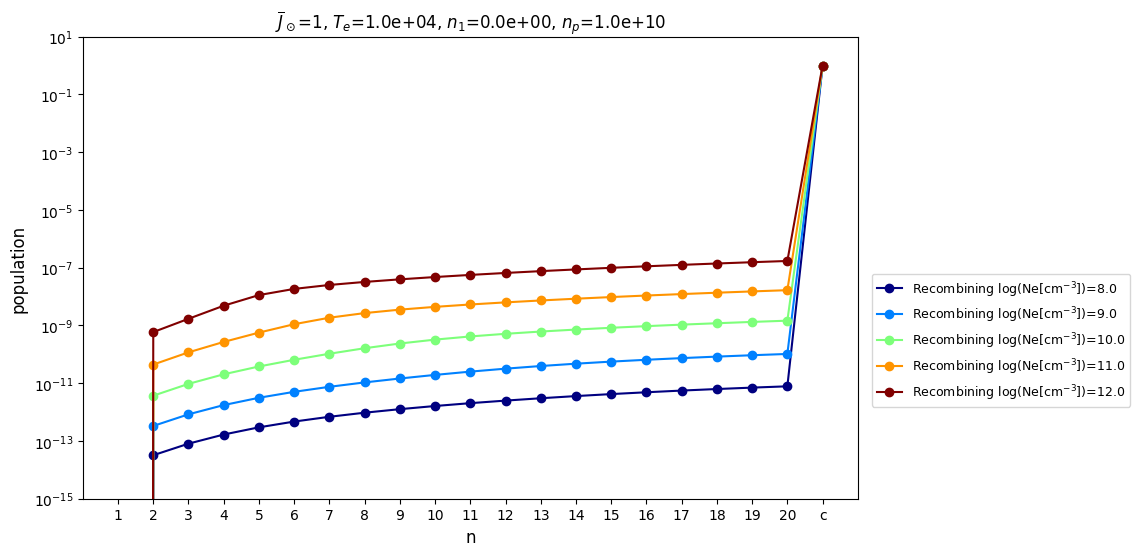

In [66]:
import matplotlib as mpl
fig, ax = plt.subplots(1,1, figsize=(10,6), dpi=100)

colormap= plt.get_cmap('jet')
    #norm=matplotlib.colors.Normalize(vmin=np.min(rho_t[n,:]),vmax=np.max(rho_t[n,:]))
norm=mpl.colors.Normalize(vmin=np.min(np.log10(Ne_list)),vmax=np.max(np.log10(Ne_list)))
c=colormap(norm(np.log10(Ne_list)))

n_lev = np.size(atom.Level)-1
n = np.arange(nl-1,n_lev+2,dtype='int')  # n-array for levels

for i in range(int(len(Ne_list)/2)+1):
    I=i*2
    ax.plot(n, Re_pops_dens[I,:],'-o', label=r'Recombining log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])), c=c[I])#, color=colors[j])
    #ax.plot(n, SE_pops_temp[I,:],'-o', label='SE log(Te[K])={:.1f}'.format(np.log10(Te_list[I])), c=c[I])#, color=colors[j])

ax.set_xticks(n)
ax.set_xticklabels([i for i in n[:-1]]+['c'], fontsize=10)
ax.set_xlabel('n', fontsize=12)
ax.set_ylabel("population", fontsize=12)
ax.set_yscale("log")

ax.set_ylim(1e-15, 10)

title = r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e}, $n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"
ax.set_title(title)
ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)

#ax.legend()
plt.show()

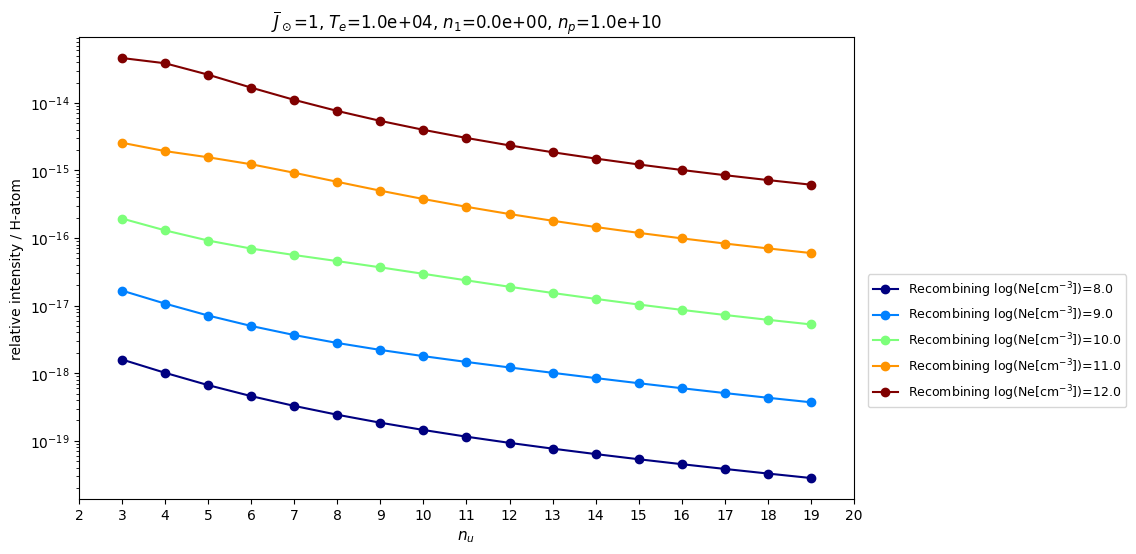

In [68]:
nl = 2  # lower level n,  nl=2 for Balmer series
idxI = atom.Line['idxI']
jj = np.where(idxI == nl)
Aji = atom.Line['AJI'][jj]
idxJ = atom.Line['idxJ'][jj]
eps = Cst.h_*Cst.c_/atom.Line['w0'][jj]
n_lev = np.size(atom.Level)-1
n = np.arange(nl,n_lev+1,dtype='int')  # n-array for levels
nmax = 20

fig, ax = plt.subplots(1,1, figsize=(10,6), dpi=100)



colormap= plt.get_cmap('jet')
    #norm=matplotlib.colors.Normalize(vmin=np.min(rho_t[n,:]),vmax=np.max(rho_t[n,:]))
norm=mpl.colors.Normalize(vmin=np.min(np.log10(Ne_list)),vmax=np.max(np.log10(Ne_list)))
c=colormap(norm(np.log10(Ne_list)))

for i in range(int(len(Ne_list)/2)+1):
    I=i*2
    #ax.plot(n, SE_pops_temp[I,:],'-o', label='SE log(Te[K])={:.1f}'.format(np.log10(Te_list[I])), c=c[I])#, color=colors[j])
    Nj0 = Re_pops_dens[I, idxJ]#SE0.n_SE[idxJ]
    ax.plot(idxJ,Aji*Nj0*eps,'-o', label=r'Recombining log(Ne[cm$^{-3}$])='+'{:.1f}'.format(np.log10(Ne_list[I])), c=c[I])
    #ax.plot(idxJ,Nj0*eps,'-o', label='SE log(Te[K])={:.1f}'.format(np.log10(Te_list[I])), c=c[I])

ax.set_xlim(nl,nmax)
ax.set_xticks(np.arange(nl,nmax+1))
ax.set_xlabel('$n_u$', fontsize=11)
ax.set_yscale('log')
ax.set_ylabel('relative intensity / H-atom')
# title = r"$n_l$="+f"{nl:3.0f}: "
# title = title+r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$=" +f"{Te:5.0f}K, $n_e$="+ \
#     f"{Ne:3.1e}"
# plt.title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)
#ax.legend()

title = r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e}, $n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"
ax.set_title(title)

plt.show()


0.6357124158184929
0.41765462553171845
0.28720308556844487
0.20572644909217797
0.15224657372665318
0.11607241596187233


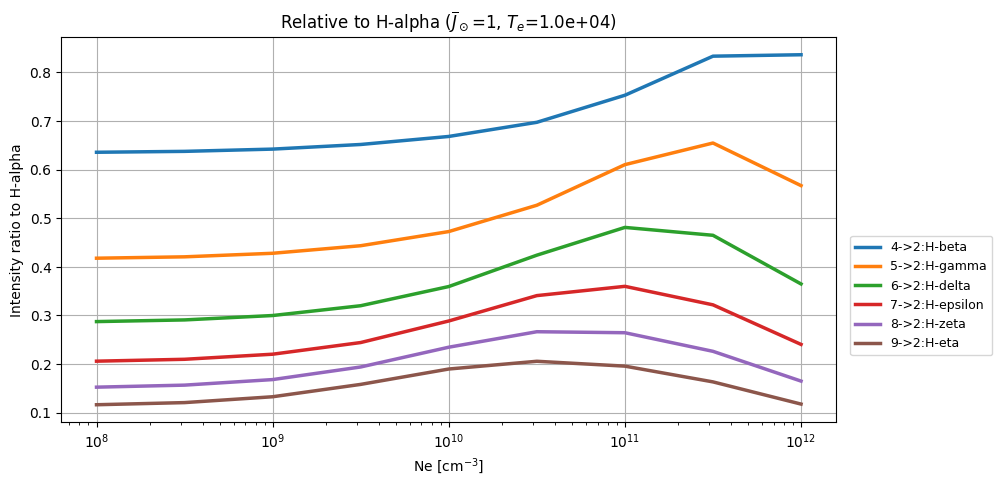

In [69]:
fig,ax=plt.subplots(1,1,figsize=(10, 5))

n_h=3
Nj0 = Re_pops_dens[:, n_h]
I_Ha=Aji[n_h-3]*Nj0*eps[n_h-3]
rel='H-alpha'

terms=['3->2:H-alpha', '4->2:H-beta', '5->2:H-gamma', '6->2:H-delta', '7->2:H-epsilon', '8->2:H-zeta',
       '9->2:H-eta', '10->2:H-theta', '11->2:H-iota']

for n_h in range(4,10):
    #n_h=4
    Nj0 = Re_pops_dens[:, n_h]
    I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]
    
    ax.plot(Ne_list, I_Hx/I_Ha, label='{}'.format(terms[n_h-3]), lw=2.5)
    print(I_Hx[0]/I_Ha[0])
    
ax.set_xlabel(r'Ne [cm$^{-3}$]')
ax.set_ylabel('Intensity ratio to ' + rel)
ax.set_xscale('log')


title = "Relative to "+ rel +r" ($\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e})"
ax.set_title(title)

ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)

#Te range
#ax.set_xlim(0.9e4, 1.1e6)
#ax.set_xlim(0.9e4, 3e4)

ax.grid()


0.6569867366739713
0.4517814634761615
0.3236155909072515
0.23948969681618149
0.18258635992255504


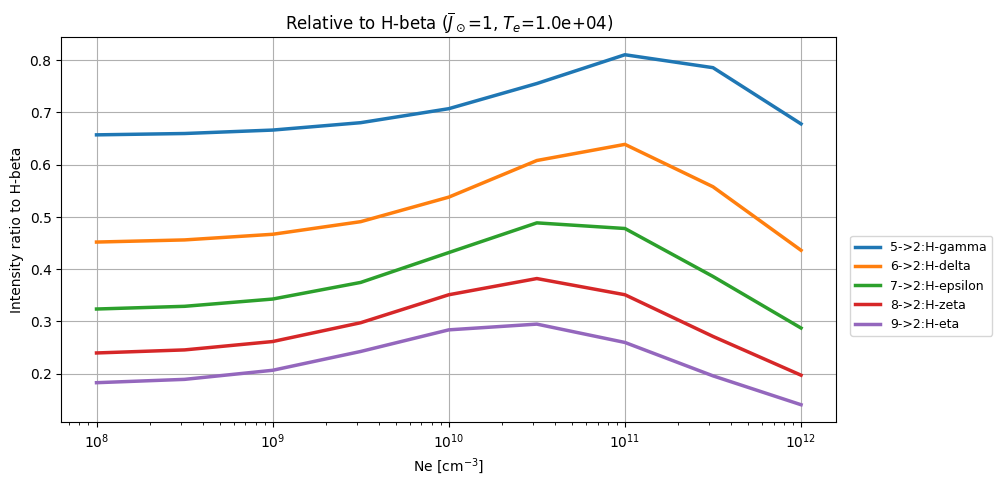

In [70]:
fig,ax=plt.subplots(1,1,figsize=(10, 5))

n_h=4
Nj0 = Re_pops_dens[:, n_h]
I_Hy=Aji[n_h-3]*Nj0*eps[n_h-3]
rel='H-beta'

terms=['3->2:H-alpha', '4->2:H-beta', '5->2:H-gamma', '6->2:H-delta', '7->2:H-epsilon', '8->2:H-zeta',
       '9->2:H-eta', '10->2:H-theta', '11->2:H-iota']

for n_h in range(5,10):
    #n_h=4
    Nj0 = Re_pops_dens[:, n_h]
    I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]
    
    ax.plot(Ne_list, I_Hx/I_Hy, label='{}'.format(terms[n_h-3]), lw=2.5)
    print(I_Hx[0]/I_Hy[0])
    
ax.set_xlabel(r'Ne [cm$^{-3}$]')
ax.set_ylabel('Intensity ratio to ' + rel)
ax.set_xscale('log')


title = "Relative to "+ rel +r" ($\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e})"
ax.set_title(title)

ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)

#Te range
#ax.set_xlim(0.9e4, 1.1e6)
#ax.set_xlim(0.9e4, 3e4)

ax.grid()


# Comparison for three cases

Text(0, 0.5, 'Intensity ratio to H-beta')

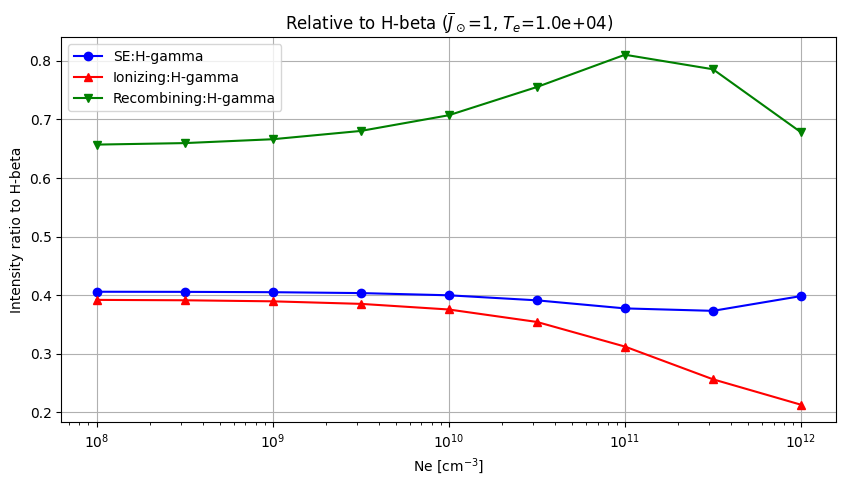

In [73]:
fig,ax=plt.subplots(1,1, figsize=(10,5))

#relative to H-beta
rel='H-beta'
n_h=4

Nj0 = SE_pops_dens[:, n_h]
I_Hy_se=Aji[n_h-3]*Nj0*eps[n_h-3]

Nj0 = Io_pops_dens[:, n_h]
I_Hy_io=Aji[n_h-3]*Nj0*eps[n_h-3]

Nj0 = Re_pops_dens[:, n_h]
I_Hy_re=Aji[n_h-3]*Nj0*eps[n_h-3]

#SE
n_h=5
Nj0 = SE_pops_dens[:, n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]   
ax.plot(Ne_list, I_Hx/I_Hy_se,  '-o', lw=1.5, c='Blue', label='SE:H-gamma')

#Ionizing
n_h=5
Nj0 = Io_pops_dens[:, n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]   
ax.plot(Ne_list, I_Hx/I_Hy_io,  '-^', lw=1.5, c='Red', label='Ionizing:H-gamma')

#Recombining
n_h=5
Nj0 = Re_pops_dens[:, n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]   
ax.plot(Ne_list, I_Hx/I_Hy_re,  '-v', lw=1.5, c='green', label='Recombining:H-gamma')

ax.legend()

ax.set_xscale('log')
ax.grid()


title = "Relative to "+ rel +r" ($\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e})"
ax.set_title(title)
ax.set_xlabel(r'Ne [cm$^{-3}$]')
ax.set_ylabel('Intensity ratio to ' + rel)

#ax.set_ylim(0.3,0.8)

Text(0, 0.5, 'Intensity ratio to H-beta')

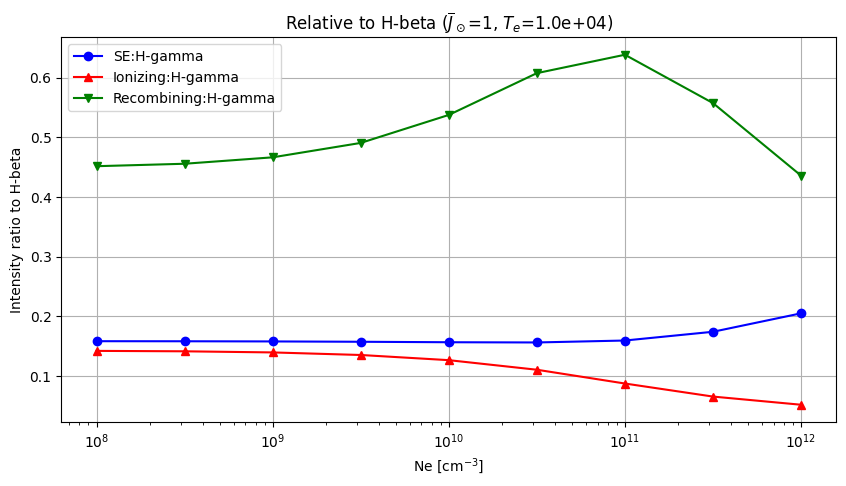

In [75]:
fig,ax=plt.subplots(1,1, figsize=(10,5))

#relative to H-beta
rel='H-beta'
n_h=4

Nj0 = SE_pops_dens[:, n_h]
I_Hy_se=Aji[n_h-3]*Nj0*eps[n_h-3]

Nj0 = Io_pops_dens[:, n_h]
I_Hy_io=Aji[n_h-3]*Nj0*eps[n_h-3]

Nj0 = Re_pops_dens[:, n_h]
I_Hy_re=Aji[n_h-3]*Nj0*eps[n_h-3]

#SE
n_h=6
Nj0 = SE_pops_dens[:, n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]   
ax.plot(Ne_list, I_Hx/I_Hy_se,  '-o', lw=1.5, c='Blue', label='SE:H-gamma')

#Ionizing
Nj0 = Io_pops_dens[:, n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]   
ax.plot(Ne_list, I_Hx/I_Hy_io,  '-^', lw=1.5, c='Red', label='Ionizing:H-gamma')

#Recombining
Nj0 = Re_pops_dens[:, n_h]
I_Hx=Aji[n_h-3]*Nj0*eps[n_h-3]   
ax.plot(Ne_list, I_Hx/I_Hy_re,  '-v', lw=1.5, c='green', label='Recombining:H-gamma')

ax.legend()

ax.set_xscale('log')
ax.grid()


title = "Relative to "+ rel +r" ($\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$="+ \
    f"{Te:3.1e})"
ax.set_title(title)
ax.set_xlabel(r'Ne [cm$^{-3}$]')
ax.set_ylabel('Intensity ratio to ' + rel)

#ax.set_ylim(0.3,0.8)

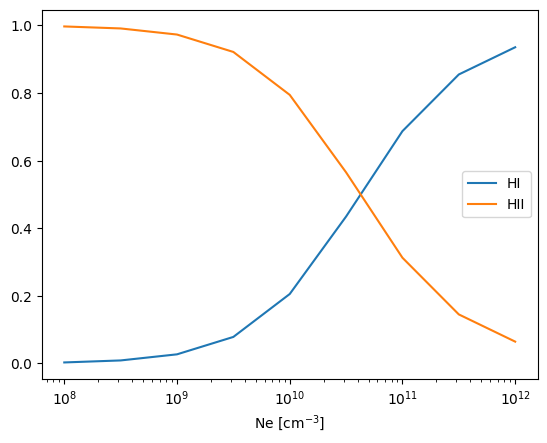

In [85]:
plt.plot(Ne_list, np.sum(SE_pops_dens[:,0:-1], axis=1), label='HI')
plt.plot(Ne_list, SE_pops_dens[:,-1], label='HII')
plt.xlabel(r'Ne [cm$^{-3}$]')
plt.xscale('log')
plt.legend()

In [190]:
Io_pops_temp.shape, n.shape

((21, 21), (19,))

In [195]:
n_lev = np.size(atom.Level)-1
n = np.arange(nl,n_lev+1,dtype='int')  # n-array for levels


## Level population in ionization non-equiliblium

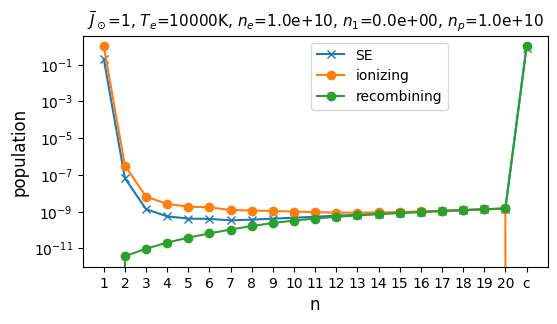

In [185]:
# calculate level population in Non Ionization Equil.
def calc_NIE(atom, slab, wMesh, solar_spec, n1, n_proton):
    ## use rate_only=True to acquire the transition matrix (R matrix and C matrix) without solving linear equation
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, solar_spec, None, rate_only=True)  #  level populations etc.
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rate.Rmat, Rate.Cmat)
    # print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    # print(f"Amat has shape: {A.shape}")
    b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    ## solve Ax=b
    nArr = np.linalg.solve(A, b) ## population density for levels n=2,3,...,N
    #print(f"nArr shape: {nArr.shape}")
    pop = np.zeros(len(nArr)+2)
    pop[0] = n1 ; pop[1:-1] = nArr ; pop[-1] = n_proton
    Nh = pop.sum()
    SE.n_SE = pop/Nh
    SE.Nh = Nh
    SE.Te = slab.Te
    SE.Ne = slab.Ne

    return(SE,Rate)

#----------------------------------------------------------------------
Te = 10000.
Ne = 1.E10
Jfactor = 1.   # intensity of solar radiation
#Nes = [1E8, 1E9, 1E10, 1E11, 1E12]
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  

slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 

fig, ax = plt.subplots(1,1, figsize=(6,3), dpi=100)

SE0, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
ax.plot(n,SE0.n_SE,'-x', label='SE')#, color=colors[j])

n1 = 1.E10  ; n_proton = 0.E0  # cm-3,  ionizing plasma
SE1, Rate1 = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)
ax.plot(n,SE1.n_SE,'-o', label='ionizing')#, color=colors[j])

n1 = 0.E0  ; n_proton = 1.E10  # cm-3,  recombining plasma
SE2, Rate2 = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)
ax.plot(n,SE2.n_SE,'-o', label='recombining')#, color=colors[j])


ax.set_yscale("log")
ax.set_xticks(n)
ax.set_xticklabels([i for i in n[:-1]]+['c'], fontsize=10)
ax.set_xlabel('n', fontsize=12)
ax.set_ylabel("population", fontsize=12)
title = r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$=" +f"{Te:5.0f}K, $n_e$="+ \
    f"{Ne:3.1e}, $n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"

ax.legend(bbox_to_anchor=(0.8,1.0),fontsize=10,ncol=1)

plt.title(title,fontsize=11)

plt.show()

In [187]:
SE1.n_SE.shape, n.shape

((21,), (21,))

### Line intensity:     $I=A_{ji}N_j h\nu$

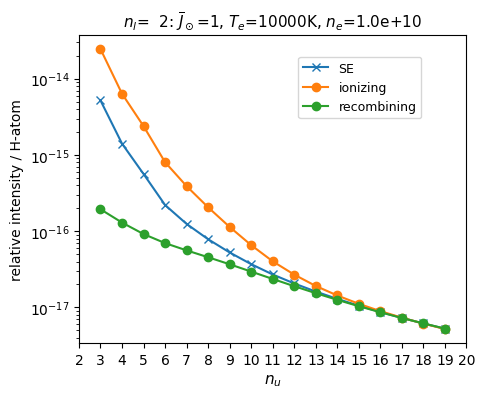

In [15]:
nl = 2  # lower level n,  nl=2 for Balmer series
idxI = atom.Line['idxI']
jj = np.where(idxI == nl)
Aji = atom.Line['AJI'][jj]
idxJ = atom.Line['idxJ'][jj]
eps = Cst.h_*Cst.c_/atom.Line['w0'][jj]
n_lev = np.size(atom.Level)-1
n = np.arange(nl,n_lev+1,dtype='int')  # n-array for levels
nmax = 20

fig, ax = plt.subplots(1,1, figsize=(5,4), dpi=100)

Nj0 = SE0.n_SE[idxJ]
ax.plot(idxJ,Aji*Nj0*eps,'-x',label='SE')
Nj1 = SE1.n_SE[idxJ]
ax.plot(idxJ,Aji*Nj1*eps,'-o',label='ionizing')
Nj2 = SE2.n_SE[idxJ]
ax.plot(idxJ,Aji*Nj2*eps,'-o',label='recombining')

ax.set_xlim(nl,nmax)
ax.set_xticks(np.arange(nl,nmax+1))
ax.set_xlabel('$n_u$', fontsize=11)
ax.set_yscale('log')
ax.set_ylabel('relative intensity / H-atom')
title = r"$n_l$="+f"{nl:3.0f}: "
title = title+r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$=" +f"{Te:5.0f}K, $n_e$="+ \
    f"{Ne:3.1e}"
plt.title(title,fontsize=11)

ax.legend(bbox_to_anchor=(0.9,0.95),fontsize=9,ncol=1)

plt.show()


In [55]:
help_(atom)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Atom
|- Z                       int                                  v: 1
|- Mass                    float                                v: 1.008
|- Abun                    float                                v: 1.0
|- nLevel                  int                                  v: 21
|- nLine                   int                                  v: 190
|- nCont                   int                                  v: 20
|- nTran                   int                                  v: 210
|- nRL                     int                                  v: 0
|- Level                   struct array                         s: (21,)
  |-  erg                  float64                              s: (21,)
  |-  g                

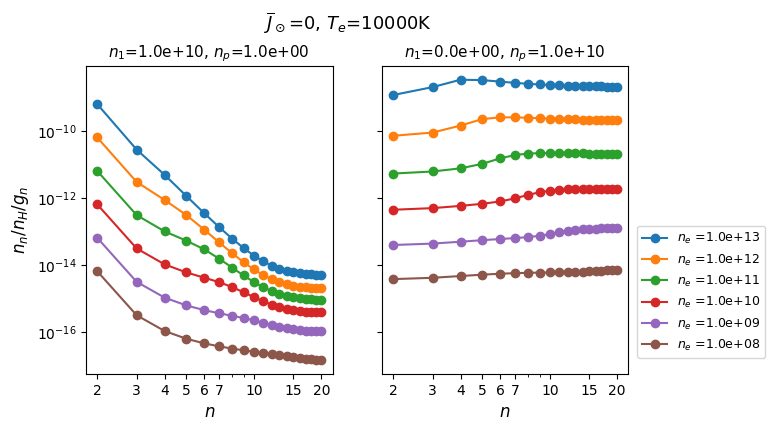

In [18]:
# population of n = 2 - N vs. Ne
import matplotlib.ticker as ticker

Te = 10000
Jfactor = 0.   # intensity of solar radiation
Nes = [1E8, 1E9, 1E10, 1E11, 1E12, 1E13]

Nes.reverse()
n_lev = np.size(atom.Level)-1
n = np.arange(1,n_lev+2,dtype='int')  # n-array including ion
ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  

fig, axs = plt.subplots(1,2, figsize=(7,4), dpi=100, sharey=True)
g = atom.Level['g']

n1 = 1.E10  ; n_proton = 1.E0  # cm-3,  ionizing plasma
ax = axs[0]
for Ne in Nes:
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)
    ax.plot(n[1:-1],SE.n_SE[1:-1]/g[1:-1],'-o', label=r"$n_e$ ="+f"{Ne:3.1e}")#, color=colors[j])

xticks = [2,3,4,5,6,7,10,15,20]
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda xticks,_: f'{xticks:.0f}'))
ax.set_xlabel('$n$', fontsize=12)
ax.set_yscale("log")
ax.set_ylabel("$n_n/n_H/g_n$", fontsize=12)
#title = r"$\overline{J}_\odot$="+f"{Jbar:1.0f}, $T_e$=" +f"{Te:5.0f}K, "+ \
#    " $n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"
title = r"$n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"
ax.set_title(title,fontsize=11)

n1 = 0.E0  ; n_proton = 1.E10  # cm-3,  recombining plasma
ax = axs[1]
for Ne in Nes:
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = calc_NIE(atom, slab, wMesh, ssp, n1, n_proton)
    ax.plot(n[1:-1],SE.n_SE[1:-1]/g[1:-1],'-o', label=r"$n_e$ ="+f"{Ne:3.1e}")#, color=colors[j])

xticks = [2,3,4,5,6,7,10,15,20]
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda xticks,_: f'{xticks:.0f}'))
#ax.set_xticklabels(str(xticks), fontsize=10)
ax.set_xlabel('$n$', fontsize=12)
ax.set_yscale("log")
title = r"$n_1$="+f"{n1:3.1e}, $n_p$="+f"{n_proton:3.1e}"
ax.set_title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,0.5),fontsize=9,ncol=1)

title = r"$\overline{J}_\odot$="+f"{Jfactor:1.0f}, $T_e$=" +f"{Te:5.0f}K"
plt.suptitle(title, fontsize=13, y=1.02)

plt.show()

# Ionizing and recombining components
## Population coefficients   $r_1(n)   \&   r_c(n)$
from Fujimoto 2004

#### $
\frac{d}{dt}
\begin{bmatrix}
n_2\\
\vdots \\
n_N\\
\end{bmatrix}
=n_1\begin{bmatrix}
T_{N1}\\
\vdots \\
T_{21}\\
\end{bmatrix}
+
n_c
\begin{bmatrix}
T_{Nc}\\
\vdots \\
T_{2c}\\
\end{bmatrix}
+
\begin{bmatrix}
T_{22} & & T_{2N}\\
 & \ddots &  \\
T_{N2} & & T_{NN}\\
\end{bmatrix}
\cdot
\begin{bmatrix}
n_2\\
\vdots \\
n_N\\
\end{bmatrix}
=\begin{bmatrix}
0\\
\vdots \\
0\\
\end{bmatrix}
$ 
#### in LTE    $\quad n_i = \frac{Z_i}{Z_1} 𝑛_1 = Z_i n_e n_c$  
$\quad Z_i = \frac{g_i}{2U_{I+1}}  \left(\frac{h^2}{2
\pi m_e k_B T}\right)^{3/2} e^{\chi_i/kT}, \quad g_i= 2 i^2, \quad  U_{I+1}=1 
\quad \chi_i = \frac{R_y}{i^2}$
#### $ n_i = 𝑟_1(i) \frac{Z_i}{Z_1} 𝑛_1 + 𝑟_c(i)Z_i n_e n_c, \quad i=2\sim N $
とおく　 ionizing & recombining components
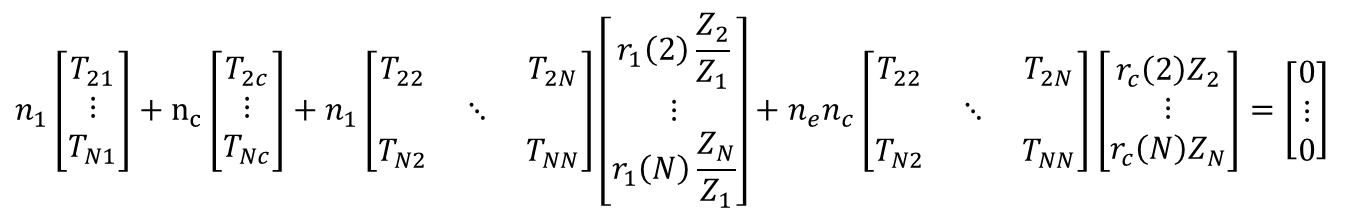
####  
$𝑛_1, 𝑛_𝑐$ が変化したとき、$𝑛_{2-𝑁}$ （すなわち$𝑟_1(𝑖). 𝑟_c(𝑖)$）は
即座に応答。$𝑛_1, 𝑛_𝑐$について２つの独立した等式とみる。
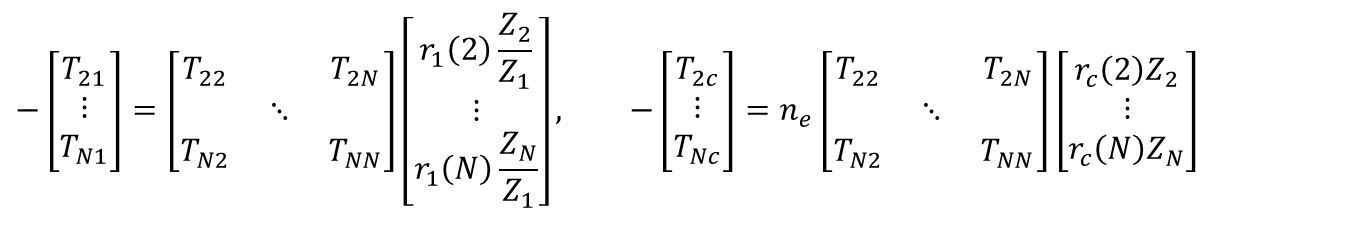
それぞれ𝑛_𝑐=0, 𝑛_1=0 とおいたことと等しい。


In [36]:
import matplotlib.ticker as ticker


r1,rc have shape: (32, 50)


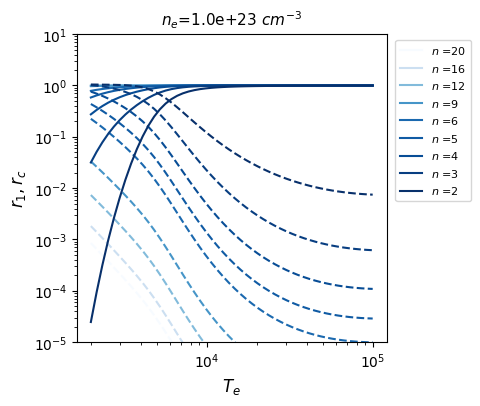

In [94]:
#--------- Boltzmann-Saha coeff. -----------------------
def BoltSahaZ(Te,n):
    Z = n**2 *(Cst.h_**2/2./np.pi/Cst.me_/Cst.k_/Te)**(1.5)*np.exp(Cst.E_Rydberg_/n**2/Cst.k_/Te)
    return(Z)

#--------------------------------------------------------

Jfactor = 0.   # intensity of solar radiation
Ne = 1E23 # <== very high density!
nTe = 50
Tes = np.logspace(3.3, 5, nTe)
n_lev = np.size(atom.Level)-1

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  
r1 = np.zeros([n_lev-1,nTe])
rc = np.zeros([n_lev-1,nTe])
print(f"r1,rc have shape: {r1.shape}")
ns = np.arange(2,n_lev+1,dtype='int')

for j in range(0,nTe):
#for j in range(0,20):
    Te = Tes[j]
    Zs = BoltSahaZ(Te,ns)
    UI = LTELib.Ufunc_('H_I',Te)
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None, rate_only=True)  #  level populations etc.
    Rmat = Rate.Rmat
    Cmat = Rate.Cmat
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rmat, Cmat)
    #print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    #print(f"Amat has shape: {A.shape}")  #b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    b1 = -Pmat[1:-1,0]
    v1 = np.linalg.solve(A, b1) ## solve Ax=b, for levels n=2,3,...,N
    r1[:,j] = v1*BoltSahaZ(Te,1)/Zs
    #print(BoltSahaZ(Te,1)/Zs[0:3])
    bc = -Pmat[1:-1,-1]
    vc = np.linalg.solve(A, bc) ## solve Ax=b, for levels n=2,3,...,N
    rc[:,j] = vc/Ne/Zs
    
fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=100)

cmap = plt.get_cmap('Blues')
nn = [0,1,2,3,4,7,10,14,18]
#nn = [0,1,2,3]
nn.reverse()
#for i in range(0,n_lev-1):
for i in nn:
    ind = (np.max(nn)-i)/np.max(nn)
    ax.plot(Tes,rc[i,:],label=r"$n$ ="+f"{ns[i]:1d}",color=cmap(ind))
    ax.plot(Tes,r1[i,:],'--',color=cmap(ind))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim([1e-5,10])
ax.set_xlabel('$T_e$', fontsize=12)
ax.set_ylabel('$r_1, r_c$', fontsize=12)

title = r"$n_e$="+f"{Ne:3.1e}"+r" $cm^{-3}$"
ax.set_title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,1.),fontsize=8,ncol=1)

# np.set_printoptions(precision=2, suppress=False)
# Pmat

### ionizing and recombining populations
### $ \frac{n_I(i)}{n_1} = 𝑟_1(i) \frac{Z_i}{Z_1}, \quad  \frac{n_R(i)}{n_c} = 𝑟_c(i)Z_i n_e, \quad i=2\sim N $


nI,nR have shape: (32, 50)


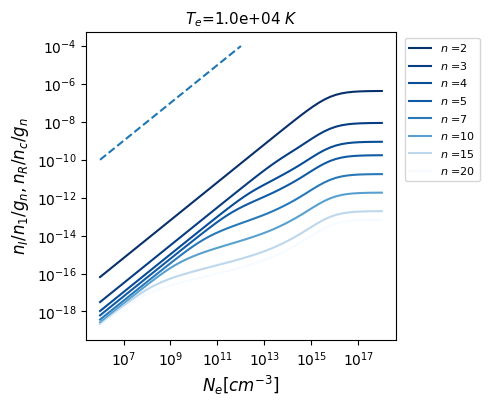

In [95]:
#  n(i) vs. Ne
nNe = 50
Nes = np.logspace(6,18,nNe)
Jfactor = 0.   # intensity of solar radiation
Te = 1.0e4#1.28e5   

n_lev = np.size(atom.Level)-1

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  

nI = np.zeros([n_lev-1,nNe])
nR = np.zeros([n_lev-1,nNe])
print(f"nI,nR have shape: {r1.shape}")
ns = np.arange(2,n_lev+1,dtype='int')
gs = 2*ns**2

Zs = BoltSahaZ(Te,ns)
UI = LTELib.Ufunc_('H_I',Te)
for j in range(0,nNe):
#for j in range(0,1):
    Ne = Nes[j]
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None, rate_only=True)  #  level populations etc.
    Rmat = Rate.Rmat
    Cmat = Rate.Cmat
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rmat, Cmat)
    #print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    #print(f"Amat has shape: {A.shape}")  #b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    b1 = -Pmat[1:-1,0]
    v1 = np.linalg.solve(A, b1) ## solve Ax=b, for levels n=2,3,...,N
    nI[:,j] = v1
    #print(BoltSahaZ(Te,1)/Zs[0:3])
    bc = -Pmat[1:-1,-1]
    vc = np.linalg.solve(A, bc) ## solve Ax=b, for levels n=2,3,...,N
    nR[:,j] = vc*Ne
    
fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=100)

cmap = plt.get_cmap('Blues')
nn = [0,1,2,3,5,8,13,18]
##nn.reverse()
#for i in range(0,n_lev-1):
for i in nn:
    ind = (np.max(nn)-i)/np.max(nn)
    ax.plot(Nes,nI[i,:]/gs[i],label=r"$n$ ="+f"{ns[i]:1d}",color=cmap(ind))
    #ax.plot(Nes,nR[i,:]/gs[i],'--',color=cmap(ind))

ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim([1e-5,10])
ax.set_xlabel(r'$N_e [cm^{-3}]$', fontsize=12)
ax.set_ylabel('$n_I/n_1/g_n, n_R/n_c/g_n$', fontsize=12)

title = r"$T_e$="+f"{Te:3.1e}"+r" $K$"
ax.set_title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,1.),fontsize=8,ncol=1)

ax.plot([1e6,1e12],[1e-10,1e-4],'--')


In [59]:
ns.shape

(19,)

r1,rc have shape: (32, 50)
nI,nR have shape: (32, 50)


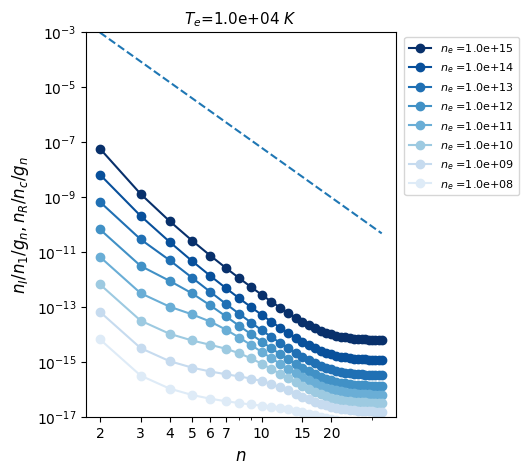

In [98]:
#  n(i) vs. i 
lNe = [8,9,10,11,12,13,14,15]
lNe.reverse()
Nes = 10.**np.array(lNe)
nNe = len(Nes)
Jfactor = 0.   # intensity of solar radiation
Te = 1.0e4#1.28e5   
##  Johnson(1972)'s Cmat is correct up to n~10

Jfactor = 0.0   # intensity of solar radiation
Ne = 1E23 # <== very high density!
nTe = 50
Tes = np.logspace(3.3, 5, nTe)
n_lev = np.size(atom.Level)-1

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  
r1 = np.zeros([n_lev-1,nTe])
rc = np.zeros([n_lev-1,nTe])
print(f"r1,rc have shape: {r1.shape}")
ns = np.arange(2,n_lev+1,dtype='int')

nI = np.zeros([n_lev-1,nNe])
nR = np.zeros([n_lev-1,nNe])
print(f"nI,nR have shape: {r1.shape}")

fig, ax = plt.subplots(1,1, figsize=(4,5), dpi=100)

cmap = plt.get_cmap('Blues')

for j in range(0,nNe):
    Ne = Nes[j]
    ind = (nNe-j)/nNe
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None, rate_only=True)  #  level populations etc.
    Rmat = Rate.Rmat
    Cmat = Rate.Cmat
    #Cmat[0:-1,0:-1] = Cmat1*Ne   # <==  use Fujimoto's C_ij formula
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rmat, Cmat)
    #print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    #print(f"Amat has shape: {A.shape}")  #b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    b1 = -Pmat[1:-1,0]
    v1 = np.linalg.solve(A, b1) ## solve Ax=b, for levels n=2,3,...,N
    nI[:,j] = v1
    ax.plot(ns,nI[:,j]/gs,'-o', label=r"$n_e$ ="+f"{Ne:3.1e}",color=cmap(ind))
    #print(BoltSahaZ(Te,1)/Zs[0:3])
    bc = -Pmat[1:-1,-1]
    vc = np.linalg.solve(A, bc) ## solve Ax=b, for levels n=2,3,...,N
    nR[:,j] = vc*Ne

ax.plot(ns,0.06*1./ns**6,'--')
xticks = [2,3,4,5,6,7,10,15,20]
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda xticks,_: f'{xticks:.0f}'))
#ax.set_xticklabels(str(xticks), fontsize=10)
ax.set_xlabel('$n$', fontsize=12)
ax.set_yscale("log")
ax.set_ylabel('$n_I/n_1/g_n, n_R/n_c/g_n$', fontsize=12)
ax.set_ylim(1e-17, 1e-3)

title = r"$T_e$="+f"{Te:3.1e}"+r" $K$"
ax.set_title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,1.),fontsize=8,ncol=1)


r1,rc have shape: (19, 50)
nI,nR have shape: (19, 50)


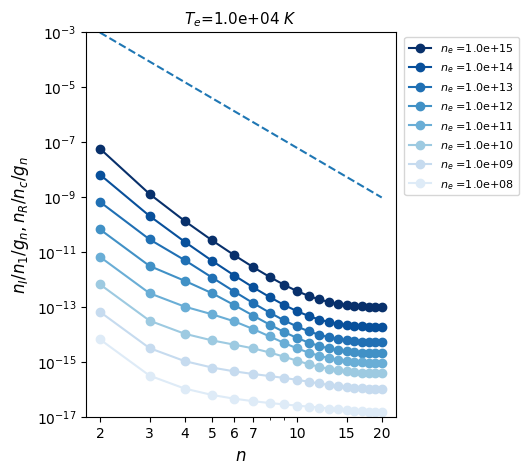

In [74]:
#  n(i) vs. i 
lNe = [8,9,10,11,12,13,14,15]
lNe.reverse()
Nes = 10.**np.array(lNe)
nNe = len(Nes)
Jfactor = 0.   # intensity of solar radiation
Te = 1.0e4#1.28e5   
##  Johnson(1972)'s Cmat is correct up to n~10

Jfactor = 0.0   # intensity of solar radiation
Ne = 1E23 # <== very high density!
nTe = 50
Tes = np.logspace(3.3, 5, nTe)
n_lev = np.size(atom.Level)-1

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor  
r1 = np.zeros([n_lev-1,nTe])
rc = np.zeros([n_lev-1,nTe])
print(f"r1,rc have shape: {r1.shape}")
ns = np.arange(2,n_lev+1,dtype='int')

nI = np.zeros([n_lev-1,nNe])
nR = np.zeros([n_lev-1,nNe])
print(f"nI,nR have shape: {r1.shape}")

fig, ax = plt.subplots(1,1, figsize=(4,5), dpi=100)

cmap = plt.get_cmap('Blues')

for j in range(0,nNe):
    Ne = Nes[j]
    ind = (nNe-j)/nNe
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None, rate_only=True)  #  level populations etc.
    Rmat = Rate.Rmat
    Cmat = Rate.Cmat
    #Cmat[0:-1,0:-1] = Cmat1*Ne   # <==  use Fujimoto's C_ij formula
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rmat, Cmat)
    #print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    #print(f"Amat has shape: {A.shape}")  #b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    b1 = -Pmat[1:-1,0]
    v1 = np.linalg.solve(A, b1) ## solve Ax=b, for levels n=2,3,...,N
    nI[:,j] = v1
    ax.plot(ns,nI[:,j]/gs,'-o', label=r"$n_e$ ="+f"{Ne:3.1e}",color=cmap(ind))
    #print(BoltSahaZ(Te,1)/Zs[0:3])
    bc = -Pmat[1:-1,-1]
    vc = np.linalg.solve(A, bc) ## solve Ax=b, for levels n=2,3,...,N
    nR[:,j] = vc*Ne

ax.plot(ns,0.06*1./ns**6,'--')
xticks = [2,3,4,5,6,7,10,15,20]
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda xticks,_: f'{xticks:.0f}'))
#ax.set_xticklabels(str(xticks), fontsize=10)
ax.set_xlabel('$n$', fontsize=12)
ax.set_yscale("log")
ax.set_ylabel('$n_I/n_1/g_n, n_R/n_c/g_n$', fontsize=12)
ax.set_ylim(1e-17, 1e-3)

title = r"$T_e$="+f"{Te:3.1e}"+r" $K$"
ax.set_title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,1.),fontsize=8,ncol=1)


In [32]:
#  n(i) vs. i 
lNe = [8,9,10,11,12,13,14,15]
lNe.reverse()
Nes = 10.**np.array(lNe)
nNe = len(Nes)
Jfactor = 0.   # intensity of solar radiation
Te = 1.28e5   
##  Johnson(1972)'s Cmat is correct up to n~10

nI = np.zeros([n_lev-1,nNe])
nR = np.zeros([n_lev-1,nNe])
print(f"nI,nR have shape: {r1.shape}")

fig, ax = plt.subplots(1,1, figsize=(4,5), dpi=100)

cmap = plt.get_cmap('Blues')

for j in range(0,nNe):
    Ne = Nes[j]
    ind = (nNe-j)/nNe
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
    SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None, rate_only=True)  #  level populations etc.
    Rmat = Rate.Rmat
    Cmat = Rate.Cmat
    #Cmat[0:-1,0:-1] = Cmat1*Ne   # <==  use Fujimoto's C_ij formula
    Pmat = SELib.Rmat_Cmat_to_Pmat_(Rmat, Cmat)
    #print(f"Pmat has shape: {Pmat.shape}")
    A = Pmat[1:-1,1:-1] ## exclude n=1 level and continuum
    #print(f"Amat has shape: {A.shape}")  #b = (-n1*Pmat[1:-1,0]-n_proton*Pmat[1:-1,-1])
    b1 = -Pmat[1:-1,0]
    v1 = np.linalg.solve(A, b1) ## solve Ax=b, for levels n=2,3,...,N
    nI[:,j] = v1
    ax.plot(ns,nI[:,j]/gs,'-o', label=r"$n_e$ ="+f"{Ne:3.1e}",color=cmap(ind))
    #print(BoltSahaZ(Te,1)/Zs[0:3])
    bc = -Pmat[1:-1,-1]
    vc = np.linalg.solve(A, bc) ## solve Ax=b, for levels n=2,3,...,N
    nR[:,j] = vc*Ne

ax.plot(ns,0.06*1./ns**6,'--')
xticks = [2,3,4,5,6,7,10,15,20]
ax.set_xscale("log")
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda xticks,_: f'{xticks:.0f}'))
#ax.set_xticklabels(str(xticks), fontsize=10)
ax.set_xlabel('$n$', fontsize=12)
ax.set_yscale("log")
ax.set_ylabel('$n_I/n_1/g_n, n_R/n_c/g_n$', fontsize=12)

title = r"$T_e$="+f"{Te:3.1e}"+r" $K$"
ax.set_title(title,fontsize=11)

ax.legend(bbox_to_anchor=(1.01,1.),fontsize=8,ncol=1)


NameError: name 'r1' is not defined

In [ ]:
Ne = 1e12
slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None, rate_only=True)  #  level populations etc.
Rmat = Rate.Rmat
Cmat = Rate.Cmat
Pmat = SELib.Rmat_Cmat_to_Pmat_(Rmat, Cmat)

fig, axs = plt.subplots(1,2,figsize=[8,4])

ax=axs[0]
ax.plot(ns,Cmat[1:-1,0],'*',label='col.ex. from n=1')
ax.plot(ns,Cmat[0,1:-1],'.',label='col.de-ex. to n=1')
ax.plot(ns,Rmat[0,1:-1],'+',label=('rad.de-ex. to n=1'))
#ax.plot(ns,Pmat[1:-1,0],'--',label='ex. from n=1')
#ax.plot(ns,Pmat[0,1:-1],'--',label='de-ex. to n=1')
#ax.plot(A[:,0],'.')
ax.set_xscale('log')
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda xticks,_: f'{xticks:.0f}'))
ax.set_xlabel('$n$', fontsize=12)
ax.set_yscale('log')
title = r"$N_e$="+f"{Ne:3.1e}"+r" $cm^{-3}$"
ax.set_title(title,fontsize=11)

ax.legend(bbox_to_anchor=(0.5,1.),fontsize=9,ncol=1)

heatmap(axs[1], Cmat, colbar='Rate [s$^{-1}$]',title='Cmat', last='c') #,vmin=1e1, vmax=1e9)



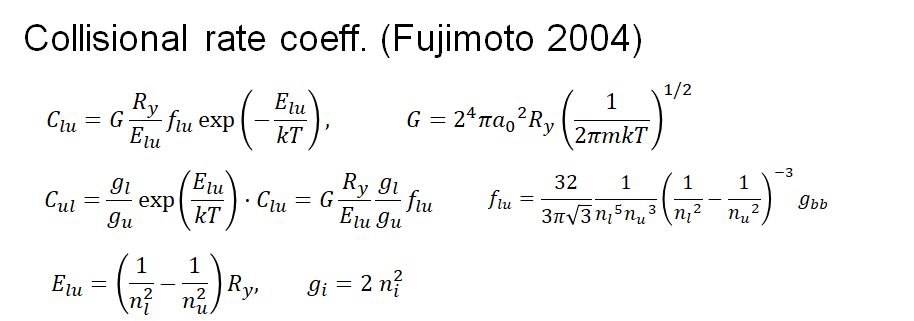


In [14]:
#  Gaunt factor,  Menzel and Pakerie 1935
#  2020.5.26  k.i. (hydrogen.jpynb)
from mpmath import *

def Dnn1(nl,nu):
    F1 = hyp2f1(-nu+1, -nl, 1, -4*nl*nu/(nu-nl)**2)
    F2 = hyp2f1(-nl+1, -nu, 1, -4*nl*nu/(nu-nl)**2)
    FF = F1**2 - F2**2
    return FF

def Dnn(nl,nu):
    nnu = np.size(np.array(nu))
    if nnu > 1:
        DD = np.repeat(0j,nnu)
        for i in range(0,nnu):
            DD[i] = Dnn1(nl,nu[i])
        return DD
    return Dnn1(nl,nu)

def gbb(nl,nu):  
    #  nl,nu -  principle # of lower & upper levels
    nume = np.pi*np.sqrt(3) * ((nu-nl)/(nu+nl))**(2*(nu+nl)) * nu*nl *Dnn(nl,nu)
    deno = nu - nl
    return (nume/deno).real

def gbf(nl,k):
    nume = np.pi*np.sqrt(3) * nl * k * np.exp(-4* k * np.arctan(nl/k)) * np.abs(Dnn(nl,1j*k))
    deno = np.sqrt(k**2 + nl**2) * (1 - np.exp(-2*np.pi*k))
    return (nume/deno).real
                                    
def flu(nl,nu):  # oscillator strength
    f = 32./(3*np.pi*np.sqrt(3))/nl**5/nu**3 * (1/nl**2 - 1/nu**2)**(-3) *gbb(nl,nu)
    return (f).real

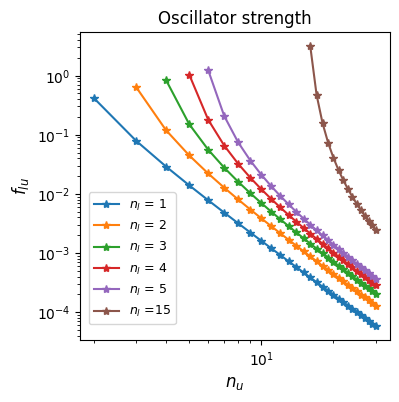

In [15]:
# oscillator strength
nmax = 30
nls = [1,2,3,4,5,15]
    
fig, ax = plt.subplots(1,1,figsize=(4,4),dpi=100)

for nl in nls:
    nus = np.linspace(nl+1,nmax,nmax-nl)
    fs = flu(nl,nus)
    ax.plot(nus,fs,'-*',label=r"$n_l$ ="+f"{nl:2.0f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel('$n_u$',fontsize=12)
ax.set_ylabel('$f_{lu}$',fontsize=12)
ax.legend(bbox_to_anchor=(0.33,0.5),fontsize=9,ncol=1)
ax.set_title('Oscillator strength')

plt.show()


In [28]:
Cmat1

array([[0.00000000e+00, 5.72342390e-08, 4.07918678e-09, 7.97353476e-10,
        2.39595386e-10, 9.19341424e-11, 4.13750877e-11, 2.08464882e-11,
        1.14282467e-11, 6.68987094e-12, 4.12730924e-12, 2.65832000e-12,
        1.77480666e-12, 1.22158294e-12, 8.63087887e-13, 6.23808149e-13,
        4.59932005e-13, 3.45126793e-13, 2.63068039e-13, 2.03355057e-13],
       [1.03028280e-14, 0.00000000e+00, 8.45892368e-07, 6.56348749e-08,
        1.40409994e-08, 4.55721648e-09, 1.86357900e-09, 8.84022497e-10,
        4.65396731e-10, 2.64762682e-10, 1.59963157e-10, 1.01414747e-10,
        6.68863363e-11, 4.55949574e-11, 3.19652891e-11, 2.29574864e-11,
        1.68380942e-11, 1.25798690e-11, 9.55341533e-12, 7.36165671e-12],
       [7.20353439e-17, 8.29825191e-08, 0.00000000e+00, 4.02001140e-06,
        3.14501427e-07, 6.91109890e-08, 2.31284386e-08, 9.74298916e-09,
        4.74985996e-09, 2.56306409e-09, 1.49074871e-09, 9.18707461e-10,
        5.92902022e-10, 3.97346784e-10, 2.74805064e-10, 1.9519

<function matplotlib.pyplot.show(close=None, block=None)>

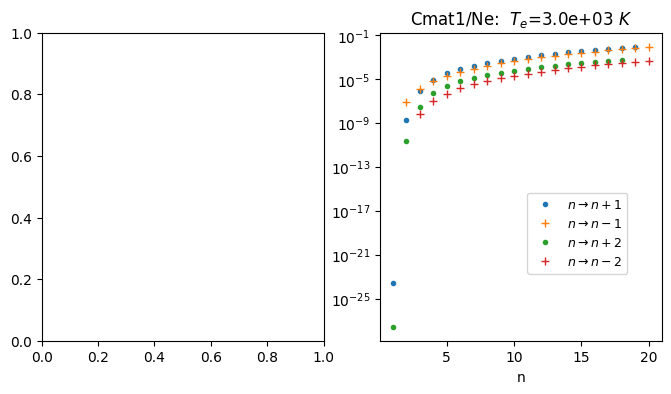

In [31]:
# Collisional excitation rate (Fujimoto 2004)
nmax = 20
Te = 0.3e4#1.28e5
G = 2**4 *np.pi*Cst.a0_**2 *Cst.E_Rydberg_ *np.sqrt(1./2/np.pi/Cst.me_/Cst.k_/Te)
Cmat1 = np.zeros([nmax,nmax])
nn = np.linspace(1,nmax,nmax,dtype=int)

for nl in nn[0:-1]:
    nus = np.linspace(nl+1,nmax,nmax-nl,dtype=int)
    gl = 2*nl**2
    for nu in nus:
        f1 = flu(nl,nu)
        Elu = Cst.E_Rydberg_*(1/nl**2 - 1/nu**2)
        gu = 2*nu**2
        Cmat1[nu-1,nl-1] = G*Cst.E_Rydberg_/Elu *np.exp(-Elu/Cst.k_/Te)*f1
        Cmat1[nl-1,nu-1] = G*Cst.E_Rydberg_/Elu *gl/gu*f1
        #print(nl,nu,-Elu/Cst.k_/Te)

fig, axs = plt.subplots(1,2,figsize=(8,4),dpi=100)
title = 'Cmat1/Ne:  '+r"$T_e$="+f"{Te:3.1e}"+r" $K$"
#heatmap(axs[0], Cmat1,title=title)#, colbar='Rate [s$^{-1}$]') #,vmin=1e1, vmax=1e9)

ax = axs[1]
nn2 = nn[0:-1] ; ax.plot(nn2,Cmat1[nn2,nn2-1],'.',label=r'$n \rightarrow n+1$')
nn2 = nn[1:]   ; ax.plot(nn2,Cmat1[nn2-1-1,nn2-1],'+',label=r'$n \rightarrow n-1$')
nn2 = nn[0:-2] ; ax.plot(nn2,Cmat1[nn2-1+2,nn2-1],'.',label=r'$n \rightarrow n+2$')
nn2 = nn[2:]   ; ax.plot(nn2,Cmat1[nn2-1-2,nn2-1],'+',label=r'$n \rightarrow n-2$')
ax.set_yscale('log')
ax.set_xlabel('n')
ax.set_title(title)

ax.legend(bbox_to_anchor=(0.9,0.5),fontsize=9,ncol=1)


plt.show


In [13]:
# Collisional excitation rate (Fujimoto 2004)
nmax = 20
Te = 1.28e5
G = 2**4 *np.pi*Cst.a0_**2 *Cst.E_Rydberg_ *np.sqrt(1./2/np.pi/Cst.me_/Cst.k_/Te)
Cmat1 = np.zeros([nmax,nmax])
nn = np.linspace(1,nmax,nmax,dtype=int)

for nl in nn[0:-1]:
    nus = np.linspace(nl+1,nmax,nmax-nl,dtype=int)
    gl = 2*nl**2
    for nu in nus:
        f1 = flu(nl,nu)
        Elu = Cst.E_Rydberg_*(1/nl**2 - 1/nu**2)
        gu = 2*nu**2
        Cmat1[nu-1,nl-1] = G*Cst.E_Rydberg_/Elu *np.exp(-Elu/Cst.k_/Te)*f1
        Cmat1[nl-1,nu-1] = G*Cst.E_Rydberg_/Elu *gl/gu*f1
        #print(nl,nu,-Elu/Cst.k_/Te)

fig, axs = plt.subplots(1,2,figsize=(8,4),dpi=100)
title = 'Cmat1/Ne:  '+r"$T_e$="+f"{Te:3.1e}"+r" $K$"
heatmap(axs[0], Cmat1,title=title)#, colbar='Rate [s$^{-1}$]') #,vmin=1e1, vmax=1e9)

ax = axs[1]
nn2 = nn[0:-1] ; ax.plot(nn2,Cmat1[nn2,nn2-1],'.',label=r'$n \rightarrow n+1$')
nn2 = nn[1:]   ; ax.plot(nn2,Cmat1[nn2-1-1,nn2-1],'+',label=r'$n \rightarrow n-1$')
nn2 = nn[0:-2] ; ax.plot(nn2,Cmat1[nn2-1+2,nn2-1],'.',label=r'$n \rightarrow n+2$')
nn2 = nn[2:]   ; ax.plot(nn2,Cmat1[nn2-1-2,nn2-1],'+',label=r'$n \rightarrow n-2$')
ax.set_yscale('log')
ax.set_xlabel('n')
ax.set_title(title)

ax.legend(bbox_to_anchor=(0.9,0.5),fontsize=9,ncol=1)


plt.show


NameError: name 'flu' is not defined

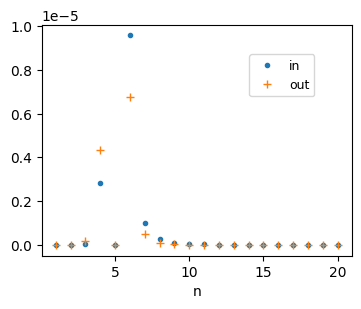

In [25]:
n = 5

fig, ax = plt.subplots(1,1,figsize=[4,3])

ax.plot(nn,Cmat1[:,n-1],'.',label='in')
ax.plot(nn,Cmat1[n-1,:],'+',label='out')
#ax.plot([n,n],[0,4e-5],'--')
#ax.set_yscale('log')
ax.set_xlabel('n')
ax.legend(bbox_to_anchor=(0.9,0.9),fontsize=9,ncol=1)

plt.show()

In [152]:
nn

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

#

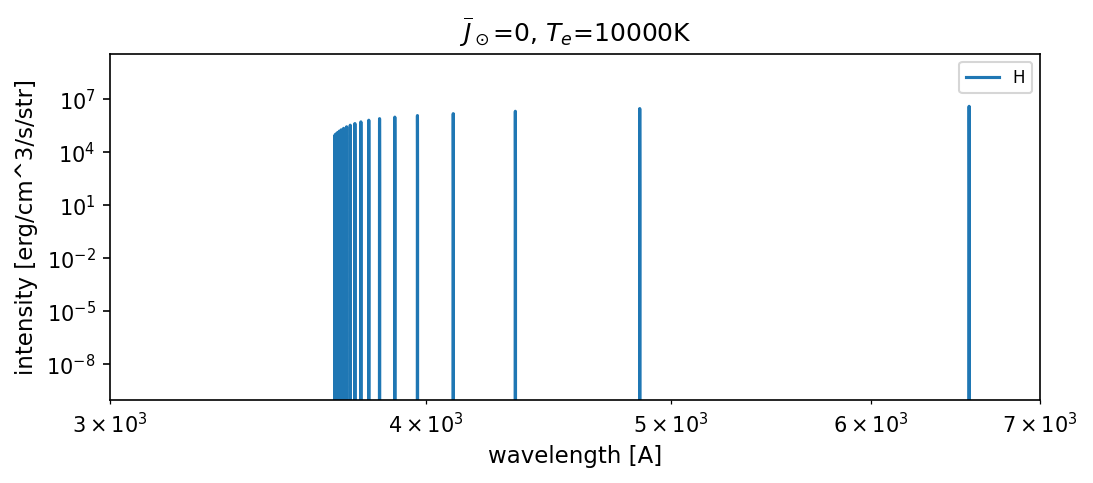

In [24]:
l = CloudModel.SE_to_slab_0D_(atom, slab, SE2, depth=depth)      # hydrogen lines intensity

fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)
ax.plot(l.wl_1D*1e8,l.prof_1D,label='H')
ax.set_xscale("log")
#ax.set_xlim(0, 20000)
ax.set_xlim(3000, 7000)
ax.set_yscale("log")
#ax.set_ylim(1E7,1E12)
ax.set_xlabel("wavelength [A]", fontsize=11)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=11)
plt.title(title,fontsize=12)
ax.legend(fontsize=8,ncol=1)
plt.show()

## Line intensity

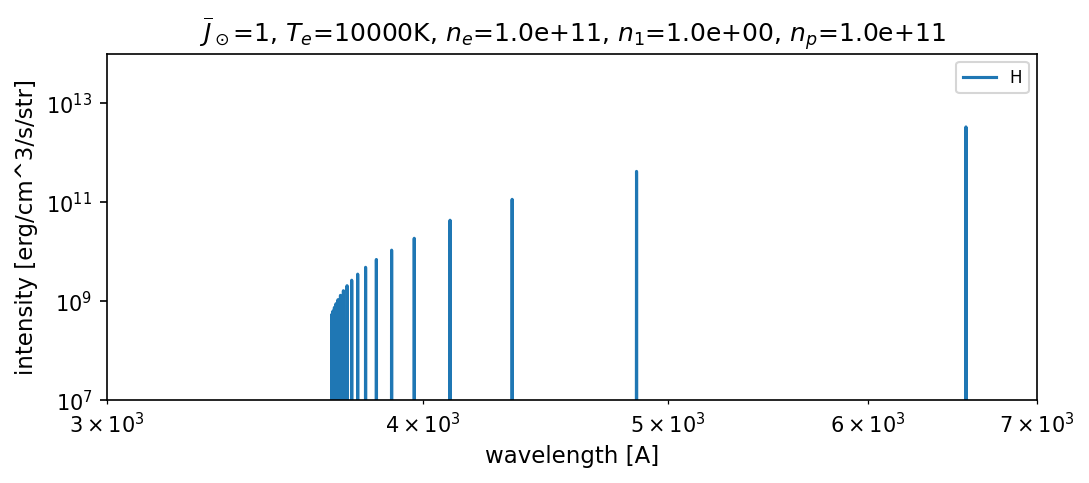

In [93]:
#----- line intensity -----
Te = 10000.
Ne = 1e11
Jfactor = 1.   # intensity of solar radiation

ssp = copy.deepcopy(solar_spec)    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
ssp.backRad[1,:] *= Jfactor     
ssp.PI_intensity[:,:] *= Jfactor 
slab = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, ssp, None)  #  level populations etc.
l = CloudModel.SE_to_slab_0D_(atom, slab, SE, depth=depth)      # hydrogen lines intensity

fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)
ax.plot(l.wl_1D*1e8,l.prof_1D,label='H')
ax.set_xscale("log")
#ax.set_xlim(0, 20000)
ax.set_xlim(3000, 7000)
ax.set_yscale("log")
ax.set_ylim(1E7,1E14)
ax.set_xlabel("wavelength [A]", fontsize=11)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=11)
plt.title(title,fontsize=12)
ax.legend(fontsize=8,ncol=1)
plt.show()

In [349]:
a = np.array([[1,2],[3,4]])
b = np.array([2,3]).reshape(-1,1)
print(a)
print(b)
print(a*b)

[[1 2]
 [3 4]]
[[2]
 [3]]
[[ 2  4]
 [ 9 12]]


In [ ]:
flux  cm^-3 s^-1
rate s^-1  -> relaxsation time


In [47]:
#np.set_printoptions(precision=3,floatmode="fixed",suppress="False") 
np.set_printoptions(precision=10,suppress="False") 
#np.log(Rate.Cmat *SE.n_SE.reshape(1,-1))
Rate.Cmat *SE.n_SE.reshape(1,-1)

array([[0.0000000000, 0.0000229197, 0.0000000187, 0.0000000015,
        0.0000000004, 0.0000000001, 0.0000000001, 0.0000000000,
        0.0000000004],
       [0.0016765116, 0.0000000000, 0.0000066270, 0.0000002959,
        0.0000000611, 0.0000000202, 0.0000000087, 0.0000000049,
        0.0000000371],
       [0.0000359081, 0.0001740715, 0.0000000000, 0.0000131762,
        0.0000014675, 0.0000003786, 0.0000001442, 0.0000000749,
        0.0000003428],
       [0.0000061110, 0.0000164469, 0.0000278792, 0.0000000000,
        0.0000392938, 0.0000051024, 0.0000014803, 0.0000006663,
        0.0000015580],
       [0.0000020592, 0.0000044093, 0.0000040293, 0.0000509896,
        0.0000000000, 0.0001047670, 0.0000143802, 0.0000048303,
        0.0000048367],
       [0.0000009499, 0.0000018137, 0.0000012948, 0.0000082469,
        0.0001304918, 0.0000000000, 0.0002511220, 0.0000380699,
        0.0000118825],
       [0.0000005218, 0.0000009325, 0.0000005858, 0.0000028420,
        0.0000212763, 0.000298

In [33]:
np.set_printoptions(precision=1,floatmode="fixed",suppress="False") 
SE.n_SE.reshape(1,-1)
np.log(Rate.Cmat)

C:\Users\ichim\AppData\Local\Temp\ipykernel_12680\2233984242.py:3: RuntimeWarning: divide by zero encountered in log
  np.log(Rate.Cmat)


array([[ -inf,   5.1,   2.7,   1.1,  -0.1,  -1.0,  -1.8,  -2.5, -21.3],
       [ -5.3,  -inf,   8.5,   6.4,   5.0,   3.9,   3.0,   2.3, -16.7],
       [ -9.2,   7.1,  -inf,  10.2,   8.1,   6.8,   5.8,   5.0, -14.5],
       [-10.9,   4.8,  10.0,  -inf,  11.4,   9.4,   8.2,   7.2, -12.9],
       [-12.0,   3.5,   8.0,  11.5,  -inf,  12.4,  10.4,   9.2, -11.8],
       [-12.8,   2.6,   6.9,   9.7,  12.6,  -inf,  13.3,  11.3, -10.9],
       [-13.4,   1.9,   6.1,   8.6,  10.8,  13.5,  -inf,  14.0, -10.2],
       [-13.9,   1.4,   5.5,   7.9,   9.8,  11.7,  14.2,  -inf,  -9.5],
       [-11.6,   3.5,   7.1,   8.8,   9.9,  10.6,  11.1,  11.6,  -inf]])

## Calc. SE and line profiles for a [$T_e,n_H$]

In [15]:
# import CloudModel from spectra_src.Function.SlabModel

Te = 10000.
Nh = 1*1e11
Ne = 0.
Vd = 0.
Vt = 5e5            #   cm/s
depth = 1E1* 1.E5 #   km *1e5

slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
SE, Rate = SELib.cal_SE_with_Nh_Te_(atom, slab, wMesh, solar_spec, None)  #  level populations etc.
l = CloudModel.SE_to_slab_0D_(atom, slab, SE, depth=depth)      # hydrogen lines intensity


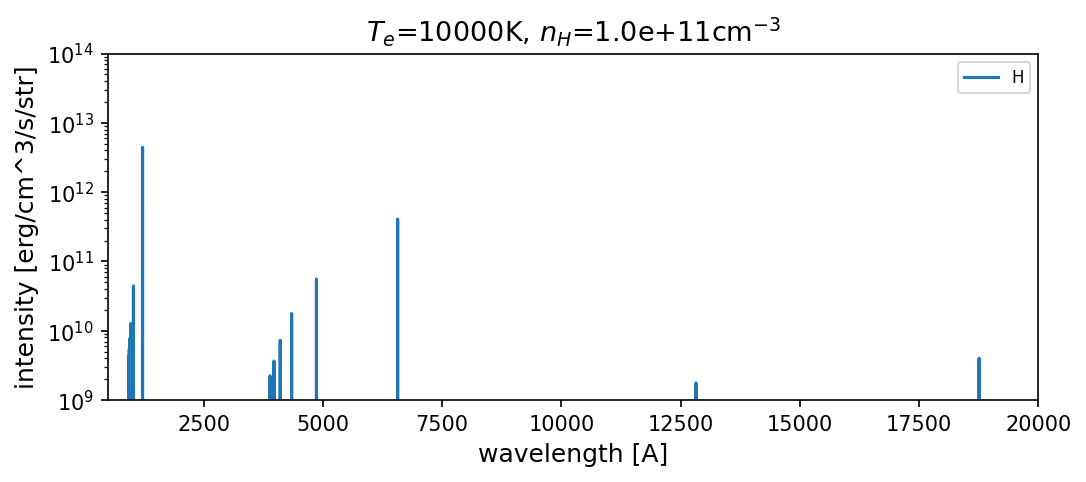

In [18]:
fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)
ax.plot(l.wl_1D*1e8,l.prof_1D,label='H')
ax.set_ylim(1e9,1E14)
#ax.set_xlim(300, 12000)
#ax.set_xscale("log")
ax.set_xlim(500, 20000)
ax.set_yscale("log")
#ax.set_ylim(1e10, 5e13)
ax.set_xlabel("wavelength [A]", fontsize=12)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=12)
#plt.title("$T_e$={0:5.0f}K, $n_H$={1:5.1e}cm$^{{-3}}$, $n_e$={2:5.1e}cm$^{{-3}}$".format(Te, Nh, Ne),fontsize=13)
plt.title("$T_e$={0:5.0f}K, $n_H$={1:5.1e}cm$^{{-3}}$".format(Te, Nh),fontsize=13)
ax.legend(fontsize=8,ncol=1)
plt.show()